# FIRST - UNZIP THE DATA FILE TO RUN THIS!

# DID NOT FIND ANYTHING REALLY USEFUL OR INTERESTING
## DATA SEEMS NOT SUITABLE FOR THAT... (sequence is super super simple, done unequal number of times, first interval has limitations because cannot press until a certain point, 2nd nterval between bottom and top may have less information etc...)
FYI, Also tried remove bad consumption...


Can maybe focus on participant with reduction but still slips maybe... I Dunno...


In [1]:
#@title Load Drive
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

In [36]:
#@title Import stuff and general settings

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as patches
from matplotlib.patches import Patch
import seaborn as sns
from datetime import datetime, timedelta
import ast

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib import ticker
import plotly.graph_objects as go

import os
import math


from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import learning_curve

from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score, auc, brier_score_loss, pairwise_distances, silhouette_samples, precision_score, recall_score, silhouette_score

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier # Multi layer perceptron
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import permutation_importance, PartialDependenceDisplay, partial_dependence
from sklearn.utils import shuffle
from sklearn.calibration import calibration_curve
from sklearn.tree import plot_tree
from sklearn.cross_decomposition import PLSRegression

import shap
from scipy.stats import binomtest, binom_test, ttest_ind, mannwhitneyu
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.stats import chi2_contingency
from scipy.cluster.hierarchy import fcluster
from scipy.cluster.hierarchy import dendrogram

from joblib import Parallel, delayed
import pickle




In [37]:
#@title Parameter definition { form-width: "5%" }

minSubID = [100, 200, 300]
maxSubID = [199, 299, 399]

# paths:
# main_path = os.path.dirname(os.path.abspath(__file__))
main_path = '.'
filteredDF_File = main_path + '/data/extracted_data/filteredDF.csv'
coreData_File = main_path + '/data/extracted_data/core_table.csv'
data_for_R_path = main_path + '/data/extracted_data/all_data_for_R.csv'


# number of experimental days by group:
n_experimental_days = {'short_training': 4, 'long_training': 11, 'long_training_parallel_manipulations': 11}
# number of experimental manipulations per subject:
n_manipulations = {'short_training': 3, 'long_training': 3, 'long_training_parallel_manipulations': 6}

main_manipulation_days = {
    'short_training': {'still_valued': 2, 'devaluation': 3, 'still_valued_post_deval': 4},
    'long_training': {'still_valued': 9, 'devaluation': 10, 'still_valued_post_deval': 11},
    'long_training_parallel_manipulations': {'still_valued': 9, 'devaluation': 10, 'still_valued_post_deval': 11},  
}

all_manipulation_days = {
    'short_training': {'still_valued': 2, 'devaluation': 3, 'still_valued_post_deval': 4},
    'long_training': {'still_valued': 9, 'devaluation': 10, 'still_valued_post_deval': 11},
    'long_training_parallel_manipulations': {'still_valued_week1': 2, 'still_valued_replacing_devaluation': 3, 'still_valued_post_deval_week1': 4, 'still_valued': 9, 'devaluation': 10, 'still_valued_post_deval': 11},  
}


dailyOffsetHours = 5 # the time past midnight that is included in the same day (5 means until 5:00 AM is considered the last day)
localTimeZone = "Israel" # used to adjust the time variables which are recorded in utc time.
timeInStringColumns = ['startTime', 'press1Time', 'press2Time', 'outcomeTime', 'endTime', 'userExitOrUnloadTime',
                       'realGameBeginsAlertTime', 'realGameBeginsConfirmationTime', 'resetContainerAlertTime', 'resetContainerConfirmationTime', 'manipulationAlertTime', 'manipulationConfirmationTime', 'foundCaveAlertTime', 'foundCaveConfirmationTime', 'endExperimentAlertTime'] # these variables will be converted to the local time zone and saved as datetime variables


# Figures:
sns.set_theme(context='notebook', style='white')  # options. style: darkgrid, whitegrid, dark, white, ticks | context: paper, notebook, talk, poster

# viewing stuff
# pd.set_option('max_rows', None)
pd.set_option('max_colwidth', None)
pd.set_option('display.max_columns', 40)  # set this number to >= your number of cols
pd.set_option('display.width', 1000)
#pd.describe_option('max_colwidth')
plt.rcParams['figure.figsize'] = [9, 6]
plt.rcParams['figure.dpi'] = 100 # 200 e.g. is really fine, but slower
plt.rcParams['timezone'] = localTimeZone


In [38]:
#@title Class definition { form-width: "5%" }
# Define a class to be compatible with the classes' structue in on Habit_app_parse_data.ipynb:
class DataDummy():
    def __init__(self):
        # GET DATA:
        self.sub_df = []


# ------------------------------ * -------------------------------


# LOAD DATA (from the drive)
(and assemble required data [when it is loaded and not extracted])

In [39]:
data=DataDummy()
data.sub_df = pd.read_csv(filteredDF_File,index_col=0,parse_dates=timeInStringColumns)

core_data = pd.read_csv(coreData_File)
core_data = core_data[core_data.time == 'post']
core_data = core_data.drop(columns='time')
core_data = core_data.set_index(['subID', 'group', 'manipulation'])

data_for_R = pd.read_csv(data_for_R_path)

In [40]:
#@title adjustments for working with the data {form-width: "1%"}

core_data_with_diffs = core_data.unstack('manipulation')
core_data_with_diffs.columns = core_data_with_diffs.columns.droplevel()


In [41]:
# Check unique subId values in data.sub_df
unique_sub_ids = data.sub_df['subId'].unique()
print(unique_sub_ids)
print(f'Shape of unique_sub_ids: {unique_sub_ids.shape}')

[101 102 103 105 106 107 108 111 114 115 116 117 118 119 123 124 125 127
 128 130 131 133 134 135 136 137 138 142 143 146 147 149 153 154 155 156
 157 158 159 160 161 162 163 164 165 203 204 206 207 210 211 212 213 216
 218 223 225 226 227 228 229 230 232 233 234 235 236 237 239 240 241 242
 244 245 246 248 250 251 252 253 256 257 258 259 260 261 262 263 264 265
 304 305 306 308 309 312 315 316 318 319 321 325 326 327 332 335 336 338
 341 343 346 349 356 358 359 360 361 363 364 365 366 367 368 371 372 373
 374 375 377 378 380 381 382]
Shape of unique_sub_ids: (133,)


# ------------------------------ * -------------------------------


In [42]:
import re
import pandas as pd

# Function to add microseconds if missing
def add_microseconds_if_missing(time_str):
    # first check if time_str is NaN
    if pd.isna(time_str):
        return time_str
    # Regex to check if microseconds are missing
    if re.match(r'.*\.\d{6}.*', time_str):  # already has microseconds
        return time_str
    elif re.match(r'.*\+\d{2}:\d{2}$', time_str):  # no microseconds, only timezone
        return time_str.replace("+", ".000000+")
    else:
        return time_str  # in case there are already microseconds or something unexpected



In [43]:
# ---------------------------------------------
# NOTE NOTE NOTE: Features to add/consider
# ---------------------------------------------

sub_df_extended.head()
# change settings to show all columns when printing:
pd.set_option('display.max_columns', None)

# now show data with all columns but touchData:
sub_df_extended.drop(columns=['touchData']).head()
# Features of interest:
# DONE:
# startTimes, intervals (within/between), day timings, n entries, session data, ratio 1st/2nd, automaticity measures 

# MAYBE LATER:
# ---------------------------------------------
# model bursting ?
# including other ratios?
# maybe also change in ratio
# maybe generally change form start to end entries of the first day...
# Add medians where is relevant
# Can take correlaiton (e.g. between 1st and 2nd press as a measure(...)
# maybe coin task hits/misses (and other data) during demo...
# and all instructions data...
# MF-BF data
# Maybe control for cunsumption test
# Maybe Also:
# ---------------------------------------------
# add touch data (e.g. angle between presses, distance maybe?, etc., maybe change in angle). here is a sample:
sub_df_extended.touchData[0]
touchData_dict = ast.literal_eval(sub_df_extended.touchData[0])
touchData_dict['pressEvents']
# screenOrientationData	


sub_df_extended.drop(columns=['touchData']).head()


,subId,group,day,cost,reward,hideOutcome,manipulationToday,activateManipulation,isUnderManipulation,consumptionTest,coins_task_hits_count,coins_task_misses_count,coin_task_finish_status,startTime,press1Time,press2Time,outcomeTime,endTime,userExitOrUnloadTime,realGameBeginsAlertTime,realGameBeginsConfirmationTime,resetContainerAlertTime,resetContainerConfirmationTime,manipulationAlertTime,manipulationConfirmationTime,foundCaveAlertTime,foundCaveConfirmationTime,endExperimentAlertTime,dataLoadingTime,screenOrientationData,isDemo,endExperiment,uniqueEntryID,deltaStartTime,deltaSecStartTime,sessionsBeginning,secsToPress1,secsToPress1_global,secsToPress2,secsToExitAfterOutcomeTime,sequenceCompletionTime,sequenceCompletionTime_global,secsToExitAfterOutcomeTimefromEntry,pressed_all_seq,pressed_only_1st_seq,pressed_only_entry,gameBeginsConfirmationRT
0,101,short_training,1.0,[1],0.0,NaN,NaN,False,False,False,NaN,NaN,NaN,2022-02-06 10:05:00.491000+02:00,2022-02-06 10:05:04.687000+02:00,2022-02-06 10:05:05.113000+02:00,2022-02-06 10:05:07.918000+02:00,2022-02-06 10:05:08.921000+02:00,2022-02-06 10:05:12.570000+02:00,2022-02-06 10:05:00.531000+02:00,2022-02-06 10:05:03.198000+02:00,NaT,NaN,NaT,NaN,NaN,NaT,NaT,40.0,"{'screenInitialOrientation': 'portrait', 'screenOrientationEvents': []}",False,NaN,9.0,NaT,NaN,True,3.356,4.196,0.426,4.652,3.782,4.622,11.239,1,0,0,2.667
1,101,short_training,1.0,[1],15.0,False,NaN,False,False,False,NaN,NaN,NaN,2022-02-06 10:05:13.604000+02:00,2022-02-06 10:05:16.076000+02:00,2022-02-06 10:05:16.426000+02:00,2022-02-06 10:05:19.229000+02:00,2022-02-06 10:05:20.234000+02:00,2022-02-06 10:05:25.243000+02:00,NaT,NaT,NaT,NaN,NaT,NaN,NaN,NaT,NaT,36.0,"{'screenInitialOrientation': 'portrait', 'screenOrientationEvents': []}",False,False,10.0,0 days 00:00:13.113000,13.113,False,1.636,2.472,0.350,6.014,1.986,2.822,10.803,1,0,0,NaN
2,101,short_training,1.0,[1],0.0,False,NaN,False,False,False,NaN,NaN,NaN,2022-02-06 10:05:26.344000+02:00,2022-02-06 10:05:28.122000+02:00,2022-02-06 10:05:28.466000+02:00,2022-02-06 10:05:31.270000+02:00,2022-02-06 10:05:32.273000+02:00,2022-02-06 10:05:35.025000+02:00,NaT,NaT,NaT,NaN,NaT,NaN,NaN,NaT,NaT,37.0,"{'screenInitialOrientation': 'portrait', 'screenOrientationEvents': []}",False,False,11.0,0 days 00:00:12.740000,12.740,False,0.941,1.778,0.344,3.755,1.285,2.122,7.844,1,0,0,NaN
3,101,short_training,1.0,[1],15.0,False,NaN,False,False,False,NaN,NaN,NaN,2022-02-06 10:05:36.053000+02:00,2022-02-06 10:05:37.956000+02:00,2022-02-06 10:05:38.349000+02:00,2022-02-06 10:05:41.153000+02:00,2022-02-06 10:05:42.157000+02:00,2022-02-06 10:05:44.759000+02:00,NaT,NaT,NaT,NaN,NaT,NaN,NaN,NaT,NaT,27.0,"{'screenInitialOrientation': 'portrait', 'screenOrientationEvents': []}",False,False,12.0,0 days 00:00:09.709000,9.709,False,1.076,1.903,0.393,3.606,1.469,2.296,7.879,1,0,0,NaN
4,101,short_training,1.0,[1],15.0,False,NaN,False,False,False,NaN,NaN,NaN,2022-02-06 10:05:45.368000+02:00,2022-02-06 10:05:46.961000+02:00,2022-02-06 10:05:47.263000+02:00,2022-02-06 10:05:50.066000+02:00,2022-02-06 10:05:51.071000+02:00,2022-02-06 10:05:53.337000+02:00,NaT,NaT,NaT,NaN,NaT,NaN,NaN,NaT,NaT,8.0,"{'screenInitialOrientation': 'portrait', 'screenOrientationEvents': []}",False,False,13.0,0 days 00:00:09.315000,9.315,False,0.785,1.593,0.302,3.271,1.087,1.895,7.161,1,0,0,NaN


In [44]:
#@title Assemble the ITI and RTs data { form-width: "5%" }

# parameters:
timeOfEntranceAnim = 800 # time in ms it should takes the sequence pressing screen to appear:

seperatingMicroSessionsTime = 300 # namely if there is 300 seconds apart between subsequent startTime's it will be considered a new session.
# helpers:
getSecsFunc = np.vectorize(lambda x: x.total_seconds())
# ------------------------------------------------------------------------------
# Create a new sub_df and add new measures:
sub_df_extended = data.sub_df.copy().sort_values(['subId','startTime']) # ******** TO MAKE SURE STARTTIMES ARE IN THE CORRECT ORDER
# Apply the function to all startTime entries
sub_df_extended['startTime'] = sub_df_extended['startTime'].apply(add_microseconds_if_missing)
sub_df_extended.startTime = pd.to_datetime(sub_df_extended.startTime)
sub_df_extended['press1Time'] = sub_df_extended['press1Time'].apply(add_microseconds_if_missing)
sub_df_extended.press1Time = pd.to_datetime(sub_df_extended.press1Time)
sub_df_extended['press2Time'] = sub_df_extended['press2Time'].apply(add_microseconds_if_missing)
sub_df_extended.press2Time = pd.to_datetime(sub_df_extended.press2Time)
sub_df_extended['outcomeTime'] = sub_df_extended['outcomeTime'].apply(add_microseconds_if_missing)
sub_df_extended.outcomeTime = pd.to_datetime(sub_df_extended.outcomeTime)
sub_df_extended['userExitOrUnloadTime'] = sub_df_extended['userExitOrUnloadTime'].apply(add_microseconds_if_missing)
sub_df_extended.userExitOrUnloadTime = pd.to_datetime(sub_df_extended.userExitOrUnloadTime)
# sub_df_extended['endTime'] = sub_df_extended['endTime'].apply(add_microseconds_if_missing)
# sub_df_extended.endTime = pd.to_datetime(sub_df_extended.endTime)

sub_df_extended = sub_df_extended[sub_df_extended.endExperiment!=True] # remove irrelevant days

sub_df_extended['deltaStartTime']=np.insert(np.diff(sub_df_extended.startTime),0,None) # add difference between startTime
sub_df_extended['deltaSecStartTime']=np.insert(getSecsFunc(np.diff(sub_df_extended.startTime)),0,None) # add difference between startTime
sub_df_extended['sessionsBeginning'] = False
for sub in sub_df_extended.subId.unique(): # set stuff for the beginning of each subject
  sub_df_extended.loc[(sub_df_extended.subId==sub).idxmax(), 'deltaStartTime'] = None
  sub_df_extended.loc[(sub_df_extended.subId==sub).idxmax(), 'deltaSecStartTime'] = None
  sub_df_extended.loc[(sub_df_extended.subId==sub).idxmax(), 'sessionsBeginning'] = True
sub_df_extended.loc[sub_df_extended.deltaSecStartTime > seperatingMicroSessionsTime , 'sessionsBeginning'] = True # Add session beginning (except for the ones on day beginning)

sub_df_extended['secsToPress1'] = sub_df_extended.apply(lambda x: (x.press1Time - (x.startTime + timedelta(milliseconds = x.dataLoadingTime) + timedelta(milliseconds = timeOfEntranceAnim))).total_seconds(), axis=1) # V
sub_df_extended['secsToPress1_global'] = sub_df_extended.apply(lambda x: (x.press1Time - (x.startTime)).total_seconds(), axis=1) # X
sub_df_extended['secsToPress2'] = sub_df_extended.apply(lambda x: (x.press2Time - x.press1Time).total_seconds(), axis=1) # V
sub_df_extended['secsToExitAfterOutcomeTime'] = sub_df_extended.apply(lambda x: (x.userExitOrUnloadTime - x.outcomeTime).total_seconds(), axis=1) # V

sub_df_extended['sequenceCompletionTime'] = sub_df_extended.apply(lambda x: (x.press2Time - (x.startTime + timedelta(milliseconds = x.dataLoadingTime) + timedelta(milliseconds = timeOfEntranceAnim))).total_seconds(), axis=1) # V
sub_df_extended['sequenceCompletionTime_global'] = sub_df_extended.apply(lambda x: (x.press2Time - x.startTime).total_seconds(), axis=1) # X

sub_df_extended['secsToExitAfterOutcomeTimefromEntry'] = sub_df_extended.apply(lambda x: (x.userExitOrUnloadTime - (x.startTime + timedelta(milliseconds = x.dataLoadingTime) + timedelta(milliseconds = timeOfEntranceAnim))).total_seconds(), axis=1) # X

# add a column where it is 1 if they have if startTime, press1Time, press2Time are not na:
sub_df_extended['pressed_all_seq'] =      sub_df_extended.apply(lambda x: 1 if not pd.isna(x.startTime) and not pd.isna(x.press1Time) and not pd.isna(x.press2Time) else 0, axis=1) # V
sub_df_extended['pressed_only_1st_seq'] = sub_df_extended.apply(lambda x: 1 if not pd.isna(x.startTime) and not pd.isna(x.press1Time) and pd.isna(x.press2Time) else 0, axis=1) # V
sub_df_extended['pressed_only_entry'] =   sub_df_extended.apply(lambda x: 1 if not pd.isna(x.startTime) and pd.isna(x.press1Time) and pd.isna(x.press2Time) else 0, axis=1) # V

sub_df_extended['gameBeginsConfirmationRT'] = sub_df_extended.apply(lambda x: (x.realGameBeginsConfirmationTime - x.realGameBeginsAlertTime).total_seconds(), axis=1) # V

# cfeate variable with the average number of entries per session:
entries_per_session_data = sub_df_extended.groupby(['subId', 'day']).apply(lambda x: x.groupby(x['sessionsBeginning'].cumsum()).size().mean()).reset_index(name='AVG_entries_per_session')
entries_per_session_data.rename(columns={'subId': 'subID'}, inplace=True)



/var/folders/h_/4yn2bj6118x8bmpj49gssb440000gn/T/ipykernel_14869/1488617014.py:14: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  sub_df_extended.startTime = pd.to_datetime(sub_df_extended.startTime)
/var/folders/h_/4yn2bj6118x8bmpj49gssb440000gn/T/ipykernel_14869/1488617014.py:16: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  sub_df_extended.press1Time = pd.to_datetime(sub_df_extended.press1Time)
/var/folders/h_/4yn2bj6118x8bmpj49gssb440000gn/T

IPI stuff...

In [45]:
sub_df_extended_for_IPI = sub_df_extended.copy()
# sub_df_extended_for_IPI = sub_df_extended_for_IPI[sub_df_extended_for_IPI.day == 1]

# remove lines where the sequence is interupted as part of the experiment:
# ------------------------------------------------------------------------------------------
# # remove all rows where realGameBeginsAlertTime is not NA:
sub_df_extended_for_IPI = sub_df_extended_for_IPI[sub_df_extended_for_IPI.realGameBeginsAlertTime.isna()]
sub_df_extended_for_IPI = sub_df_extended_for_IPI[sub_df_extended_for_IPI.realGameBeginsConfirmationTime.isna()]
sub_df_extended_for_IPI = sub_df_extended_for_IPI[sub_df_extended_for_IPI.resetContainerAlertTime.isna()]
sub_df_extended_for_IPI = sub_df_extended_for_IPI[sub_df_extended_for_IPI.resetContainerConfirmationTime.isna()]
sub_df_extended = sub_df_extended[sub_df_extended.manipulationAlertTime.isna()]
sub_df_extended = sub_df_extended[sub_df_extended.manipulationConfirmationTime.isna()]
sub_df_extended = sub_df_extended[sub_df_extended.foundCaveAlertTime.isna()]
sub_df_extended = sub_df_extended[sub_df_extended.foundCaveConfirmationTime.isna()]
sub_df_extended_for_IPI = sub_df_extended_for_IPI[sub_df_extended_for_IPI.endExperimentAlertTime.isna()]

# # remove touchdata colum sub_df_extended:
if 'touchData' in sub_df_extended_for_IPI.columns:
    sub_df_extended_for_IPI = sub_df_extended_for_IPI.drop(columns='touchData')

sub_df_extended_for_IPI = sub_df_extended_for_IPI.reset_index(drop=True)

# show all columns when printing:
# pd.set_option('display.max_columns', None)
sub_df_extended_for_IPI.head()





sub_df_extended_for_IPI['deltaSecStartTime_4IPI']=np.insert(getSecsFunc(np.diff(sub_df_extended_for_IPI.startTime)),0,None) # add difference between startTime
sub_df_extended_for_IPI['sessionsBeginning_4IPI'] = False
for sub in sub_df_extended_for_IPI.subId.unique(): # set stuff for the beginning of each subject
  sub_df_extended_for_IPI.loc[(sub_df_extended_for_IPI.subId==sub).idxmax(), 'deltaSecStartTime_4IPI'] = None
  sub_df_extended_for_IPI.loc[(sub_df_extended_for_IPI.subId==sub).idxmax(), 'sessionsBeginning_4IPI'] = True
sub_df_extended_for_IPI.loc[sub_df_extended_for_IPI.deltaSecStartTime > seperatingMicroSessionsTime , 'sessionsBeginning_4IPI'] = True # Add session beginning (except for the ones on day beginning)

# Now create a new variable where for each subject the sessions are numbered:
# start with 1 and add 1 for each new session, new session starts when there is True in sessionsBeginning_4IPI. When there is a new subId, start again from 1.
sub_df_extended_for_IPI['sessionNum'] = 0
for sub in sub_df_extended_for_IPI.subId.unique():
  sessionCounter = 0
  for index, row in sub_df_extended_for_IPI[sub_df_extended_for_IPI.subId==sub].iterrows():
    if row.sessionsBeginning_4IPI:
      sessionCounter += 1
    sub_df_extended_for_IPI.loc[index, 'sessionNum'] = sessionCounter







def calculateIPIs(secsToPress1, secsToPress2):
    ipis = np.nan
    if not np.isnan(secsToPress1) and not np.isnan(secsToPress2):
        ipis = [np.round(secsToPress1, 10), np.round(secsToPress2, 10)]
    return ipis


def calc_IPI_Consistency(input_data, seperate_by_session=False):
    varToAdd = 'IPI_abs_diff_sum' if not seperate_by_session else 'IPI_abs_diff_sum_session_seperated'
    # cerate a copy of the data
    data = input_data.copy()
    for i in range(1, len(data)):
        row1 = data.iloc[i-1]
        row2 = data.iloc[i]
        isSameSession = row1['sessionNum'] == row2['sessionNum']
        if row1['subId'] == row2['subId'] and \
                isinstance(row1['inter_press_intervals'], list) and isinstance(row2['inter_press_intervals'], list) and \
                row1['inter_press_intervals'] and row2['inter_press_intervals']:
            if not seperate_by_session or isSameSession:
                # display(row1['inter_press_intervals'])
                # display(row2['inter_press_intervals'])
                IPI_1_abs_diff = abs(row2['inter_press_intervals'][0] - row1['inter_press_intervals'][0])
                IPI_2_abs_diff = abs(row2['inter_press_intervals'][1] - row1['inter_press_intervals'][1])
                # calculate the sum of the absolute difference between the IPIs:
                IPI_abs_diff_sum = IPI_1_abs_diff + IPI_2_abs_diff

                # add it to the dataframe:
                data.loc[i, varToAdd] = IPI_abs_diff_sum
        
    return data

def calc_only2nd_IPI_Consistency_(input_data, seperate_by_session=False):
    varToAdd = 'only2nd_IPI_abs_diff_sum' if not seperate_by_session else 'only2nd_IPI_abs_diff_sum_session_seperated'
    # cerate a copy of the data
    data = input_data.copy()
    for i in range(1, len(data)):
        row1 = data.iloc[i-1]
        row2 = data.iloc[i]
        isSameSession = row1['sessionNum'] == row2['sessionNum']
        if row1['subId'] == row2['subId'] and \
                isinstance(row1['inter_press_intervals'], list) and isinstance(row2['inter_press_intervals'], list) and \
                row1['inter_press_intervals'] and row2['inter_press_intervals']:
            if not seperate_by_session or isSameSession:
                IPI_2_abs_diff = abs(row2['inter_press_intervals'][1] - row1['inter_press_intervals'][1])

                # add it to the dataframe:
                data.loc[i, varToAdd] = IPI_2_abs_diff
        
    return data

# Create the IPI data:
# -----------------------------
app_IPI_consistency_data = sub_df_extended_for_IPI.copy()

# create a new column based on SRO_keyPressSummary that includes only the correct sequence pressing (according to stim_seq)
app_IPI_consistency_data.loc[:, 'inter_press_intervals'] = app_IPI_consistency_data.apply(lambda row: calculateIPIs(row['secsToPress1'], row['secsToPress2']), axis=1)

# Create a new dataframes with the IPIs (with and without block seperation)
app_IPI_consistency_data = app_IPI_consistency_data.reset_index(drop=True)

# add absolute stimulus trial number:
app_IPI_consistency_data.loc[:, 'abs_trial'] = app_IPI_consistency_data.groupby(['subId']).cumcount() + 1

app_IPI_consistency_data = calc_IPI_Consistency(app_IPI_consistency_data, seperate_by_session=False)
app_IPI_consistency_data = calc_IPI_Consistency(app_IPI_consistency_data, seperate_by_session=True)
app_IPI_consistency_data = calc_only2nd_IPI_Consistency_(app_IPI_consistency_data, seperate_by_session=False)
app_IPI_consistency_data = calc_only2nd_IPI_Consistency_(app_IPI_consistency_data, seperate_by_session=True)

# Remove instances where the IPI<5s to account for time that are probabely not about regular pressing.
# -----------------------------------------------------------------------------------------------------
app_IPI_consistency_data = app_IPI_consistency_data[app_IPI_consistency_data.IPI_abs_diff_sum<5].reset_index(drop=True)


app_IPI_consistency_data.head()


,subId,group,day,cost,reward,hideOutcome,manipulationToday,activateManipulation,isUnderManipulation,consumptionTest,coins_task_hits_count,coins_task_misses_count,coin_task_finish_status,startTime,press1Time,press2Time,outcomeTime,endTime,userExitOrUnloadTime,realGameBeginsAlertTime,realGameBeginsConfirmationTime,resetContainerAlertTime,resetContainerConfirmationTime,manipulationAlertTime,manipulationConfirmationTime,foundCaveAlertTime,foundCaveConfirmationTime,endExperimentAlertTime,dataLoadingTime,screenOrientationData,isDemo,endExperiment,uniqueEntryID,deltaStartTime,deltaSecStartTime,sessionsBeginning,secsToPress1,secsToPress1_global,secsToPress2,secsToExitAfterOutcomeTime,sequenceCompletionTime,sequenceCompletionTime_global,secsToExitAfterOutcomeTimefromEntry,pressed_all_seq,pressed_only_1st_seq,pressed_only_entry,gameBeginsConfirmationRT,deltaSecStartTime_4IPI,sessionsBeginning_4IPI,sessionNum,inter_press_intervals,abs_trial,IPI_abs_diff_sum,IPI_abs_diff_sum_session_seperated,only2nd_IPI_abs_diff_sum,only2nd_IPI_abs_diff_sum_session_seperated
0,101,short_training,1.0,[1],0.0,False,NaN,False,False,False,NaN,NaN,NaN,2022-02-06 10:05:26.344000+02:00,2022-02-06 10:05:28.122000+02:00,2022-02-06 10:05:28.466000+02:00,2022-02-06 10:05:31.270000+02:00,2022-02-06 10:05:32.273000+02:00,2022-02-06 10:05:35.025000+02:00,NaT,NaT,NaT,NaN,NaT,NaN,NaN,NaT,NaT,37.0,"{'screenInitialOrientation': 'portrait', 'screenOrientationEvents': []}",False,False,11.0,0 days 00:00:12.740000,12.740,False,0.941,1.778,0.344,3.755,1.285,2.122,7.844,1,0,0,NaN,12.740,False,1,"[0.941, 0.344]",2,0.701,0.701,0.006,0.006
1,101,short_training,1.0,[1],15.0,False,NaN,False,False,False,NaN,NaN,NaN,2022-02-06 10:05:36.053000+02:00,2022-02-06 10:05:37.956000+02:00,2022-02-06 10:05:38.349000+02:00,2022-02-06 10:05:41.153000+02:00,2022-02-06 10:05:42.157000+02:00,2022-02-06 10:05:44.759000+02:00,NaT,NaT,NaT,NaN,NaT,NaN,NaN,NaT,NaT,27.0,"{'screenInitialOrientation': 'portrait', 'screenOrientationEvents': []}",False,False,12.0,0 days 00:00:09.709000,9.709,False,1.076,1.903,0.393,3.606,1.469,2.296,7.879,1,0,0,NaN,9.709,False,1,"[1.076, 0.393]",3,0.184,0.184,0.049,0.049
2,101,short_training,1.0,[1],15.0,False,NaN,False,False,False,NaN,NaN,NaN,2022-02-06 10:05:45.368000+02:00,2022-02-06 10:05:46.961000+02:00,2022-02-06 10:05:47.263000+02:00,2022-02-06 10:05:50.066000+02:00,2022-02-06 10:05:51.071000+02:00,2022-02-06 10:05:53.337000+02:00,NaT,NaT,NaT,NaN,NaT,NaN,NaN,NaT,NaT,8.0,"{'screenInitialOrientation': 'portrait', 'screenOrientationEvents': []}",False,False,13.0,0 days 00:00:09.315000,9.315,False,0.785,1.593,0.302,3.271,1.087,1.895,7.161,1,0,0,NaN,9.315,False,1,"[0.785, 0.302]",4,0.382,0.382,0.091,0.091
3,101,short_training,1.0,[1],0.0,False,NaN,False,False,False,NaN,NaN,NaN,2022-02-06 10:32:18.349000+02:00,2022-02-06 10:32:20.076000+02:00,2022-02-06 10:32:20.403000+02:00,2022-02-06 10:32:23.209000+02:00,2022-02-06 10:32:24.212000+02:00,2022-02-06 10:32:27.106000+02:00,NaT,NaT,NaT,NaN,NaT,NaN,NaN,NaT,NaT,13.0,"{'screenInitialOrientation': 'portrait', 'screenOrientationEvents': []}",False,False,14.0,0 days 00:26:32.981000,1592.981,True,0.914,1.727,0.327,3.897,1.241,2.054,7.944,1,0,0,NaN,1592.981,True,2,"[0.914, 0.327]",5,0.154,NaN,0.025,NaN
4,101,short_training,1.0,[1],15.0,False,NaN,False,False,False,NaN,NaN,NaN,2022-02-06 10:32:28.481000+02:00,2022-02-06 10:32:30.214000+02:00,2022-02-06 10:32:30.653000+02:00,2022-02-06 10:32:33.458000+02:00,2022-02-06 10:32:34.463000+02:00,2022-02-06 10:32:37.419000+02:00,NaT,NaT,NaT,NaN,NaT,NaN,NaN,NaT,NaT,19.0,"{'screenInitialOrientation': 'portrait', 'screenOrientationEvents': []}",False,False,15.0,0 days 00:00:10.132000,10.132,False,0.914,1.733,0.439,3.961,1.353,2.172,8.119,1,0,0,NaN,10.132,False,2,"[0.914, 0.439]",6,0.112,0.112,0.112,0.112


In [56]:

# Get daily data:
def get_daily_data(sub_df_extended, app_IPI_consistency_data, entries_per_session_data, data_for_R, day):
    sub_df_extended_copy = sub_df_extended.copy()
    app_IPI_consistency_data_copy = app_IPI_consistency_data.copy()
    entries_per_session_data_copy = entries_per_session_data.copy()

    # keep only day 1:
    sub_df_extended_copy = sub_df_extended_copy[sub_df_extended_copy.day == day]
    entries_per_session_data_copy = entries_per_session_data_copy[entries_per_session_data_copy.day == day]
    app_IPI_consistency_data_copy = app_IPI_consistency_data_copy[app_IPI_consistency_data_copy.day == day]

    # Convert startTime to seconds since 12 AM
    sub_df_extended_copy['startTime'] = pd.to_datetime(sub_df_extended_copy['startTime'], errors='coerce')
    sub_df_extended_copy['startTime_seconds'] = (
        sub_df_extended_copy['startTime'].dt.hour * 3600 +
        sub_df_extended_copy['startTime'].dt.minute * 60 +
        sub_df_extended_copy['startTime'].dt.second
    )

    # create a new df with one subjects per row for summary features:
    feature_data = pd.DataFrame()
    feature_data['subID'] = np.sort(sub_df_extended_copy['subId'].unique())
    feature_data = feature_data.merge(data_for_R[['subID', 'group']], on='subID', how='left')

    # count the number of rows for each subID:
    feature_data['entries'] = feature_data['subID'].map(sub_df_extended_copy.groupby('subId').size())
    # # now I want the average startTime in day time:
    # feature_data['avg_startTime'] = feature_data['subID'].map(sub_df_extended_copy.groupby('subId')['startTime'].mean())
    # feature_data['avg_startTime'] = (feature_data['avg_startTime'].dt.hour * 3600 +feature_data['avg_startTime'].dt.minute * 60 +feature_data['avg_startTime'].dt.second) # Convert startTime to seconds since 12 AM
    # feature_data['median_startTime'] = feature_data['subID'].map(sub_df_extended_copy.groupby('subId')['startTime'].median())
    # feature_data['median_startTime'] = (feature_data['median_startTime'].dt.hour * 3600 +feature_data['median_startTime'].dt.minute * 60 +feature_data['median_startTime'].dt.second) # Convert startTime to seconds since 12 AM
    # feature_data['startTime_std_seconds'] = feature_data['subID'].map(sub_df_extended_copy.groupby('subId')['startTime_seconds'].std())

    feature_data['pressed_all_seq'] = feature_data['subID'].map(sub_df_extended_copy.groupby('subId')['pressed_all_seq'].mean())
    feature_data['pressed_only_1st_seq'] = feature_data['subID'].map(sub_df_extended_copy.groupby('subId')['pressed_only_1st_seq'].mean())
    feature_data['pressed_only_entry'] = feature_data['subID'].map(sub_df_extended_copy.groupby('subId')['pressed_only_entry'].mean())

    feature_data['secsToPress1_mean'] = feature_data['subID'].map(sub_df_extended_copy.groupby('subId')['secsToPress1'].mean())
    feature_data['secsToPress1_std'] = feature_data['subID'].map(sub_df_extended_copy.groupby('subId')['secsToPress1'].std())   
    feature_data['secsToPress2_mean'] = feature_data['subID'].map(sub_df_extended_copy.groupby('subId')['secsToPress2'].mean())
    feature_data['secsToPress2_std'] = feature_data['subID'].map(sub_df_extended_copy.groupby('subId')['secsToPress2'].std())
    feature_data['secsToExitAfterOutcomeTime_mean'] = feature_data['subID'].map(sub_df_extended_copy[sub_df_extended_copy.secsToExitAfterOutcomeTime<10].groupby('subId')['secsToExitAfterOutcomeTime'].mean())
    feature_data['secsToExitAfterOutcomeTime_std'] = feature_data['subID'].map(sub_df_extended_copy[sub_df_extended_copy.secsToExitAfterOutcomeTime<10].groupby('subId')['secsToExitAfterOutcomeTime'].std())
    # relationship between presses:
    feature_data['secsToPress1_secsToPress2_ratio'] = feature_data['secsToPress1_mean'] / feature_data['secsToPress2_mean']

    # sequenceCompletionTime:
    feature_data['sequenceCompletionTime_mean'] = feature_data['subID'].map(sub_df_extended_copy.groupby('subId')['sequenceCompletionTime'].mean())
    feature_data['sequenceCompletionTime_std'] = feature_data['subID'].map(sub_df_extended_copy.groupby('subId')['sequenceCompletionTime'].std())

    # deltaSecStartTime:
    feature_data['deltaSecStartTime_mean'] = feature_data['subID'].map(sub_df_extended_copy.groupby('subId')['deltaSecStartTime'].mean())
    feature_data['deltaSecStartTime_std'] = feature_data['subID'].map(sub_df_extended_copy.groupby('subId')['deltaSecStartTime'].std())

    # # how many sessions:
    # feature_data['sessions_mean'] = feature_data['subID'].map(sub_df_extended_copy.groupby('subId')['sessionsBeginning'].mean())
    # feature_data['sessions_std'] = feature_data['subID'].map(sub_df_extended_copy.groupby('subId')['sessionsBeginning'].std())

    feature_data['sessions_count'] = feature_data['subID'].map(sub_df_extended_copy.groupby('subId')['sessionsBeginning'].apply(lambda x: x[x==True].count()))
    feature_data = feature_data.merge(entries_per_session_data_copy, on='subID', how='left')

    # NOTE: I Took the one below off for now because one subject has gets a NAN values!
    # feature_data['gameBeginsConfirmationRT'] = feature_data['subID'].map(sub_df_extended_copy[sub_df_extended_copy['gameBeginsConfirmationRT'].notna()].groupby('subId')['gameBeginsConfirmationRT'].mean())

    feature_data['IPI_abs_diff_sum'] = feature_data['subID'].map(app_IPI_consistency_data_copy.groupby('subId')['IPI_abs_diff_sum'].mean())
    feature_data['IPI_abs_diff_sum_std'] = feature_data['subID'].map(app_IPI_consistency_data_copy.groupby('subId')['IPI_abs_diff_sum'].std())
    feature_data['only2nd_IPI_abs_diff_sum'] = feature_data['subID'].map(app_IPI_consistency_data_copy.groupby('subId')['only2nd_IPI_abs_diff_sum'].mean())
    feature_data['only2nd_IPI_abs_diff_sum_std'] = feature_data['subID'].map(app_IPI_consistency_data_copy.groupby('subId')['only2nd_IPI_abs_diff_sum'].std())
    # feature_data['IPI_abs_diff_sum_session_seperated'] = feature_data['subID'].map(app_IPI_consistency_data_copy.groupby('subId')['IPI_abs_diff_sum_session_seperated'].mean()) # Has NAs
    # feature_data['IPI_abs_diff_sum_session_seperated_std'] = feature_data['subID'].map(app_IPI_consistency_data_copy.groupby('subId')['IPI_abs_diff_sum_session_seperated'].std()) # Has NAs
    # feature_data['only2nd_IPI_abs_diff_sum_session_seperated'] = feature_data['subID'].map(app_IPI_consistency_data_copy.groupby('subId')['only2nd_IPI_abs_diff_sum_session_seperated'].mean()) # Has NAs
    # feature_data['only2nd_IPI_abs_diff_sum_session_seperated_std'] = feature_data['subID'].map(app_IPI_consistency_data_copy.groupby('subId')['only2nd_IPI_abs_diff_sum_session_seperated'].std()) # Has NAs

    # change group to be -1 if group is 'short_training' and 1 if group is 'long_training':
    feature_data['group'] = feature_data['group'].apply(lambda x: -1 if x == 'short_training' else 1)



    # Add devaluation-related columns from data_for_R
    Dependent_vars = data_for_R.loc[:,['subID', 'devaluation', 'still_valued', 'still_valued_post_deval', 
                                            'still_valued_post_deval_week1', 'still_valued_replacing_devaluation',
                                            'still_valued_week1', 'mean_still_valued', 'mean_still_valued_all',
                                            'devaluation_SQRT', 'still_valued_SQRT', 'still_valued_post_deval_SQRT',
                                            'mean_still_valued_SQRT', 'mean_still_valued_all_SQRT', 'postVal_minus_deval',
                                            'stillVal_minus_deval', 'stillVal_minus_postVal', 'preVal_relativeDiff_deval',
                                            'postVal_relativeDiff_deval', 'preVal_relativeDiff_deval_SQRT',
                                            'postVal_relativeDiff_deval_SQRT', 'meanVal_minus_deval', 'meanAllVal_minus_deval',
                                            'meanVal_minus_deval_SQRT', 'meanAllVal_minus_deval_SQRT',
                                            'meanVal_relativeDiff_deval', 'meanAllVal_relativeDiff_deval',
                                            'meanVal_relativeDiff_deval_SQRT', 'meanAllVal_relativeDiff_deval_SQRT',
                                            'prcChange_preToDeval']].copy()


    # REMOVE SUBJECTS WITH STILL_VALUED < 5:
    Dependent_vars = Dependent_vars[Dependent_vars.still_valued>=5]
    # Dependent_vars = Dependent_vars[Dependent_vars.still_valued>=-1]
    Dependent_vars = Dependent_vars.reset_index(drop=True)
    Dependent_vars['isHabitual'] = (Dependent_vars.meanVal_relativeDiff_deval_SQRT <= Dependent_vars.meanVal_relativeDiff_deval_SQRT.median()).astype(int)
    
    # Do the same for the feature_data:
    feature_data = feature_data[feature_data.subID.isin(Dependent_vars.subID)]
    feature_data = feature_data.reset_index(drop=True)

    return feature_data, Dependent_vars



feature_data, Dependent_vars = get_daily_data(sub_df_extended, app_IPI_consistency_data, entries_per_session_data, data_for_R, 1)
feature_data.head(20)


,subID,group,entries,pressed_all_seq,pressed_only_1st_seq,pressed_only_entry,secsToPress1_mean,secsToPress1_std,secsToPress2_mean,secsToPress2_std,secsToExitAfterOutcomeTime_mean,secsToExitAfterOutcomeTime_std,secsToPress1_secsToPress2_ratio,sequenceCompletionTime_mean,sequenceCompletionTime_std,deltaSecStartTime_mean,deltaSecStartTime_std,sessions_count,day,AVG_entries_per_session,IPI_abs_diff_sum,IPI_abs_diff_sum_std,only2nd_IPI_abs_diff_sum,only2nd_IPI_abs_diff_sum_std
0,101,-1,106,1.000000,0.0,0.000000,1.186670,0.936308,0.467934,0.366385,3.619227,1.171667,2.535977,1.654604,1.004547,383.834810,1252.579118,16,1.0,6.625000,0.776882,0.878451,0.159559,0.371817
1,102,-1,428,0.997664,0.0,0.002336,0.810108,0.923943,0.435286,0.511291,3.659427,1.111813,1.861094,1.245393,1.071587,110.652391,526.762496,22,1.0,19.454545,0.747847,0.881177,0.217813,0.382910
2,103,-1,80,1.000000,0.0,0.000000,0.973312,1.203973,0.626225,0.449941,4.016000,2.268288,1.554254,1.599537,1.473853,533.332215,2185.158193,10,1.0,8.000000,0.586987,0.926134,0.242184,0.414858
3,105,-1,55,0.981818,0.0,0.018182,0.720278,0.520875,0.537426,0.220039,5.237863,1.699927,1.340236,1.257704,0.562911,724.135019,2317.608407,9,1.0,6.111111,0.321000,0.383767,0.118118,0.190117
4,106,-1,548,0.987226,0.0,0.012774,1.015020,2.883550,0.374314,0.286823,3.320006,1.161875,2.711680,1.389335,2.919145,93.527603,584.229625,22,1.0,24.909091,0.631776,0.756494,0.198248,0.311263
5,107,-1,69,1.000000,0.0,0.000000,1.416986,1.412885,0.559145,0.238251,3.415319,0.909918,2.534201,1.976130,1.381605,811.923250,2902.266936,11,1.0,6.272727,0.836862,0.731180,0.221554,0.195788
6,108,-1,6,1.000000,0.0,0.000000,1.235333,0.932130,0.377333,0.056419,6.688800,1.471650,3.273852,1.612667,0.943826,7786.237200,7332.039954,6,1.0,1.000000,0.411000,0.125897,0.061000,0.041069
7,111,-1,246,1.000000,0.0,0.000000,0.919516,0.964994,0.246569,0.145079,3.877376,1.279098,3.729244,1.166085,0.978234,207.237600,1607.301142,6,1.0,41.000000,0.479564,0.702783,0.079992,0.167239
8,114,-1,102,1.000000,0.0,0.000000,0.736598,0.796877,0.480108,0.254847,4.130586,1.806474,1.534235,1.216706,0.812660,517.179139,2071.990539,11,1.0,9.272727,0.587530,0.849509,0.172440,0.266720
9,116,-1,161,1.000000,0.0,0.000000,1.186199,1.404294,0.670696,0.332691,3.818142,1.095956,1.768610,1.856894,1.488446,320.717600,998.765981,22,1.0,7.318182,0.813327,0.836198,0.259595,0.341923


# PREDICTION

## NOW - JAN 2026

In [13]:
def prepare_X_data_by_block(summary_features, block_to_extract, group='all'):
    summary_features_of_block = summary_features[summary_features['block']==block_to_extract].reset_index(drop=True)
    summary_features_of_block = summary_features_of_block[summary_features_of_block['time']!='after'].reset_index(drop=True)
    if group != 'all':
        if group == 'short':
            # keep only sub <2000:
            summary_features_of_block = summary_features_of_block[summary_features_of_block['sub']<2000].reset_index(drop=True)
        elif group == 'long':
            # keep only sub >2000:
            summary_features_of_block = summary_features_of_block[summary_features_of_block['sub']>=3000].reset_index(drop=True)

    # remove columns with only nan values and print the col name:
    # remove the column: time:
    summary_features_of_block = summary_features_of_block.drop(columns=['time'])
    if summary_features_of_block.isnull().all().sum() > 0:
        print('The following columns include only NaNs and were excluded:', summary_features_of_block.columns[summary_features_of_block.isnull().all()])
        summary_features_of_block = summary_features_of_block.drop(columns=summary_features_of_block.columns[summary_features_of_block.isnull().all()])
    
    return summary_features_of_block





from collections import Counter
from sklearn.feature_selection import SelectKBest, f_classif
from joblib import Parallel, delayed
from tqdm import tqdm

# Models to test + # features + settings:
# ----------------------------------------
# models_to_test = {
#     # 'Ridge': {'model': LogisticRegression, 'params': {'penalty': ['l2'], 'C': [0.1, 1, 10], 'solver': ['liblinear'], 'max_iter': [1000]}},
#     # 'Ridge': {'model': LogisticRegression, 'params': {'penalty': ['l2'], 'C': [0.1, 1], 'solver': ['liblinear'], 'max_iter': [1000]}},
#     # 'Lasso': {'model': LogisticRegression, 'params': {'penalty': ['l1'], 'C': [0.1, 1, 10], 'solver': ['liblinear'], 'max_iter': [1000]}},
#     'SVC_rbf': {'model': SVC, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'probability': [True]}}, # VVV
#     # 'RandomForest': {'model': RandomForestClassifier, 'params': {'n_estimators': [50, 100], 'max_depth': [3, 5, 7, None], 'min_samples_leaf': [1, 3, 5, 10]}},
#     'RandomForest': {'model': RandomForestClassifier, 'params': {'n_estimators': [100], 'max_depth': [5, 10], 'min_samples_leaf': [5, 10]}}, # VVV
#     # 'XGBoost': {'model': XGBClassifier, 'params': {}},
#     # 'XGBoost': {'model': XGBClassifier, 'params': {'n_estimators': [100], 'max_depth': [3, 5], 'learning_rate': [0.01, 0.1], 'use_label_encoder': [False], 'eval_metric': ['logloss']}}, 
#     # add ElasticNet Logistic Regression
#     'ElasticNet': {'model': LogisticRegression, 'params': {'penalty': ['elasticnet'], 'C': [0.1, 1, 10], 'l1_ratio': [0, 0.5, 1], 'solver': ['saga'], 'max_iter': [1000]}}, # VVV
#     # 'LDA': {'model': LinearDiscriminantAnalysis, 'params': {}},
# }

models_to_test = {
    'ElasticNet': {'model': LogisticRegression, 'params': {'penalty': ['elasticnet'], 'C': [0.1, 1, 10], 'l1_ratio': [0, 0.5, 1], 'solver': ['saga'], 'max_iter': [1000]}},
    # 'SVC_rbf': {'model': SVC, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'gamma': ['scale', 0.01, 0.1], 'probability': [True]}},
    'SVC_rbf': {'model': SVC, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'probability': [True]}},
    'RandomForest': {'model': RandomForestClassifier, 'params': {'max_depth': [5, 10], 'min_samples_leaf': [5, 10]}},
}

n_inner_folds = 10

measure_to_pick_model = "accuracy"  # or "auc"
# measure_to_pick_model = "auc"  # or "accuracy"

# n_features_to_test = [3, max(2, n_features // 4), max(2, n_features // 2), max(3, int(n_features * 0.75)), n_features]
# n_features_to_test = [1, 2, 3,5,7,10,15,17, 'all']
n_features_to_test = [3,5,10,'all']
# n_features_to_test = [3,5]

# Prepare data:
# -----------------------------
block_to_extract, type_ = 4, "all"
block_df = prepare_X_data_by_block(summary_features, block_to_extract, group=type_).reset_index(drop=True)
# merge outcome
block_df = block_df.merge(deval_data_summary_all[["sub", "devalued_at_least_one_response_total"]], on="sub", how="inner").reset_index(drop=True)
y = (block_df["devalued_at_least_one_response_total"] > 0).astype(int)
subjects = block_df["sub"].reset_index(drop=True)
group = pd.Series(block_df["group"]).reset_index(drop=True)
drop_cols = {"sub", "group", "block", "blockType", "devalued_at_least_one_response_total"}
X_cont = block_df.drop(columns=list(drop_cols))
print(f"n={len(y)}, positive={int(y.sum())} ({y.mean():.3f}), group_vals={np.unique(group.values)}")

# Convert to arrays
X_cont_arr = X_cont.values
y_arr = np.asarray(y).astype(int)
group_arr = group.values

# # Initialize variables
# # --------------------------------------
# y_true_all, y_pred_all, y_pred_proba_all, y_pred_proba_counterfactual_all, y_pred_counterfactual_all, y_pred_proba_counterfactual_x2_all, y_pred_counterfactual_x2_all, matching_group_all, matching_sub_all = [], [], [], [], [], [], [], [], []
# matching_group, matching_sub = [], []
# matching_group_all, matching_sub_all = [], []
# selected_configs = [] # to store configurations selected in each outer fold
# configs_data = {}
# # Run the Nested CV
# # --------------------------------------

# loo = LeaveOneOut()
# inner_cv = StratifiedKFold(n_splits=n_inner_folds, shuffle=True, random_state=42) VVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVV

def _process_outer_fold(fold_idx: int,train_index: np.ndarray,test_index: np.ndarray,X_cont_arr: np.ndarray,y_arr: np.ndarray,group_arr: np.ndarray,subjects: pd.Series,group_series: pd.Series,models_to_test: dict,n_features_to_test: list,n_inner_folds: int,measure_to_pick_model: str):


# for fold_idx, (train_index, test_index) in enumerate(loo.split(X_cont_arr)):
#     if (fold_idx + 1) % 1 == 0:
#         print(f'  Processing outer fold {fold_idx + 1}/{len(X_cont_arr)}...')

    # Per-fold configs_data
    configs_data_fold = {}
    
    # Split data (Outer)
    X_cont_train_Outer, X_cont_test_Outer = X_cont_arr[train_index], X_cont_arr[test_index]
    y_train_Outer, y_test_Outer = y_arr[train_index], y_arr[test_index]
    group_train_Outer, group_test_Outer = group_arr[train_index], group_arr[test_index]
    
    matching_sub = subjects.iloc[test_index[0]]
    matching_group = group_series.iloc[test_index[0]]

    # Inner CV
    inner_cv = StratifiedKFold(n_splits=n_inner_folds, shuffle=True, random_state=42)

    # matching_sub.append(subjects.iloc[test_index[0]])
    # matching_group.append(group_test_Outer[0])
        
    # matching_group_all.append(group[test_index[0]])
    # matching_sub_all.append(subjects.iloc[test_index[0]])
    
    # --------------------------------------------
    # INNER LOOP: Find best configuration
    # --------------------------------------------
    best_inner_score = -np.inf
    best_config = None
    
    # Try all combinations of model, hyperparameters, and n_features
    for model_name, model_dict in models_to_test.items():
        for n_feat in n_features_to_test:
            # Generate all hyperparameter combinations
            param_keys = list(model_dict['params'].keys())
            param_values = list(model_dict['params'].values())
            
            param_combinations = [dict(zip(param_keys, v)) for v in product(*param_values)]
            
            for params in param_combinations:
                inner_accuracies = []
                inner_AUCs = []
                
                for inner_train_idx, inner_test_idx in inner_cv.split(X_cont_train_Outer, y_train_Outer):
                    X_cont_train_Inner, X_cont_test_Inner = X_cont_train_Outer[inner_train_idx], X_cont_train_Outer[inner_test_idx]
                    y_train_Inner, y_test_Inner = y_train_Outer[inner_train_idx], y_train_Outer[inner_test_idx]
                    group_train_Inner, group_test_Inner = group_train_Outer[inner_train_idx], group_train_Outer[inner_test_idx]

                    # Scale continuous features on Inner TRAIN only
                    scaler = StandardScaler().fit(X_cont_train_Inner)
                    X_cont_train_Inner_scaled = scaler.transform(X_cont_train_Inner)
                    X_cont_test_Inner_scaled = scaler.transform(X_cont_test_Inner)
                    # PCA on Inner TRAIN only:
                    pca = PCA(n_components=0.95).fit(X_cont_train_Inner_scaled)
                    X_cont_train_Inner_pca = pca.transform(X_cont_train_Inner_scaled)
                    X_cont_test_Inner_pca = pca.transform(X_cont_test_Inner_scaled)

                    # Feature selection (select top k features by f_classif)
                    n_features = X_cont_train_Inner_pca.shape[1]
                    if n_feat != "all" and n_feat < n_features:
                        selector = SelectKBest(f_classif, k=n_feat)
                        X_cont_train_Inner_pca = selector.fit_transform(X_cont_train_Inner_pca, y_train_Inner)
                        X_cont_test_Inner_pca = selector.transform(X_cont_test_Inner_pca)

                    # add the group column back:
                    X_train_Inner = np.column_stack((group_train_Inner, X_cont_train_Inner_pca))
                    X_test_Inner = np.column_stack((group_test_Inner, X_cont_test_Inner_pca))

                    # Train model
                    # if LDA there is no random state:
                    if model_name == 'LDA':
                        model = model_dict['model'](**params)
                    else:
                        model = model_dict['model'](**params, random_state=42)
                    model.fit(X_train_Inner, y_train_Inner)
                    
                    # Evaluate (use accuracy and AUC as primary metric)
                    y_test_Inner_pred = model.predict(X_test_Inner)
                    inner_accuracies.append(accuracy_score(y_test_Inner, y_test_Inner_pred))
                    
                    y_test_Inner_pred_proba = model.predict_proba(X_test_Inner)[:, 1]
                    inner_AUCs.append(roc_auc_score(y_test_Inner, y_test_Inner_pred_proba))
                
                # Average performance across inner folds
                mean_inner_accuracy = np.mean(inner_accuracies)
                mean_inner_AUCs = np.mean(inner_AUCs)
                
                configs_data_fold[(fold_idx, model_name, n_feat, str(params))] = {
                    'model_name': model_name,
                    'model_class': model_dict['model'],
                    'params': params,
                    'n_features': n_feat,
                    'inner_cv_auc': mean_inner_AUCs,
                    'inner_cv_accuracy': mean_inner_accuracy,
                    'inner_cv_AUC_list': inner_AUCs,
                    'inner_cv_accuracy_list': inner_accuracies
                }
                    
                # Is this the best so far?
                if (measure_to_pick_model == "accuracy" and mean_inner_accuracy > best_inner_score):
                    best_inner_score = mean_inner_accuracy
                    best_config = {'model_name': model_name,'model_class': model_dict['model'],'params': params,'n_features': n_feat,'inner_cv_auc': mean_inner_AUCs,'inner_cv_accuracy': mean_inner_accuracy}
                elif measure_to_pick_model == "auc" and mean_inner_AUCs > best_inner_score:
                    best_inner_score = mean_inner_AUCs
                    best_config = {'model_name': model_name,'model_class': model_dict['model'],'params': params,'n_features': n_feat,'inner_cv_auc': mean_inner_AUCs,'inner_cv_accuracy': mean_inner_accuracy}          
    
    # Store which config was selected
    # selected_configs.append(best_config)
    
    # --------------------------------------------
    # RETRAIN with best config on full outer training set
    # --------------------------------------------
    # Scale continuous features on Outer TRAIN:
    scaler = StandardScaler().fit(X_cont_train_Outer)
    X_cont_train_Outer_scaled = scaler.transform(X_cont_train_Outer)
    X_cont_test_Outer_scaled = scaler.transform(X_cont_test_Outer)
    # PCA on Outer TRAIN only:
    pca = PCA(n_components=0.95).fit(X_cont_train_Outer_scaled)
    X_cont_train_Outer_pca = pca.transform(X_cont_train_Outer_scaled)
    X_cont_test_Outer_pca = pca.transform(X_cont_test_Outer_scaled)
    # Feature selection
    n_features_outer = X_cont_train_Outer_pca.shape[1]
    k_final = best_config["n_features"]
    if k_final == "all" or k_final >= n_features_outer:
        # no selection
        X_cont_train_Outer_pca = X_cont_train_Outer_pca
        X_cont_test_Outer_pca = X_cont_test_Outer_pca
    else:
        selector_final = SelectKBest(f_classif, k=best_config['n_features'])
        X_cont_train_Outer_pca = selector_final.fit_transform(X_cont_train_Outer_pca, y_train_Outer)
        X_cont_test_Outer_pca = selector_final.transform(X_cont_test_Outer_pca)

    # add the group column back:
    X_train_Outer = np.column_stack((group_train_Outer, X_cont_train_Outer_pca))
    X_test_Outer = np.column_stack((group_test_Outer, X_cont_test_Outer_pca))

    # Create counterfactual group assignment:
    group_counterfactual_test_Outer = group_test_Outer.copy()
    group_counterfactual_test_Outer = np.where(group_counterfactual_test_Outer == -1, 1, np.where(group_counterfactual_test_Outer == 1, -1, group_counterfactual_test_Outer))
    X_counterfactual_test_Outer = np.column_stack((group_counterfactual_test_Outer, X_cont_test_Outer_pca))
    # create a second counterfactual with group value doubled:
    group_counterfactual_cf_x2_test_Outer = group_test_Outer.copy()
    group_counterfactual_cf_x2_test_Outer[:] = 3 # chaneg ALL values to exactly 3 (an adidtional one gap equal to the between extensive and short training over the extensive training duraiton).
    X_counterfactual_cf_x2_test_Outer = np.column_stack((group_counterfactual_cf_x2_test_Outer, X_cont_test_Outer_pca))
        
    # Train final model for this fold
    if best_config['model_name'] == 'LDA':
        model_final = best_config['model_class'](**best_config['params'])
    else:
        model_final = best_config['model_class'](**best_config['params'], random_state=42)
    model_final.fit(X_train_Outer, y_train_Outer)

    # --------------------------------------------
    # EVALUATE on outer test fold (single subject)
    # --------------------------------------------
    y_true = y_test_Outer[0]
    y_pred = model_final.predict(X_test_Outer)[0]
    y_pred_proba = model_final.predict_proba(X_test_Outer)[0, 1]
    
    # y_true_all.append(y_true)
    # y_pred_all.append(y_pred)
    # y_pred_proba_all.append(y_pred_proba)
    
    # Counterfactual predictions
    y_pred_cf = (model_final.predict(X_counterfactual_test_Outer)[0])
    y_pred_proba_cf = (model_final.predict_proba(X_counterfactual_test_Outer)[0, 1])
    y_pred_cf_x2 = (model_final.predict(X_counterfactual_cf_x2_test_Outer)[0])
    y_pred_proba_cf_x2 = (model_final.predict_proba(X_counterfactual_cf_x2_test_Outer)[0, 1])

    return {
        "fold_idx": fold_idx, "y_true": y_true, "y_pred": y_pred, "y_pred_proba": y_pred_proba, "y_pred_counterfactual": y_pred_cf, 
        "y_pred_proba_counterfactual": y_pred_proba_cf, "y_pred_counterfactual_x2": y_pred_cf_x2, "y_pred_proba_counterfactual_x2": y_pred_proba_cf_x2, 
        "matching_sub": matching_sub, "matching_group": matching_group,"best_config": best_config, "configs_data_fold": configs_data_fold,
    }

# Run the Nested CV in parallel over outer folds
loo = LeaveOneOut()
outer_splits = list(loo.split(X_cont_arr))

# n_jobs=-1 uses all cores; set to an int if you want to limit it.
results = Parallel(n_jobs=-1, prefer="processes")(
    delayed(_process_outer_fold)(
        fold_idx, train_index, test_index,
        X_cont_arr, y_arr, group_arr,
        subjects, group,
        models_to_test, n_features_to_test,
        n_inner_folds, measure_to_pick_model
    )
    for fold_idx, (train_index, test_index) in tqdm(list(enumerate(outer_splits)), total=len(outer_splits), desc="Outer CV folds")
)

# Aggregate in fold order
results = sorted(results, key=lambda d: d["fold_idx"])

# Merge configs_data from all folds
configs_data = {}
for r in results:
    configs_data.update(r["configs_data_fold"])

y_true_all = np.array([r["y_true"] for r in results], dtype=int)
y_pred_all = np.array([r["y_pred"] for r in results], dtype=int)
y_pred_proba_all = np.array([r["y_pred_proba"] for r in results], dtype=float)

y_pred_counterfactual_all = [r["y_pred_counterfactual"] for r in results]
y_pred_proba_counterfactual_all = [r["y_pred_proba_counterfactual"] for r in results]
y_pred_counterfactual_x2_all = [r["y_pred_counterfactual_x2"] for r in results]
y_pred_proba_counterfactual_x2_all = [r["y_pred_proba_counterfactual_x2"] for r in results]

matching_sub_all = [r["matching_sub"] for r in results]
matching_group_all = [r["matching_group"] for r in results]
selected_configs = [r["best_config"] for r in results]

# ============================================
# COMPUTE FINAL METRICS
# ============================================
accuracy = accuracy_score(y_true_all, y_pred_all)
auc_score = roc_auc_score(y_true_all, y_pred_proba_all)
conf_matrix = confusion_matrix(y_true_all, y_pred_all)
fpr, tpr, thresholds = roc_curve(y_true_all, y_pred_proba_all)

print(f'\n{"============================================================"}')
print(f'NESTED LOOCV RESULTS:')
print(f'\n{"============================================================"}')
print(f'Accuracy: {accuracy:.4f}')
print(f'AUC: {auc_score:.4f}')
print(f'Confusion Matrix:')
print(conf_matrix)

# ============================================
# ANALYZE CONFIGURATION STABILITY
# ============================================

print(f'\n{"============================================================"}')
print(f'CONFIGURATION SELECTION FREQUENCY:')
print(f'\n{"============================================================"}')

# Count model selections
model_counts = Counter([c['model_name'] for c in selected_configs])
print(f'\nModel selection frequency:')
for model, count in model_counts.most_common():
    print(f'  {model}: {count}/{len(selected_configs)} folds ({100*count/len(selected_configs):.1f}%)')

# Count n_features selections
nfeat_counts = Counter([c['n_features'] for c in selected_configs])
print(f'\nNumber of features selected:')
for nfeat, count in nfeat_counts.most_common():
    print(f'  {nfeat} features: {count}/{len(selected_configs)} folds ({100*count/len(selected_configs):.1f}%)')

# Most common hyperparameters
print(f'\nMost common configurations:')
config_strings = [f"{c['model_name']}_nfeat{c['n_features']}_" + "_".join([f"{k}{v}" for k, v in c['params'].items() if k not in ['probability', 'solver', 'max_iter', 'random_state']]) for c in selected_configs]
config_counts = Counter(config_strings)
for config, count in config_counts.most_common(5):
    print(f'  {config}: {count}/{len(selected_configs)} folds ({100*count/len(selected_configs):.1f}%)')

# ============================================
# DETERMINE "BEST" CONFIGURATION FOR DEPLOYMENT
# ============================================
# Use most common configuration
most_common_model = model_counts.most_common(1)[0][0]
most_common_nfeat = nfeat_counts.most_common(1)[0][0]

# For this model, find most common hyperparameters
configs_for_model = [c for c in selected_configs if c['model_name'] == most_common_model]

# Get most common hyperparameter values
best_deployment_config = {
    'model_name': most_common_model,
    'n_features': most_common_nfeat,
    'params': {}
}

for key in configs_for_model[0]['params'].keys():
    param_values = [c['params'][key] for c in configs_for_model]
    best_deployment_config['params'][key] = Counter(param_values).most_common(1)[0][0]

print(f'\n{"="*60}')
print(f'RECOMMENDED CONFIGURATION FOR EXTERNAL DATA:')
print(f'{"="*60}')
print(f'Model: {best_deployment_config["model_name"]}')
print(f'Number of features: {best_deployment_config["n_features"]}')
print(f'Hyperparameters: {best_deployment_config["params"]}')




NameError: name 'summary_features' is not defined

## --- END NOW - JAN 2026 ----

## PCA function

In [221]:
def get_PCA_data_by_block(summary_features_of_block, deval_data_summary_all, group='all', n_components=0.95):
    if group != 'all':
        if group == 'short':
            # keep only sub <2000:
            summary_features_of_block = summary_features_of_block[summary_features_of_block['subID']<200].reset_index(drop=True)
        elif group == 'long':
            # keep only sub >2000:
            summary_features_of_block = summary_features_of_block[summary_features_of_block['subID']>=200].reset_index(drop=True)

    data_for_PCA = summary_features_of_block.copy()
    data_for_PCA = data_for_PCA.drop(columns=['subID'])
    # data_for_PCA = data_for_PCA.drop(columns=['rho', 'b', 'riskModel_accuracy']) # ACHIVED SLIGHTLY BETTER WHEN INCLUDING THESE (which I can)
    # get the group variable separately:
    group_col = data_for_PCA['group']
    data_for_PCA = data_for_PCA.drop(columns=['group'])

    # remove columns with only nan values and print the col name:
    if data_for_PCA.isnull().all().sum() > 0:
        print('The following columns include only NaNs and were excluded:', data_for_PCA.columns[data_for_PCA.isnull().all()])
        data_for_PCA = data_for_PCA.drop(columns=data_for_PCA.columns[data_for_PCA.isnull().all()])

    scaler = StandardScaler()
    data_for_PCA_scaled = scaler.fit_transform(data_for_PCA)
    # standardize the group column:
    group_col = group_col.values.reshape(-1, 1)
    group_col_scaled = scaler.fit_transform(group_col)
    group_col_scaled = group_col_scaled.flatten()
    # data_for_PCA_scaled = pd.DataFrame(data_for_PCA_scaled, columns=data_for_PCA.columns)
    # data_for_PCA_scaled

    # Apply PCA, setting the number of components to a reasonable value (e.g., enough to explain 95% variance)
    pca = PCA(n_components=n_components)  # This will select enough components to explain 95% of the variance
    principal_components = pca.fit_transform(data_for_PCA_scaled)

    # Combine the group column and the principal components
    principal_components_with_group = np.column_stack((group_col_scaled, principal_components))
    pca_columns = ['group'] + [f'PC{i+1}' for i in range(principal_components.shape[1])]
    pca_df = pd.DataFrame(data=principal_components_with_group, columns=pca_columns)

    pca_df['subID'] = summary_features_of_block['subID']

    pca_df = pd.merge(deval_data_summary_all, pca_df, on='subID')
    pca_df = pca_df[['subID'] + [col for col in pca_df.columns if col not in ['subID']]]

    if group == 'all':
        # create counterfactual data with switched groups in data_for_PCA_scaled:
        pca_df_switched = pca_df.copy()
        unique_groups = np.unique(pca_df_switched.group)  # get the two unique values in group (the first column)
        pca_df_switched.loc[:,'group'] = np.where(pca_df_switched.loc[:,'group']==unique_groups[0], unique_groups[1], unique_groups[0])  # switch the groups

        # NOW create a caunterfactual 1 times more training than what you get with the difference between short and long training:
        pca_df_cf_x2 = pca_df.copy()
        # get the two unique values in group (the first column):
        unique_groups = np.unique(pca_df_cf_x2.group)
        # assign the value of the higher + 1 times the difference between the two groups:
        pca_df_cf_x2.loc[:,'group'] = np.max(unique_groups)+ 1 * np.diff(unique_groups)[0]
    else:
        pca_df_switched = None
        pca_df_cf_x2 = None
    
    return pca_df, pca, pca_df_switched, pca_df_cf_x2



In [223]:
def evaluate_model_LOOCV(X, y, X_counterfactual, X_counterfactual_cf_x2, classifier=SVC(kernel='linear'), group=None, subjects=None):
    print(f'Evaluating model: {classifier}')
    # Initialize Leave-One-Out Cross-Validation
    loo = LeaveOneOut()

    # Initialize the SVC model with a linear kernel
    # svc_model = SVC(kernel='linear')
    model = classifier
    model_all = classifier

    # Lists to store actual and predicted values
    y_true = []
    y_pred = []
    y_pred_counterfactual = []
    y_pred_counterfactual_x2 = []
    y_pred_proba = []
    y_pred_proba_counterfactual = []
    y_pred_proba_counterfactual_x2 = []
    matching_group = []
    matching_sub = []

    # Perform Leave-One-Out Cross-Validation
    for train_index, test_index in loo.split(X):
        if X_counterfactual is not None and X_counterfactual_cf_x2 is not None:
            X_train, X_test, X_counterfactual_test, X_counterfactual_cf_x2_test = X.iloc[train_index], X.iloc[test_index], X_counterfactual.iloc[test_index], X_counterfactual_cf_x2.iloc[test_index]
        else:
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        matching_group.append(group[test_index[0]])
        matching_sub.append(subjects[test_index[0]])
        
        # Train the model
        model.fit(X_train, y_train)
        
        # Make prediction
        y_test_pred = model.predict(X_test)
        y_test_pred_proba = model.predict_proba(X_test)[:, 1]  # Probability for the positive class
        y_test_pred_counterfactual = model.predict(X_counterfactual_test) if X_counterfactual is not None else None
        y_test_pred_proba_counterfactual = model.predict_proba(X_counterfactual_test)[:, 1] if X_counterfactual is not None else None
        y_test_pred_counterfactual_x2 = model.predict(X_counterfactual_cf_x2_test) if X_counterfactual_cf_x2 is not None else None
        y_test_pred_proba_counterfactual_x2 = model.predict_proba(X_counterfactual_cf_x2_test)[:, 1] if X_counterfactual_cf_x2 is not None else None

        # Store actual and predicted values
        y_true.append(y_test.values[0])
        y_pred.append(y_test_pred[0])
        y_pred_proba.append(y_test_pred_proba[0])
        y_pred_counterfactual.append(y_test_pred_counterfactual[0]) if X_counterfactual is not None else None
        y_pred_proba_counterfactual.append(y_test_pred_proba_counterfactual[0]) if X_counterfactual is not None else None
        y_pred_counterfactual_x2.append(y_test_pred_counterfactual_x2[0]) if X_counterfactual_cf_x2 is not None else None
        y_pred_proba_counterfactual_x2.append(y_test_pred_proba_counterfactual_x2[0]) if X_counterfactual_cf_x2 is not None else None

    # Convert lists to numpy arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_pred_proba = np.array(y_pred_proba)
    y_pred_counterfactual = np.array(y_pred_counterfactual) if X_counterfactual is not None else None
    y_pred_proba_counterfactual = np.array(y_pred_proba_counterfactual) if X_counterfactual is not None else None
    y_pred_counterfactual_x2 = np.array(y_pred_counterfactual_x2) if X_counterfactual_cf_x2 is not None else None
    y_pred_proba_counterfactual_x2 = np.array(y_pred_proba_counterfactual_x2) if X_counterfactual_cf_x2 is not None else None

    # Evaluate the model
    accuracy = accuracy_score(y_true, y_pred)
    conf_matrix = confusion_matrix(y_true, y_pred)
    # Calculate AUC
    auc_score = roc_auc_score(y_true, y_pred_proba)
    # ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)


    print(f'Accuracy: {accuracy}')
    print(f'AUC: {auc_score}')
    print('Confusion Matrix:')
    print(conf_matrix)

    # Get feature importance
    # train the model on the whole dataset
    model_all.fit(X, y)
    # get feature importance
    feature_importance = permutation_importance(model_all, X, y, n_repeats=100, random_state=42)

    # return model and accuracy:z
    return model, accuracy, y_pred_proba, y_pred, y_true, conf_matrix, auc_score, fpr, tpr, thresholds, feature_importance, matching_group, matching_sub, y_pred_proba_counterfactual, y_pred_counterfactual, y_pred_proba_counterfactual_x2, y_pred_counterfactual_x2



pre_deval_days = {'short': [1, 2], 'long': [1, 2, 3, 4, 5, 6, 7, 8, 9], 'all': [1, 2]}

LOOCV_SVC_results = {}
for day in np.int64(sub_df_extended.day.unique()):
    for type_ in ['short', 'long', 'all']:
        if day not in pre_deval_days[type_]:
            continue
        print(f'-------------------------------------------------------------------------------')
        LOOCV_SVC_results[type_] = {} if type_ not in LOOCV_SVC_results else LOOCV_SVC_results[type_]
        feature_data, Dependent_vars = get_daily_data(sub_df_extended, app_IPI_consistency_data, entries_per_session_data, data_for_R, day)
        block_data, _, pca_df_switched, pca_df_cf_x2 = get_PCA_data_by_block(feature_data, Dependent_vars, group=type_, n_components=0.95)
        print(f'Fitting model (for Day {day}) for group {type_}; N={len(block_data)}...')
        # block_data, _, pca_df_switched, pca_df_cf_x2 = get_PLSDA_data_by_block(summary_features, block_to_extract, deval_data_summary_all, group=type_, n_components=15)
        # remove sub that are in POTENTIAL_EXCLUSIONS['CT_non_manip_minus_manip_lt_6_DF']['sub'].unique():
        # block_data = block_data[~block_data['sub'].isin(POTENTIAL_EXCLUSIONS['CT_non_manip_minus_manip_lt_6_DF']['sub'].unique())].reset_index(drop=True)
        if type_ == 'all':
            X = block_data.loc[:,'group':]
        else:
            X = block_data.loc[:,'PC1':]
        y = (block_data.meanVal_relativeDiff_deval_SQRT <= block_data.meanVal_relativeDiff_deval_SQRT.median()).astype(int) # NOTE that to have a balanced thing it is calculate each time according to the group. Replace with the below if prefer otherwise..
        # y = block_data.isHabitual.astype(int)
        X_counterfactual = pca_df_switched.loc[:,'group':] if type_ == 'all' else None
        X_counterfactual_cf_x2 = pca_df_cf_x2.loc[:,'group':] if type_ == 'all' else None
        subjects = block_data['subID']
        group = ['short' if x<200 else 'long' for x in subjects]
        print(f'Majority class (which is {y.mode().values[0]}) proportion: {y.mean()}.')
        model_used, accuracy_LOOCV, y_pred_proba, y_pred, y_true, conf_matrix, auc_score, fpr, tpr, thresholds, feature_importance, matching_group, matching_sub, y_pred_proba_counterfactual, y_pred_counterfactual, y_pred_proba_counterfactual_x2, y_pred_counterfactual_x2 = evaluate_model_LOOCV(X, y, X_counterfactual, X_counterfactual_cf_x2, SVC(probability=True), group, subjects)
        print(f'-------------------------------------------------------------------------------')
        LOOCV_SVC_results[type_][day] = {'model': model_used, 'accuracy': accuracy_LOOCV, 'y_pred_proba': y_pred_proba, 'y_pred': y_pred, 'y_true': y_true, 'conf_matrix': conf_matrix, 'auc_score': auc_score, 'fpr': fpr, 'tpr': tpr, 'thresholds': thresholds, 'feature_importance': feature_importance, 'matching_group': matching_group, 'matching_sub': matching_sub, 'y_pred_proba_counterfactual': y_pred_proba_counterfactual, 'y_pred_counterfactual': y_pred_counterfactual, 'y_pred_proba_counterfactual_x2': y_pred_proba_counterfactual_x2, 'y_pred_counterfactual_x2': y_pred_counterfactual_x2}

# LogisticRegression()
# LDA()
# SVC(kernel='linear', probability=True)
# RandomForest not good really


# from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
# from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.svm import SVC
# from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import GradientBoostingClassifier
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.naive_bayes import GaussianNB, BernoulliNB
# from sklearn.ensemble import AdaBoostClassifier
# from xgboost import XGBClassifier
# from sklearn.neural_network import MLPClassifier # Multi layer perceptron
# from sklearn.tree import DecisionTreeClassifier


# # Now try different classifiers (Random Forest, XGBoost, SVC with different kernels, etc.)
# for classifier in [RandomForestClassifier(), XGBClassifier(), SVC(kernel='linear', probability=True), SVC(kernel='poly', probability=True), LogisticRegression(), GradientBoostingClassifier(), KNeighborsClassifier(), GaussianNB(), BernoulliNB(), AdaBoostClassifier(), MLPClassifier(), DecisionTreeClassifier(), LDA(), QuadraticDiscriminantAnalysis()]:
#     model_used, accuracy_LOOCV, y_pred_proba, y_pred, y_true, conf_matrix, auc_score, fpr, tpr, thresholds, feature_importance, matching_group, matching_sub, y_pred_proba_counterfactual, y_pred_counterfactual, y_pred_proba_counterfactual_x2, y_pred_counterfactual_x2 = evaluate_model_LOOCV(X, y, X_counterfactual, X_counterfactual_cf_x2, classifier, group, subjects)
#     print(f'-------------------------------------------------------------------------------')
#     LOOCV_SVC_results[type_] = {'model': model_used, 'accuracy': accuracy_LOOCV, 'y_pred_proba': y_pred_proba, 'y_pred': y_pred, 'y_true': y_true, 'conf_matrix': conf_matrix, 'auc_score': auc_score, 'fpr': fpr, 'tpr': tpr, 'thresholds': thresholds, 'feature_importance': feature_importance, 'matching_group': matching_group, 'matching_sub': matching_sub, 'y_pred_proba_counterfactual': y_pred_proba_counterfactual, 'y_pred_counterfactual': y_pred_counterfactual, 'y_pred_proba_counterfactual_x2': y_pred_proba_counterfactual_x2, 'y_pred_counterfactual_x2': y_pred_counterfactual_x2}




-------------------------------------------------------------------------------
Fitting model (for Day 1) for group short; N=43...
Majority class (which is 1) proportion: 0.5116279069767442.
Evaluating model: SVC(probability=True)
Accuracy: 0.6976744186046512
AUC: 0.7142857142857144
Confusion Matrix:
[[16  5]
 [ 8 14]]
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
Fitting model (for Day 1) for group long; N=73...
Majority class (which is 1) proportion: 0.5068493150684932.
Evaluating model: SVC(probability=True)
Accuracy: 0.5205479452054794
AUC: 0.4136636636636637
Confusion Matrix:
[[15 21]
 [14 23]]
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
Fitting model (for Day 1) for group all; N=116...
Majority class (which is 0) proportion: 0.5.
Evaluating model: SVC(pr

In [224]:
# Permutation test (LOOCV)
n_permutations = 5000
model = SVC()
loo = LeaveOneOut()

# for block_to_extract in all_pre_deval_blocks:
# for block_to_extract in all_pre_deval_blocks:
for day in np.int64(sub_df_extended.day.unique()):
    for type_ in ['short', 'long', 'all']:
        if day not in pre_deval_days[type_]:
            continue
        print(f'-------------------------------------------------------------------------------')
        print(f'Running permutations: model: {model} | day: {day} | group: {type_}')
        feature_data, Dependent_vars = get_daily_data(sub_df_extended, app_IPI_consistency_data, entries_per_session_data, data_for_R, day)
        block_data, _, pca_df_switched, pca_df_cf_x2 = get_PCA_data_by_block(feature_data, Dependent_vars, group=type_, n_components=0.95)
        X = block_data.loc[:,'group':]
        y = (block_data.meanVal_relativeDiff_deval_SQRT <= block_data.meanVal_relativeDiff_deval_SQRT.median()).astype(int)

        permuted_accuracies = []
        for i in range(n_permutations):
            if i % 50 == 0:
                print(f'Permutation {i+1}/{n_permutations}')
            y_permuted = np.random.permutation(y)  # Shuffle the target labels
            # Lists to store actual and predicted values
            y_true_perm = []
            y_pred = []
            # Perform Leave-One-Out Cross-Validation
            for train_index, test_index in loo.split(X):
                X_train, X_test = X.iloc[train_index], X.iloc[test_index]
                y_train, y_test = y_permuted[train_index], y_permuted[test_index]
                
                # Train the model
                model.fit(X_train, y_train)
                
                # Make prediction
                y_test_pred = model.predict(X_test)
                # y_test_pred_proba = model.predict_proba(X_test)[:, 1]  # Probability for the positive class
                
                # Store actual and predicted values
                y_true_perm.append(y_test[0])
                y_pred.append(y_test_pred[0])

            # Convert lists to numpy arrays
            y_true_perm = np.array(y_true_perm)
            y_pred = np.array(y_pred)
            # y_pred_proba = np.array(y_pred_proba)

            # Evaluate the model
            perm_acc = accuracy_score(y_true_perm, y_pred)
            permuted_accuracies.append(perm_acc)
            
        # Calc and Output results
        acc = LOOCV_SVC_results[type_][day]['accuracy']
        p_value = np.mean([1 if perm_acc >= acc else 0 for perm_acc in permuted_accuracies])
        print(f'Majority class (which is {y.mode().values[0]}) proportion: {y.mean()}.')
        print(f'Real Data Accuracy (LOOCV): {acc:.4f}')
        print(f'P-value from Permutation Test: {p_value:.4f}')
        print(f'-------------------------------------------------------------------------------')
        LOOCV_SVC_results[type_][day]['permutations'] = {'permuted_accuracies': permuted_accuracies, 'p_value': p_value}


-------------------------------------------------------------------------------
Running permutations: model: SVC() | day: 1 | group: short
Permutation 1/5000
Permutation 51/5000
Permutation 101/5000
Permutation 151/5000
Permutation 201/5000
Permutation 251/5000
Permutation 301/5000
Permutation 351/5000
Permutation 401/5000
Permutation 451/5000
Permutation 501/5000
Permutation 551/5000
Permutation 601/5000
Permutation 651/5000
Permutation 701/5000
Permutation 751/5000
Permutation 801/5000
Permutation 851/5000
Permutation 901/5000
Permutation 951/5000
Permutation 1001/5000
Permutation 1051/5000
Permutation 1101/5000
Permutation 1151/5000
Permutation 1201/5000
Permutation 1251/5000
Permutation 1301/5000
Permutation 1351/5000
Permutation 1401/5000
Permutation 1451/5000
Permutation 1501/5000
Permutation 1551/5000
Permutation 1601/5000
Permutation 1651/5000
Permutation 1701/5000
Permutation 1751/5000
Permutation 1801/5000
Permutation 1851/5000
Permutation 1901/5000
Permutation 1951/5000
Perm

In [ ]:
pre_deval_days = {'short': [1, 2], 'long': [1, 2, 3, 4, 5, 6, 7, 8, 9], 'all': [1, 2]}

LOOCV_SVC_results = {}
for day in np.int64(sub_df_extended.day.unique()):
    for type_ in ['short', 'long', 'all']:
        if day not in pre_deval_days[type_]:
            continue
        print(f'-------------------------------------------------------------------------------')
        LOOCV_SVC_results[type_] = {} if type_ not in LOOCV_SVC_results else LOOCV_SVC_results[type_]
        feature_data, Dependent_vars = get_daily_data(sub_df_extended, app_IPI_consistency_data, entries_per_session_data, data_for_R, day)



In [66]:
X_cont.columns

Index(['entries', 'pressed_all_seq', 'pressed_only_1st_seq', 'pressed_only_entry', 'secsToPress1_mean', 'secsToPress1_std', 'secsToPress2_mean', 'secsToPress2_std', 'secsToExitAfterOutcomeTime_mean', 'secsToExitAfterOutcomeTime_std', 'secsToPress1_secsToPress2_ratio', 'sequenceCompletionTime_mean', 'sequenceCompletionTime_std', 'deltaSecStartTime_mean', 'deltaSecStartTime_std', 'sessions_count', 'AVG_entries_per_session', 'IPI_abs_diff_sum', 'IPI_abs_diff_sum_std', 'only2nd_IPI_abs_diff_sum', 'only2nd_IPI_abs_diff_sum_std'], dtype='object')

In [27]:
day

1

In [111]:
from sklearn.model_selection import LeaveOneOut, StratifiedKFold
from itertools import product
from collections import Counter
from sklearn.feature_selection import SelectKBest, f_classif
from joblib import Parallel, delayed
from tqdm import tqdm

models_to_test = {
    'ElasticNet': {'model': LogisticRegression, 'params': {'penalty': ['elasticnet'], 'C': [0.1, 1, 10], 'l1_ratio': [0, 0.5, 1], 'solver': ['saga'], 'max_iter': [1000]}},
    # 'SVC_rbf': {'model': SVC, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'gamma': ['scale', 0.01, 0.1], 'probability': [True]}},
    'SVC_rbf': {'model': SVC, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'probability': [True]}},
    'RandomForest': {'model': RandomForestClassifier, 'params': {'max_depth': [5, 10], 'min_samples_leaf': [5, 10]}},
}
models_to_test = {
    'ElasticNet': {'model': LogisticRegression, 'params': {'penalty': ['elasticnet'], 'C': [0.1, 1, 10], 'l1_ratio': [0, 0.5, 1], 'solver': ['saga'], 'max_iter': [1000]}},
    'SVC_rbf': {'model': SVC, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'probability': [True]}},
    # 'SVC_rbf': {'model': SVC, 'params': {'C': [1], 'kernel': ['rbf'], 'probability': [True]}},
    # 'RandomForest': {'model': RandomForestClassifier, 'params': {'max_depth': [5, 10], 'min_samples_leaf': [5, 10]}},
}
models_to_test = {
    'ElasticNet': {'model': LogisticRegression, 'params': {'penalty': ['elasticnet'], 'C': [0.1, 1, 10], 'l1_ratio': [0, 0.5, 1], 'solver': ['saga'], 'max_iter': [1000]}},
    # 'SVC_rbf': {'model': SVC, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'gamma': ['scale', 0.01, 0.1], 'probability': [True]}},
    'SVC_rbf': {'model': SVC, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'probability': [True]}},
    'RandomForest': {'model': RandomForestClassifier, 'params': {'max_depth': [5, 10], 'min_samples_leaf': [5, 10]}},
}

n_inner_folds = 10

measure_to_pick_model = "accuracy"  # or "auc"
# measure_to_pick_model = "auc"  # or "accuracy"

# n_features_to_test = [3, max(2, n_features // 4), max(2, n_features // 2), max(3, int(n_features * 0.75)), n_features]
# n_features_to_test = [1, 2, 3,5,7,10,15,17, 'all']
n_features_to_test = [3,5,10,'all']
# n_features_to_test = [3,5]


day, type_ = 1, "all"
block_df, Dependent_vars = get_daily_data(sub_df_extended, app_IPI_consistency_data, entries_per_session_data, data_for_R, day)
# groups is: feature_data['group'].apply(lambda x: -1 if x == 'short_training' else 1)
block_df = block_df.merge(Dependent_vars[["subID", "meanVal_relativeDiff_deval_SQRT"]], on="subID", how="inner").reset_index(drop=True)
# Remove these features: 'only2nd_IPI_abs_diff_sum', 'only2nd_IPI_abs_diff_sum_std' ,'IPI_abs_diff_sum_std' ,'pressed_all_seq' ,'pressed_only_1st_seq' ,'pressed_only_entry':
y = (block_df["meanVal_relativeDiff_deval_SQRT"] <= block_df["meanVal_relativeDiff_deval_SQRT"].median()).astype(int)
subjects = block_df["subID"].reset_index(drop=True)
group = pd.Series(block_df["group"]).reset_index(drop=True)
drop_cols = {"subID", "group", "day", "meanVal_relativeDiff_deval_SQRT"}
drop_cols = {"subID", "group", "day", "meanVal_relativeDiff_deval_SQRT", 'only2nd_IPI_abs_diff_sum', 'only2nd_IPI_abs_diff_sum_std' ,'IPI_abs_diff_sum_std' ,'pressed_all_seq' ,'pressed_only_1st_seq' ,'pressed_only_entry'}
X_cont = block_df.drop(columns=list(drop_cols))
print(f"n={len(y)}, positive={int(y.sum())} ({y.mean():.3f}), group_vals={np.unique(group.values)}")

# Convert to arrays
X_cont_arr = X_cont.values
y_arr = np.asarray(y).astype(int)
group_arr = group.values



def _process_outer_fold(fold_idx: int,train_index: np.ndarray,test_index: np.ndarray,X_cont_arr: np.ndarray,y_arr: np.ndarray,group_arr: np.ndarray,subjects: pd.Series,group_series: pd.Series,models_to_test: dict,n_features_to_test: list,n_inner_folds: int,measure_to_pick_model: str):


# for fold_idx, (train_index, test_index) in enumerate(loo.split(X_cont_arr)):
#     if (fold_idx + 1) % 1 == 0:
#         print(f'  Processing outer fold {fold_idx + 1}/{len(X_cont_arr)}...')

    # Per-fold configs_data
    configs_data_fold = {}
    
    # Split data (Outer)
    X_cont_train_Outer, X_cont_test_Outer = X_cont_arr[train_index], X_cont_arr[test_index]
    y_train_Outer, y_test_Outer = y_arr[train_index], y_arr[test_index]
    group_train_Outer, group_test_Outer = group_arr[train_index], group_arr[test_index]
    
    matching_sub = subjects.iloc[test_index[0]]
    matching_group = group_series.iloc[test_index[0]]

    # Inner CV
    inner_cv = StratifiedKFold(n_splits=n_inner_folds, shuffle=True, random_state=42)

    # matching_sub.append(subjects.iloc[test_index[0]])
    # matching_group.append(group_test_Outer[0])
        
    # matching_group_all.append(group[test_index[0]])
    # matching_sub_all.append(subjects.iloc[test_index[0]])
    
    # --------------------------------------------
    # INNER LOOP: Find best configuration
    # --------------------------------------------
    best_inner_score = -np.inf
    best_config = None
    
    # Try all combinations of model, hyperparameters, and n_features
    for model_name, model_dict in models_to_test.items():
        for n_feat in n_features_to_test:
            # Generate all hyperparameter combinations
            param_keys = list(model_dict['params'].keys())
            param_values = list(model_dict['params'].values())
            
            param_combinations = [dict(zip(param_keys, v)) for v in product(*param_values)]
            
            for params in param_combinations:
                inner_accuracies = []
                inner_AUCs = []
                
                for inner_train_idx, inner_test_idx in inner_cv.split(X_cont_train_Outer, y_train_Outer):
                    X_cont_train_Inner, X_cont_test_Inner = X_cont_train_Outer[inner_train_idx], X_cont_train_Outer[inner_test_idx]
                    y_train_Inner, y_test_Inner = y_train_Outer[inner_train_idx], y_train_Outer[inner_test_idx]
                    group_train_Inner, group_test_Inner = group_train_Outer[inner_train_idx], group_train_Outer[inner_test_idx]

                    # Scale continuous features on Inner TRAIN only
                    scaler = StandardScaler().fit(X_cont_train_Inner)
                    X_cont_train_Inner_scaled = scaler.transform(X_cont_train_Inner)
                    X_cont_test_Inner_scaled = scaler.transform(X_cont_test_Inner)
                    # PCA on Inner TRAIN only:
                    pca = PCA(n_components=0.95).fit(X_cont_train_Inner_scaled)
                    X_cont_train_Inner_pca = pca.transform(X_cont_train_Inner_scaled)
                    X_cont_test_Inner_pca = pca.transform(X_cont_test_Inner_scaled)

                    # Feature selection (select top k features by f_classif)
                    n_features = X_cont_train_Inner_pca.shape[1]
                    if n_feat != "all" and n_feat < n_features:
                        selector = SelectKBest(f_classif, k=n_feat)
                        X_cont_train_Inner_pca = selector.fit_transform(X_cont_train_Inner_pca, y_train_Inner)
                        X_cont_test_Inner_pca = selector.transform(X_cont_test_Inner_pca)

                    # add the group column back:
                    X_train_Inner = np.column_stack((group_train_Inner, X_cont_train_Inner_pca))
                    X_test_Inner = np.column_stack((group_test_Inner, X_cont_test_Inner_pca))

                    # Train model
                    # if LDA there is no random state:
                    if model_name == 'LDA':
                        model = model_dict['model'](**params)
                    else:
                        model = model_dict['model'](**params, random_state=42)
                    model.fit(X_train_Inner, y_train_Inner)
                    
                    # Evaluate (use accuracy and AUC as primary metric)
                    y_test_Inner_pred = model.predict(X_test_Inner)
                    inner_accuracies.append(accuracy_score(y_test_Inner, y_test_Inner_pred))
                    
                    y_test_Inner_pred_proba = model.predict_proba(X_test_Inner)[:, 1]
                    inner_AUCs.append(roc_auc_score(y_test_Inner, y_test_Inner_pred_proba))
                
                # Average performance across inner folds
                mean_inner_accuracy = np.mean(inner_accuracies)
                mean_inner_AUCs = np.mean(inner_AUCs)
                
                configs_data_fold[(fold_idx, model_name, n_feat, str(params))] = {
                    'model_name': model_name,
                    'model_class': model_dict['model'],
                    'params': params,
                    'n_features': n_feat,
                    'inner_cv_auc': mean_inner_AUCs,
                    'inner_cv_accuracy': mean_inner_accuracy,
                    'inner_cv_AUC_list': inner_AUCs,
                    'inner_cv_accuracy_list': inner_accuracies
                }
                    
                # Is this the best so far?
                if (measure_to_pick_model == "accuracy" and mean_inner_accuracy > best_inner_score):
                    best_inner_score = mean_inner_accuracy
                    best_config = {'model_name': model_name,'model_class': model_dict['model'],'params': params,'n_features': n_feat,'inner_cv_auc': mean_inner_AUCs,'inner_cv_accuracy': mean_inner_accuracy}
                elif measure_to_pick_model == "auc" and mean_inner_AUCs > best_inner_score:
                    best_inner_score = mean_inner_AUCs
                    best_config = {'model_name': model_name,'model_class': model_dict['model'],'params': params,'n_features': n_feat,'inner_cv_auc': mean_inner_AUCs,'inner_cv_accuracy': mean_inner_accuracy}          
    
    # Store which config was selected
    # selected_configs.append(best_config)
    
    # --------------------------------------------
    # RETRAIN with best config on full outer training set
    # --------------------------------------------
    # Scale continuous features on Outer TRAIN:
    scaler = StandardScaler().fit(X_cont_train_Outer)
    X_cont_train_Outer_scaled = scaler.transform(X_cont_train_Outer)
    X_cont_test_Outer_scaled = scaler.transform(X_cont_test_Outer)
    # PCA on Outer TRAIN only:
    pca = PCA(n_components=0.95).fit(X_cont_train_Outer_scaled)
    X_cont_train_Outer_pca = pca.transform(X_cont_train_Outer_scaled)
    X_cont_test_Outer_pca = pca.transform(X_cont_test_Outer_scaled)
    # Feature selection
    n_features_outer = X_cont_train_Outer_pca.shape[1]
    k_final = best_config["n_features"]
    if k_final == "all" or k_final >= n_features_outer:
        # no selection
        X_cont_train_Outer_pca = X_cont_train_Outer_pca
        X_cont_test_Outer_pca = X_cont_test_Outer_pca
    else:
        selector_final = SelectKBest(f_classif, k=best_config['n_features'])
        X_cont_train_Outer_pca = selector_final.fit_transform(X_cont_train_Outer_pca, y_train_Outer)
        X_cont_test_Outer_pca = selector_final.transform(X_cont_test_Outer_pca)

    # add the group column back:
    X_train_Outer = np.column_stack((group_train_Outer, X_cont_train_Outer_pca))
    X_test_Outer = np.column_stack((group_test_Outer, X_cont_test_Outer_pca))

    # Create counterfactual group assignment:
    group_counterfactual_test_Outer = group_test_Outer.copy()
    group_counterfactual_test_Outer = np.where(group_counterfactual_test_Outer == -1, 1, np.where(group_counterfactual_test_Outer == 1, -1, group_counterfactual_test_Outer))
    X_counterfactual_test_Outer = np.column_stack((group_counterfactual_test_Outer, X_cont_test_Outer_pca))
    # create a second counterfactual with group value doubled:
    group_counterfactual_cf_x2_test_Outer = group_test_Outer.copy()
    group_counterfactual_cf_x2_test_Outer[:] = 3 # chaneg ALL values to exactly 3 (an adidtional one gap equal to the between extensive and short training over the extensive training duraiton).
    X_counterfactual_cf_x2_test_Outer = np.column_stack((group_counterfactual_cf_x2_test_Outer, X_cont_test_Outer_pca))
        
    # Train final model for this fold
    if best_config['model_name'] == 'LDA':
        model_final = best_config['model_class'](**best_config['params'])
    else:
        model_final = best_config['model_class'](**best_config['params'], random_state=42)
    model_final.fit(X_train_Outer, y_train_Outer)

    # --------------------------------------------
    # EVALUATE on outer test fold (single subject)
    # --------------------------------------------
    y_true = y_test_Outer[0]
    y_pred = model_final.predict(X_test_Outer)[0]
    y_pred_proba = model_final.predict_proba(X_test_Outer)[0, 1]
    
    # y_true_all.append(y_true)
    # y_pred_all.append(y_pred)
    # y_pred_proba_all.append(y_pred_proba)
    
    # Counterfactual predictions
    y_pred_cf = (model_final.predict(X_counterfactual_test_Outer)[0])
    y_pred_proba_cf = (model_final.predict_proba(X_counterfactual_test_Outer)[0, 1])
    y_pred_cf_x2 = (model_final.predict(X_counterfactual_cf_x2_test_Outer)[0])
    y_pred_proba_cf_x2 = (model_final.predict_proba(X_counterfactual_cf_x2_test_Outer)[0, 1])

    return {
        "fold_idx": fold_idx, "y_true": y_true, "y_pred": y_pred, "y_pred_proba": y_pred_proba, "y_pred_counterfactual": y_pred_cf, 
        "y_pred_proba_counterfactual": y_pred_proba_cf, "y_pred_counterfactual_x2": y_pred_cf_x2, "y_pred_proba_counterfactual_x2": y_pred_proba_cf_x2, 
        "matching_sub": matching_sub, "matching_group": matching_group,"best_config": best_config, "configs_data_fold": configs_data_fold,
    }

# Run the Nested CV in parallel over outer folds
loo = LeaveOneOut()
outer_splits = list(loo.split(X_cont_arr))

# n_jobs=-1 uses all cores; set to an int if you want to limit it.
results = Parallel(n_jobs=-1, prefer="processes")(
    delayed(_process_outer_fold)(
        fold_idx, train_index, test_index,
        X_cont_arr, y_arr, group_arr,
        subjects, group,
        models_to_test, n_features_to_test,
        n_inner_folds, measure_to_pick_model
    )
    for fold_idx, (train_index, test_index) in tqdm(list(enumerate(outer_splits)), total=len(outer_splits), desc="Outer CV folds")
)

# Aggregate in fold order
results = sorted(results, key=lambda d: d["fold_idx"])

# Merge configs_data from all folds
configs_data = {}
for r in results:
    configs_data.update(r["configs_data_fold"])

y_true_all = np.array([r["y_true"] for r in results], dtype=int)
y_pred_all = np.array([r["y_pred"] for r in results], dtype=int)
y_pred_proba_all = np.array([r["y_pred_proba"] for r in results], dtype=float)

y_pred_counterfactual_all = [r["y_pred_counterfactual"] for r in results]
y_pred_proba_counterfactual_all = [r["y_pred_proba_counterfactual"] for r in results]
y_pred_counterfactual_x2_all = [r["y_pred_counterfactual_x2"] for r in results]
y_pred_proba_counterfactual_x2_all = [r["y_pred_proba_counterfactual_x2"] for r in results]

matching_sub_all = [r["matching_sub"] for r in results]
matching_group_all = [r["matching_group"] for r in results]
selected_configs = [r["best_config"] for r in results]

# ============================================
# COMPUTE FINAL METRICS
# ============================================
accuracy = accuracy_score(y_true_all, y_pred_all)
auc_score = roc_auc_score(y_true_all, y_pred_proba_all)
conf_matrix = confusion_matrix(y_true_all, y_pred_all)
fpr, tpr, thresholds = roc_curve(y_true_all, y_pred_proba_all)

print(f'\n{"============================================================"}')
print(f'NESTED LOOCV RESULTS:')
print(f'\n{"============================================================"}')
print(f'Accuracy: {accuracy:.4f}')
print(f'AUC: {auc_score:.4f}')
print(f'Confusion Matrix:')
print(conf_matrix)

# ============================================
# ANALYZE CONFIGURATION STABILITY
# ============================================

print(f'\n{"============================================================"}')
print(f'CONFIGURATION SELECTION FREQUENCY:')
print(f'\n{"============================================================"}')

# Count model selections
model_counts = Counter([c['model_name'] for c in selected_configs])
print(f'\nModel selection frequency:')
for model, count in model_counts.most_common():
    print(f'  {model}: {count}/{len(selected_configs)} folds ({100*count/len(selected_configs):.1f}%)')

# Count n_features selections
nfeat_counts = Counter([c['n_features'] for c in selected_configs])
print(f'\nNumber of features selected:')
for nfeat, count in nfeat_counts.most_common():
    print(f'  {nfeat} features: {count}/{len(selected_configs)} folds ({100*count/len(selected_configs):.1f}%)')

# Most common hyperparameters
print(f'\nMost common configurations:')
config_strings = [f"{c['model_name']}_nfeat{c['n_features']}_" + "_".join([f"{k}{v}" for k, v in c['params'].items() if k not in ['probability', 'solver', 'max_iter', 'random_state']]) for c in selected_configs]
config_counts = Counter(config_strings)
for config, count in config_counts.most_common(5):
    print(f'  {config}: {count}/{len(selected_configs)} folds ({100*count/len(selected_configs):.1f}%)')

# ============================================
# DETERMINE "BEST" CONFIGURATION FOR DEPLOYMENT
# ============================================
# Use most common configuration
most_common_model = model_counts.most_common(1)[0][0]
most_common_nfeat = nfeat_counts.most_common(1)[0][0]

# For this model, find most common hyperparameters
configs_for_model = [c for c in selected_configs if c['model_name'] == most_common_model]

# Get most common hyperparameter values
best_deployment_config = {
    'model_name': most_common_model,
    'n_features': most_common_nfeat,
    'params': {}
}

for key in configs_for_model[0]['params'].keys():
    param_values = [c['params'][key] for c in configs_for_model]
    best_deployment_config['params'][key] = Counter(param_values).most_common(1)[0][0]

print(f'\n{"="*60}')
print(f'RECOMMENDED CONFIGURATION FOR EXTERNAL DATA:')
print(f'{"="*60}')
print(f'Model: {best_deployment_config["model_name"]}')
print(f'Number of features: {best_deployment_config["n_features"]}')
print(f'Hyperparameters: {best_deployment_config["params"]}')

# # ============================================
# # TRAIN FINAL MODEL ON ALL DATA
# # ============================================

# print(f'\n{"="*60}')
# print(f'Training final model on all data...')
# print(f'{"="*60}')

# # Get model class
# model_class = models_to_test[best_deployment_config['model_name']]['model']

# # Feature selection on all data
# if best_deployment_config['n_features'] < n_features:
#     selector_all = SelectKBest(f_classif, k=best_deployment_config['n_features'])
#     X_all_sel = selector_all.fit_transform(X, y)
#     selected_feature_indices = selector_all.get_support(indices=True)
#     selected_features = X.columns[selected_feature_indices]
#     print(f'Selected features: {list(selected_features)}')
# else:
#     X_all_sel = X.values
#     selected_features = X.columns
#     print(f'Using all features')

# # Train final model
# model_all = model_class(**best_deployment_config['params'], random_state=42)
# model_all.fit(X_all_sel, y)

# # Feature importance
# print(f'\nComputing feature importance...')
# feature_importance = permutation_importance(model_all, X_all_sel, y, n_repeats=100, random_state=42)

# # # ============================================
# # # RETURN RESULTS
# # # ============================================

# # results = {
# #     # Performance metrics
# #     'accuracy': accuracy,
# #     'auc_score': auc_score,
# #     'conf_matrix': conf_matrix,
# #     'fpr': fpr,
# #     'tpr': tpr,
# #     'thresholds': thresholds,
    
# #     # Predictions
# #     'y_true': y_true_all,
# #     'y_pred': y_pred_all,
# #     'y_pred_proba': y_pred_proba_all,
# #     'y_pred_proba_counterfactual': np.array(y_pred_proba_counterfactual_all) if X_counterfactual is not None else None,
# #     'y_pred_counterfactual': np.array(y_pred_counterfactual_all) if X_counterfactual is not None else None,
# #     'y_pred_proba_counterfactual_x2': np.array(y_pred_proba_counterfactual_x2_all) if X_counterfactual is not None else None,
# #     'y_pred_counterfactual_x2': np.array(y_pred_counterfactual_x2_all) if X_counterfactual is not None else None,
    
# #     # Metadata
# #     'matching_group': matching_group_all,
# #     'matching_sub': matching_sub_all,
    
# #     # Configuration info
# #     'selected_configs': selected_configs,
# #     'model_counts': model_counts,
# #     'nfeat_counts': nfeat_counts,
# #     'best_deployment_config': best_deployment_config,
    
# #     # Final model trained on all data
# #     'model_all': model_all,
# #     'feature_importance': feature_importance,
# #     'selected_features': selected_features,
# # }



n=116, positive=58 (0.500), group_vals=[-1  1]


Outer CV folds:  13%|█▎        | 15/116 [00:00<00:02, 42.12it/s]0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger w


NESTED LOOCV RESULTS:

Accuracy: 0.5345
AUC: 0.5571
Confusion Matrix:
[[34 24]
 [30 28]]

CONFIGURATION SELECTION FREQUENCY:


Model selection frequency:
  ElasticNet: 70/116 folds (60.3%)
  SVC_rbf: 37/116 folds (31.9%)
  RandomForest: 9/116 folds (7.8%)

Number of features selected:
  10 features: 60/116 folds (51.7%)
  5 features: 31/116 folds (26.7%)
  3 features: 25/116 folds (21.6%)

Most common configurations:
  ElasticNet_nfeat10_penaltyelasticnet_C10_l1_ratio0: 30/116 folds (25.9%)
  SVC_rbf_nfeat5_C1_kernelrbf: 15/116 folds (12.9%)
  ElasticNet_nfeat10_penaltyelasticnet_C1_l1_ratio0: 13/116 folds (11.2%)
  SVC_rbf_nfeat3_C10_kernelrbf: 11/116 folds (9.5%)
  SVC_rbf_nfeat3_C1_kernelrbf: 10/116 folds (8.6%)

RECOMMENDED CONFIGURATION FOR EXTERNAL DATA:
Model: ElasticNet
Number of features: 10
Hyperparameters: {'penalty': 'elasticnet', 'C': 10, 'l1_ratio': 0, 'solver': 'saga', 'max_iter': 1000}


In [ ]:

============================================================
NESTED LOOCV RESULTS:

============================================================
Accuracy: 0.5345
AUC: 0.5361
Confusion Matrix:
[[32 26]
 [28 30]]

============================================================
CONFIGURATION SELECTION FREQUENCY:

============================================================

Model selection frequency:
  ElasticNet: 54/116 folds (46.6%)
  SVC_rbf: 52/116 folds (44.8%)
  RandomForest: 10/116 folds (8.6%)

Number of features selected:
  5 features: 56/116 folds (48.3%)
  10 features: 26/116 folds (22.4%)
  all features: 24/116 folds (20.7%)
  3 features: 10/116 folds (8.6%)

Most common configurations:
  SVC_rbf_nfeat5_C1_kernelrbf: 21/116 folds (18.1%)
  SVC_rbf_nfeatall_C1_kernelrbf: 15/116 folds (12.9%)
  ElasticNet_nfeat5_penaltyelasticnet_C0.1_l1_ratio0: 12/116 folds (10.3%)
  SVC_rbf_nfeat10_C1_kernelrbf: 11/116 folds (9.5%)
  ElasticNet_nfeat5_penaltyelasticnet_C10_l1_ratio0: 8/116 folds (6.9%)

============================================================
RECOMMENDED CONFIGURATION FOR EXTERNAL DATA:
============================================================
Model: ElasticNet
Number of features: 5
Hyperparameters: {'penalty': 'elasticnet', 'C': 1, 'l1_ratio': 0, 'solver': 'saga', 'max_iter': 1000}


<Axes: xlabel='meanVal_relativeDiff_deval_SQRT', ylabel='Count'>

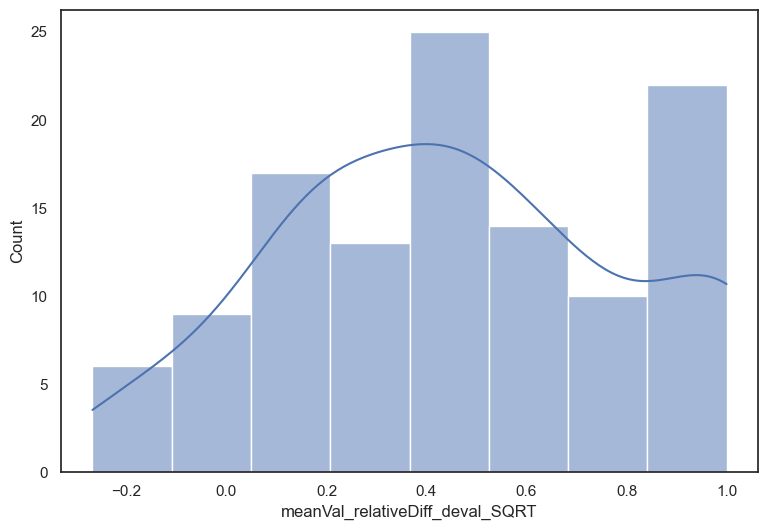

In [57]:
block_df["meanVal_relativeDiff_deval_SQRT"]
# plot hist:
sns.histplot(block_df["meanVal_relativeDiff_deval_SQRT"], kde=True)

Continious

Total n=116, mean=0.456, std=0.351, group_vals=[-1  1]

RUNNING NESTED LOOCV ON TRAINING SET

Total n=116, positive=52 (0.456), group_vals=[-1  1]


Outer CV folds: 100%|██████████| 116/116 [02:20<00:00,  1.21s/it]



NESTED LOOCV REGRESSION RESULTS:
R²: -0.0130
RMSE: 0.3518
MAE: 0.2878
Pearson r: 0.0707 (p=0.4509)
Spearman r: 0.0681 (p=0.4674)


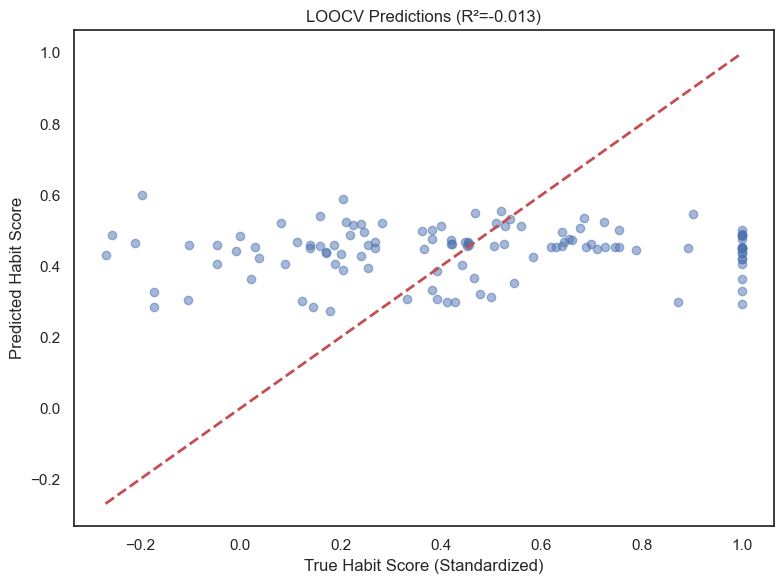


CONFIGURATION SELECTION FREQUENCY:


Model selection frequency:
  SVR_rbf: 101/116 folds (87.1%)
  Lasso: 15/116 folds (12.9%)

Number of features selected:
  5 features: 52/116 folds (44.8%)
  10 features: 33/116 folds (28.4%)
  3 features: 17/116 folds (14.7%)
  all features: 14/116 folds (12.1%)

Most common configurations:
  SVR_rbf_nfeat5_C0.1_kernelrbf_gamma0.01: 52/116 folds (44.8%)
  SVR_rbf_nfeat10_C0.1_kernelrbf_gamma0.01: 33/116 folds (28.4%)
  Lasso_nfeat3_alpha1.0: 15/116 folds (12.9%)
  SVR_rbf_nfeatall_C0.1_kernelrbf_gamma0.01: 14/116 folds (12.1%)
  SVR_rbf_nfeat3_C0.1_kernelrbf_gamma0.01: 2/116 folds (1.7%)

RECOMMENDED CONFIGURATION FOR EXTERNAL DATA:
Model: SVR_rbf
Number of features: 5
Hyperparameters: {'C': 0.1, 'kernel': 'rbf', 'gamma': 0.01}


In [57]:
from collections import Counter
from sklearn.feature_selection import SelectKBest, f_classif
from joblib import Parallel, delayed
from itertools import product
from tqdm import tqdm
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import KFold
from scipy.stats import pearsonr, spearmanr
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_regression  # CHANGE THIS


# ============================================
# PREPARE DATA
# ============================================
day, type_ = 1, "all"
block_df, Dependent_vars = get_daily_data(sub_df_extended, app_IPI_consistency_data, entries_per_session_data, data_for_R, day)
# groups is: feature_data['group'].apply(lambda x: -1 if x == 'short_training' else 1)
block_df = block_df.merge(Dependent_vars[["subID", "meanVal_relativeDiff_deval_SQRT"]], on="subID", how="inner").reset_index(drop=True)
y = block_df["meanVal_relativeDiff_deval_SQRT"]
subjects = block_df["subID"].reset_index(drop=True)
group = pd.Series(block_df["group"]).reset_index(drop=True)
drop_cols = {"subID", "group", "day", "meanVal_relativeDiff_deval_SQRT"}
# drop_cols = {"subID", "group", "day", "meanVal_relativeDiff_deval_SQRT", 'only2nd_IPI_abs_diff_sum', 'only2nd_IPI_abs_diff_sum_std' ,'IPI_abs_diff_sum_std' ,'pressed_all_seq' ,'pressed_only_1st_seq' ,'pressed_only_entry'}
X_cont = block_df.drop(columns=list(drop_cols))

# Convert to arrays
X_cont_arr = X_cont.values
y_arr = np.asarray(y).astype(float)  # Keep as float for regression
subjects = pd.Series(subjects.values).reset_index(drop=True)  # Convert back to Series for compatibility
group = pd.Series(group.values).reset_index(drop=True)  # Convert back to Series for compatibility
group_arr = group.values

# Convert to arrays FIRST (before splitting)
print(f"Total n={len(y)}, mean={y.mean():.3f}, std={y.std():.3f}, group_vals={np.unique(group_arr)}")


# ============================================
# YOUR EXISTING LOOCV CODE STARTS HERE
# ============================================
print(f"\n{'='*60}")
print("RUNNING NESTED LOOCV ON TRAINING SET")
print(f"{'='*60}\n")


# Models to test + # features + settings:
# ----------------------------------------
# models_to_test = {
#     # 'Ridge': {'model': LogisticRegression, 'params': {'penalty': ['l2'], 'C': [0.1, 1, 10], 'solver': ['liblinear'], 'max_iter': [1000]}},
#     # 'Ridge': {'model': LogisticRegression, 'params': {'penalty': ['l2'], 'C': [0.1, 1], 'solver': ['liblinear'], 'max_iter': [1000]}},
#     # 'Lasso': {'model': LogisticRegression, 'params': {'penalty': ['l1'], 'C': [0.1, 1, 10], 'solver': ['liblinear'], 'max_iter': [1000]}},
#     'SVC_rbf': {'model': SVC, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'probability': [True]}}, # VVV
#     # 'RandomForest': {'model': RandomForestClassifier, 'params': {'n_estimators': [50, 100], 'max_depth': [3, 5, 7, None], 'min_samples_leaf': [1, 3, 5, 10]}},
#     'RandomForest': {'model': RandomForestClassifier, 'params': {'n_estimators': [100], 'max_depth': [5, 10], 'min_samples_leaf': [5, 10]}}, # VVV
#     # 'XGBoost': {'model': XGBClassifier, 'params': {}},
#     # 'XGBoost': {'model': XGBClassifier, 'params': {'n_estimators': [100], 'max_depth': [3, 5], 'learning_rate': [0.01, 0.1], 'use_label_encoder': [False], 'eval_metric': ['logloss']}}, 
#     # add ElasticNet Logistic Regression
#     'ElasticNet': {'model': LogisticRegression, 'params': {'penalty': ['elasticnet'], 'C': [0.1, 1, 10], 'l1_ratio': [0, 0.5, 1], 'solver': ['saga'], 'max_iter': [1000]}}, # VVV
#     # 'LDA': {'model': LinearDiscriminantAnalysis, 'params': {}},
# }

models_to_test = {
    # 'ElasticNet': {'model': LogisticRegression, 'params': {'penalty': ['elasticnet'], 'C': [0.1, 1, 10], 'l1_ratio': [0, 0.5, 1], 'solver': ['saga'], 'max_iter': [1000]}},
    # 'SVC_rbf': {'model': SVC, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'gamma': ['scale', 0.01, 0.1], 'probability': [True]}},
    # 'LDA': {'model': LinearDiscriminantAnalysis, 'params': {}},
    # 'SVC_rbf': {'model': SVC, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'probability': [True]}},
    'RandomForest': {'model': RandomForestClassifier, 'params': {'max_depth': [5, 10], 'min_samples_leaf': [5, 10]}},
    # 'RandomForest': {'model': RandomForestClassifier, 'params': {'n_estimators': [50, 100], 'max_depth': [3, 5, 7, None], 'min_samples_leaf': [1, 3, 5, 10]}},
}

models_to_test = {
    'LinearRegression': {'model': LinearRegression, 'params': {}},  # No regularization
    'Ridge': {'model': Ridge, 'params': {'alpha': [0.1, 1.0, 10.0]}},
    'Lasso': {'model': Lasso, 'params': {'alpha': [0.1, 1.0, 10.0], 'max_iter': [5000]}},
    'ElasticNet': {'model': ElasticNet, 'params': {'alpha': [0.1, 1.0, 10.0], 'l1_ratio': [0.5], 'max_iter': [5000]}},  # Only true elastic net
    'SVR_rbf': {'model': SVR, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'gamma': ['scale', 0.01, 0.1]}},
    'RandomForest': {'model': RandomForestRegressor, 'params':  {'max_depth': [5, 10], 'min_samples_leaf': [5, 10]}},
    # 'RandomForest': {'model': RandomForestRegressor, 'params': {'n_estimators': [50, 100], 'max_depth': [3, 5, 7, None], 'min_samples_leaf': [1, 3, 5, 10]}},
}

n_inner_folds = 10
do_PCA = True
pca_var = 0.95
measure_to_pick_model = "accuracy"  # or "auc"
# measure_to_pick_model = "auc"  # or "accuracy"
measure_to_pick_model = "mse"  # or "mse"
measure_to_pick_model = "r2"  # or "mse"


# n_features_to_test = [3, max(2, n_features // 4), max(2, n_features // 2), max(3, int(n_features * 0.75)), n_features]
# n_features_to_test = [1, 2, 3,5,7,10,15,17, 'all']
n_features_to_test = [3,5,10,'all']
# n_features_to_test = ['all']
# n_features_to_test = ['all']
# n_features_to_test = [3,5]


print(f"Total n={len(y_arr)}, positive={int(y_arr.sum())} ({y_arr.mean():.3f}), group_vals={np.unique(group_arr)}")

# X_cont_arr
# y_arr
# subjects
# group
# group_arr


# # Initialize variables
# # --------------------------------------
# y_true_all, y_pred_all, y_pred_proba_all, y_pred_proba_counterfactual_all, y_pred_counterfactual_all, y_pred_proba_counterfactual_x2_all, y_pred_counterfactual_x2_all, matching_group_all, matching_sub_all = [], [], [], [], [], [], [], [], []
# matching_group, matching_sub = [], []
# matching_group_all, matching_sub_all = [], []
# selected_configs = [] # to store configurations selected in each outer fold
# configs_data = {}
# # Run the Nested CV
# # --------------------------------------

# loo = LeaveOneOut()
# inner_cv = StratifiedKFold(n_splits=n_inner_folds, shuffle=True, random_state=42) VVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVV

def _process_outer_fold(fold_idx, train_index, test_index, X_cont_arr, y_arr, group_arr, 
                        subjects, group_series, models_to_test, n_features_to_test, 
                        n_inner_folds, measure_to_pick_model):
    
    configs_data_fold = {}
    
    # Split data (Outer)
    X_cont_train_Outer = X_cont_arr[train_index]
    X_cont_test_Outer = X_cont_arr[test_index]
    y_train_Outer = y_arr[train_index]
    y_test_Outer = y_arr[test_index]
    group_train_Outer = group_arr[train_index]
    group_test_Outer = group_arr[test_index]
    
    matching_sub = subjects.iloc[test_index[0]]
    matching_group = group_series.iloc[test_index[0]]

    # Inner CV - CHANGED to KFold for regression
    inner_cv = KFold(n_splits=n_inner_folds, shuffle=True, random_state=42)
    
    best_inner_score = -np.inf if measure_to_pick_model == "r2" else np.inf  # CHANGED
    best_config = None
    
    for model_name, model_dict in models_to_test.items():
        for n_feat in n_features_to_test:
            param_keys = list(model_dict['params'].keys())
            param_values = list(model_dict['params'].values())
            param_combinations = [dict(zip(param_keys, v)) for v in product(*param_values)]
            
            for params in param_combinations:
                inner_r2 = []
                inner_mse = []
                inner_mae = []
                
                for inner_train_idx, inner_test_idx in inner_cv.split(X_cont_train_Outer):  # CHANGED: removed y stratification
                    X_cont_train_Inner = X_cont_train_Outer[inner_train_idx]
                    X_cont_test_Inner = X_cont_train_Outer[inner_test_idx]
                    y_train_Inner = y_train_Outer[inner_train_idx]
                    y_test_Inner = y_train_Outer[inner_test_idx]
                    group_train_Inner = group_train_Outer[inner_train_idx]
                    group_test_Inner = group_train_Outer[inner_test_idx]

                    # Scale
                    scaler = StandardScaler().fit(X_cont_train_Inner)
                    X_cont_train_Inner_scaled = scaler.transform(X_cont_train_Inner)
                    X_cont_test_Inner_scaled = scaler.transform(X_cont_test_Inner)
                    
                    # # Feature selection
                    # n_features = X_cont_train_Inner_scaled.shape[1]
                    # if n_feat != "all" and n_feat < n_features:
                    #     selector = SelectKBest(f_regression, k=n_feat)
                    #     X_cont_train_Inner_scaled = selector.fit_transform(X_cont_train_Inner_scaled, y_train_Inner)
                    #     X_cont_test_Inner_scaled = selector.transform(X_cont_test_Inner_scaled)

                    # # PCA
                    # if do_PCA:
                    #     pca = PCA(n_components=pca_var).fit(X_cont_train_Inner_scaled)
                    #     X_cont_train_Inner_pca = pca.transform(X_cont_train_Inner_scaled)
                    #     X_cont_test_Inner_pca = pca.transform(X_cont_test_Inner_scaled)
                    # else:
                    #     X_cont_train_Inner_pca = X_cont_train_Inner_scaled
                    #     X_cont_test_Inner_pca = X_cont_test_Inner_scaled


                    # PCA on Inner TRAIN only (BEFORE SelectKBest)
                    if do_PCA:
                        pca = PCA(n_components=pca_var).fit(X_cont_train_Inner_scaled)
                        X_cont_train_Inner_pca = pca.transform(X_cont_train_Inner_scaled)
                        X_cont_test_Inner_pca = pca.transform(X_cont_test_Inner_scaled)
                    else:
                        X_cont_train_Inner_pca = X_cont_train_Inner_scaled
                        X_cont_test_Inner_pca = X_cont_test_Inner_scaled

                    # Feature selection (AFTER PCA)
                    n_features = X_cont_train_Inner_pca.shape[1]
                    if n_feat != "all" and n_feat < n_features:
                        selector = SelectKBest(f_regression, k=n_feat)
                        X_cont_train_Inner_pca = selector.fit_transform(X_cont_train_Inner_pca, y_train_Inner)
                        X_cont_test_Inner_pca = selector.transform(X_cont_test_Inner_pca)


                    # Add group
                    X_train_Inner = np.column_stack((group_train_Inner, X_cont_train_Inner_pca))
                    X_test_Inner = np.column_stack((group_test_Inner, X_cont_test_Inner_pca))

                    # Train model
                    if model_name in ['SVR_rbf', 'SVR', 'LinearRegression']:  # Add any other models without random_state
                        model = model_dict['model'](**params)
                    else:
                        model = model_dict['model'](**params, random_state=42)

                    model.fit(X_train_Inner, y_train_Inner)
                    
                    # Evaluate - CHANGED metrics
                    y_test_Inner_pred = model.predict(X_test_Inner)
                    inner_r2.append(r2_score(y_test_Inner, y_test_Inner_pred))
                    inner_mse.append(mean_squared_error(y_test_Inner, y_test_Inner_pred))
                    inner_mae.append(mean_absolute_error(y_test_Inner, y_test_Inner_pred))
                
                # Average performance
                mean_inner_r2 = np.mean(inner_r2)
                mean_inner_mse = np.mean(inner_mse)
                mean_inner_mae = np.mean(inner_mae)
                
                configs_data_fold[(fold_idx, model_name, n_feat, str(params))] = {
                    'model_name': model_name,
                    'model_class': model_dict['model'],
                    'params': params,
                    'n_features': n_feat,
                    'inner_cv_r2': mean_inner_r2,
                    'inner_cv_mse': mean_inner_mse,
                    'inner_cv_mae': mean_inner_mae,
                    'inner_cv_r2_list': inner_r2,
                    'inner_cv_mse_list': inner_mse,
                    'inner_cv_mae_list': inner_mae
                }
                
                # Select best config - CHANGED
                if measure_to_pick_model == "r2" and mean_inner_r2 > best_inner_score:
                    best_inner_score = mean_inner_r2
                    best_config = {
                        'model_name': model_name,
                        'model_class': model_dict['model'],
                        'params': params,
                        'n_features': n_feat,
                        'inner_cv_r2': mean_inner_r2,
                        'inner_cv_mse': mean_inner_mse,
                        'inner_cv_mae': mean_inner_mae
                    }
                elif measure_to_pick_model == "mse" and mean_inner_mse < best_inner_score:
                    best_inner_score = mean_inner_mse
                    best_config = {
                        'model_name': model_name,
                        'model_class': model_dict['model'],
                        'params': params,
                        'n_features': n_feat,
                        'inner_cv_r2': mean_inner_r2,
                        'inner_cv_mse': mean_inner_mse,
                        'inner_cv_mae': mean_inner_mae
                    }
    
    # Retrain on outer fold (same as before, but remove predict_proba calls)
    scaler = StandardScaler().fit(X_cont_train_Outer)
    X_cont_train_Outer_scaled = scaler.transform(X_cont_train_Outer)
    X_cont_test_Outer_scaled = scaler.transform(X_cont_test_Outer)
    
    # n_features_outer = X_cont_train_Outer_scaled.shape[1]
    # k_final = best_config["n_features"]
    # if k_final == "all" or k_final >= n_features_outer:
    #     X_cont_train_Outer_scaled = X_cont_train_Outer_scaled
    #     X_cont_test_Outer_scaled = X_cont_test_Outer_scaled
    # else:
    #     selector_final = SelectKBest(f_regression, k=best_config['n_features'])
    #     X_cont_train_Outer_scaled = selector_final.fit_transform(X_cont_train_Outer_scaled, y_train_Outer)
    #     X_cont_test_Outer_scaled = selector_final.transform(X_cont_test_Outer_scaled)
    
    # if do_PCA:
    #     pca = PCA(n_components=pca_var).fit(X_cont_train_Outer_scaled)
    #     X_cont_train_Outer_pca = pca.transform(X_cont_train_Outer_scaled)
    #     X_cont_test_Outer_pca = pca.transform(X_cont_test_Outer_scaled)
    # else:
    #     X_cont_train_Outer_pca = X_cont_train_Outer_scaled
    #     X_cont_test_Outer_pca = X_cont_test_Outer_scaled
        
    # PCA on Outer TRAIN only (BEFORE SelectKBest)
    if do_PCA:
        pca = PCA(n_components=pca_var).fit(X_cont_train_Outer_scaled)
        X_cont_train_Outer_pca = pca.transform(X_cont_train_Outer_scaled)
        X_cont_test_Outer_pca = pca.transform(X_cont_test_Outer_scaled)
    else:
        X_cont_train_Outer_pca = X_cont_train_Outer_scaled
        X_cont_test_Outer_pca = X_cont_test_Outer_scaled
    
    # Feature selection (AFTER PCA)
    n_features_outer = X_cont_train_Outer_pca.shape[1]
    k_final = best_config["n_features"]
    if k_final == "all" or k_final >= n_features_outer:
        X_cont_train_Outer_pca = X_cont_train_Outer_pca
        X_cont_test_Outer_pca = X_cont_test_Outer_pca
    else:
        selector_final = SelectKBest(f_regression, k=best_config['n_features'])
        X_cont_train_Outer_pca = selector_final.fit_transform(X_cont_train_Outer_pca, y_train_Outer)
        X_cont_test_Outer_pca = selector_final.transform(X_cont_test_Outer_pca)

    X_train_Outer = np.column_stack((group_train_Outer, X_cont_train_Outer_pca))
    X_test_Outer = np.column_stack((group_test_Outer, X_cont_test_Outer_pca))

    # Counterfactuals
    group_counterfactual_test_Outer = group_test_Outer.copy()
    group_counterfactual_test_Outer = np.where(group_counterfactual_test_Outer == -1, 1, 
                                                np.where(group_counterfactual_test_Outer == 1, -1, 
                                                        group_counterfactual_test_Outer))
    X_counterfactual_test_Outer = np.column_stack((group_counterfactual_test_Outer, X_cont_test_Outer_pca))
    
    group_counterfactual_cf_x2_test_Outer = group_test_Outer.copy()
    group_counterfactual_cf_x2_test_Outer[:] = 3
    X_counterfactual_cf_x2_test_Outer = np.column_stack((group_counterfactual_cf_x2_test_Outer, X_cont_test_Outer_pca))
    
    # Train final model
    if best_config['model_name'] in ['SVR_rbf', 'SVR', 'LinearRegression']:
        model_final = best_config['model_class'](**best_config['params'])
    else:
        model_final = best_config['model_class'](**best_config['params'], random_state=42)

    model_final.fit(X_train_Outer, y_train_Outer)

    # Predict - REMOVED predict_proba
    y_true = y_test_Outer[0]
    y_pred = model_final.predict(X_test_Outer)[0]
    
    # Counterfactual predictions - REMOVED predict_proba
    y_pred_cf = model_final.predict(X_counterfactual_test_Outer)[0]
    y_pred_cf_x2 = model_final.predict(X_counterfactual_cf_x2_test_Outer)[0]

    return {
        "fold_idx": fold_idx,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_pred_counterfactual": y_pred_cf,
        "y_pred_counterfactual_x2": y_pred_cf_x2,
        "matching_sub": matching_sub,
        "matching_group": matching_group,
        "best_config": best_config,
        "configs_data_fold": configs_data_fold,
    }
# Run the Nested CV in parallel over outer folds
loo = LeaveOneOut()
outer_splits = list(loo.split(X_cont_arr))

# n_jobs=-1 uses all cores; set to an int if you want to limit it.
results = Parallel(n_jobs=-1, prefer="processes")(
    delayed(_process_outer_fold)(
        fold_idx, train_index, test_index,
        X_cont_arr, y_arr, group_arr,
        subjects, group,
        models_to_test, n_features_to_test,
        n_inner_folds, measure_to_pick_model
    )
    for fold_idx, (train_index, test_index) in tqdm(list(enumerate(outer_splits)), total=len(outer_splits), desc="Outer CV folds")
)

# Aggregate in fold order
results = sorted(results, key=lambda d: d["fold_idx"])

# Merge configs_data from all folds
configs_data = {}
for r in results:
    configs_data.update(r["configs_data_fold"])

y_true_all = np.array([r["y_true"] for r in results], dtype=float)
y_pred_all = np.array([r["y_pred"] for r in results], dtype=float)
y_pred_counterfactual_all = np.array([r["y_pred_counterfactual"] for r in results], dtype=float)
y_pred_counterfactual_x2_all = np.array([r["y_pred_counterfactual_x2"] for r in results], dtype=float)

matching_sub_all = [r["matching_sub"] for r in results]
matching_group_all = [r["matching_group"] for r in results]
selected_configs = [r["best_config"] for r in results]

# ============================================
# COMPUTE FINAL METRICS
# ============================================
r2 = r2_score(y_true_all, y_pred_all)
mse = mean_squared_error(y_true_all, y_pred_all)
mae = mean_absolute_error(y_true_all, y_pred_all)
rmse = np.sqrt(mse)
pearson_r, pearson_p = pearsonr(y_true_all, y_pred_all)
spearman_r, spearman_p = spearmanr(y_true_all, y_pred_all)

print(f'\n{"="*60}')
print(f'NESTED LOOCV REGRESSION RESULTS:')
print(f'{"="*60}')
print(f'R²: {r2:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'Pearson r: {pearson_r:.4f} (p={pearson_p:.4f})')
print(f'Spearman r: {spearman_r:.4f} (p={spearman_p:.4f})')


# Optional: Plot predictions vs actual
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.scatter(y_true_all, y_pred_all, alpha=0.5)
plt.plot([y_true_all.min(), y_true_all.max()], 
         [y_true_all.min(), y_true_all.max()], 'r--', lw=2)
plt.xlabel('True Habit Score (Standardized)')
plt.ylabel('Predicted Habit Score')
plt.title(f'LOOCV Predictions (R²={r2:.3f})')
plt.tight_layout()
plt.show()

# ============================================
# ANALYZE CONFIGURATION STABILITY
# ============================================

print(f'\n{"============================================================"}')
print(f'CONFIGURATION SELECTION FREQUENCY:')
print(f'\n{"============================================================"}')

# Count model selections
model_counts = Counter([c['model_name'] for c in selected_configs])
print(f'\nModel selection frequency:')
for model, count in model_counts.most_common():
    print(f'  {model}: {count}/{len(selected_configs)} folds ({100*count/len(selected_configs):.1f}%)')

# Count n_features selections
nfeat_counts = Counter([c['n_features'] for c in selected_configs])
print(f'\nNumber of features selected:')
for nfeat, count in nfeat_counts.most_common():
    print(f'  {nfeat} features: {count}/{len(selected_configs)} folds ({100*count/len(selected_configs):.1f}%)')

# Most common hyperparameters
print(f'\nMost common configurations:')
config_strings = [f"{c['model_name']}_nfeat{c['n_features']}_" + "_".join([f"{k}{v}" for k, v in c['params'].items() if k not in ['probability', 'solver', 'max_iter', 'random_state']]) for c in selected_configs]
config_counts = Counter(config_strings)
for config, count in config_counts.most_common(5):
    print(f'  {config}: {count}/{len(selected_configs)} folds ({100*count/len(selected_configs):.1f}%)')

# ============================================
# DETERMINE "BEST" CONFIGURATION FOR DEPLOYMENT
# ============================================
# Use most common configuration
most_common_model = model_counts.most_common(1)[0][0]
most_common_nfeat = nfeat_counts.most_common(1)[0][0]

# For this model, find most common hyperparameters
configs_for_model = [c for c in selected_configs if c['model_name'] == most_common_model]

# Get most common hyperparameter values
best_deployment_config = {
    'model_name': most_common_model,
    'n_features': most_common_nfeat,
    'params': {}
}

for key in configs_for_model[0]['params'].keys():
    param_values = [c['params'][key] for c in configs_for_model]
    best_deployment_config['params'][key] = Counter(param_values).most_common(1)[0][0]

print(f'\n{"="*60}')
print(f'RECOMMENDED CONFIGURATION FOR EXTERNAL DATA:')
print(f'{"="*60}')
print(f'Model: {best_deployment_config["model_name"]}')
print(f'Number of features: {best_deployment_config["n_features"]}')
print(f'Hyperparameters: {best_deployment_config["params"]}')


In [ ]:
feature_data.head()



,subID,group,entries,pressed_all_seq,pressed_only_1st_seq,pressed_only_entry,secsToPress1_mean,secsToPress1_std,secsToPress2_mean,secsToPress2_std,secsToExitAfterOutcomeTime_mean,secsToExitAfterOutcomeTime_std,secsToPress1_secsToPress2_ratio,sequenceCompletionTime_mean,sequenceCompletionTime_std,deltaSecStartTime_mean,deltaSecStartTime_std,sessions_count,day,AVG_entries_per_session,IPI_abs_diff_sum,IPI_abs_diff_sum_std,only2nd_IPI_abs_diff_sum,only2nd_IPI_abs_diff_sum_std
0,101,-1,106,1.000000,0.0,0.000000,1.186670,0.936308,0.467934,0.366385,3.619227,1.171667,2.535977,1.654604,1.004547,383.834810,1252.579118,16,1.0,6.625000,0.776882,0.878451,0.159559,0.371817
1,102,-1,428,0.997664,0.0,0.002336,0.810108,0.923943,0.435286,0.511291,3.659427,1.111813,1.861094,1.245393,1.071587,110.652391,526.762496,22,1.0,19.454545,0.747847,0.881177,0.217813,0.382910
2,103,-1,80,1.000000,0.0,0.000000,0.973312,1.203973,0.626225,0.449941,4.016000,2.268288,1.554254,1.599537,1.473853,533.332215,2185.158193,10,1.0,8.000000,0.586987,0.926134,0.242184,0.414858
3,105,-1,55,0.981818,0.0,0.018182,0.720278,0.520875,0.537426,0.220039,5.237863,1.699927,1.340236,1.257704,0.562911,724.135019,2317.608407,9,1.0,6.111111,0.321000,0.383767,0.118118,0.190117
4,106,-1,548,0.987226,0.0,0.012774,1.015020,2.883550,0.374314,0.286823,3.320006,1.161875,2.711680,1.389335,2.919145,93.527603,584.229625,22,1.0,24.909091,0.631776,0.756494,0.198248,0.311263


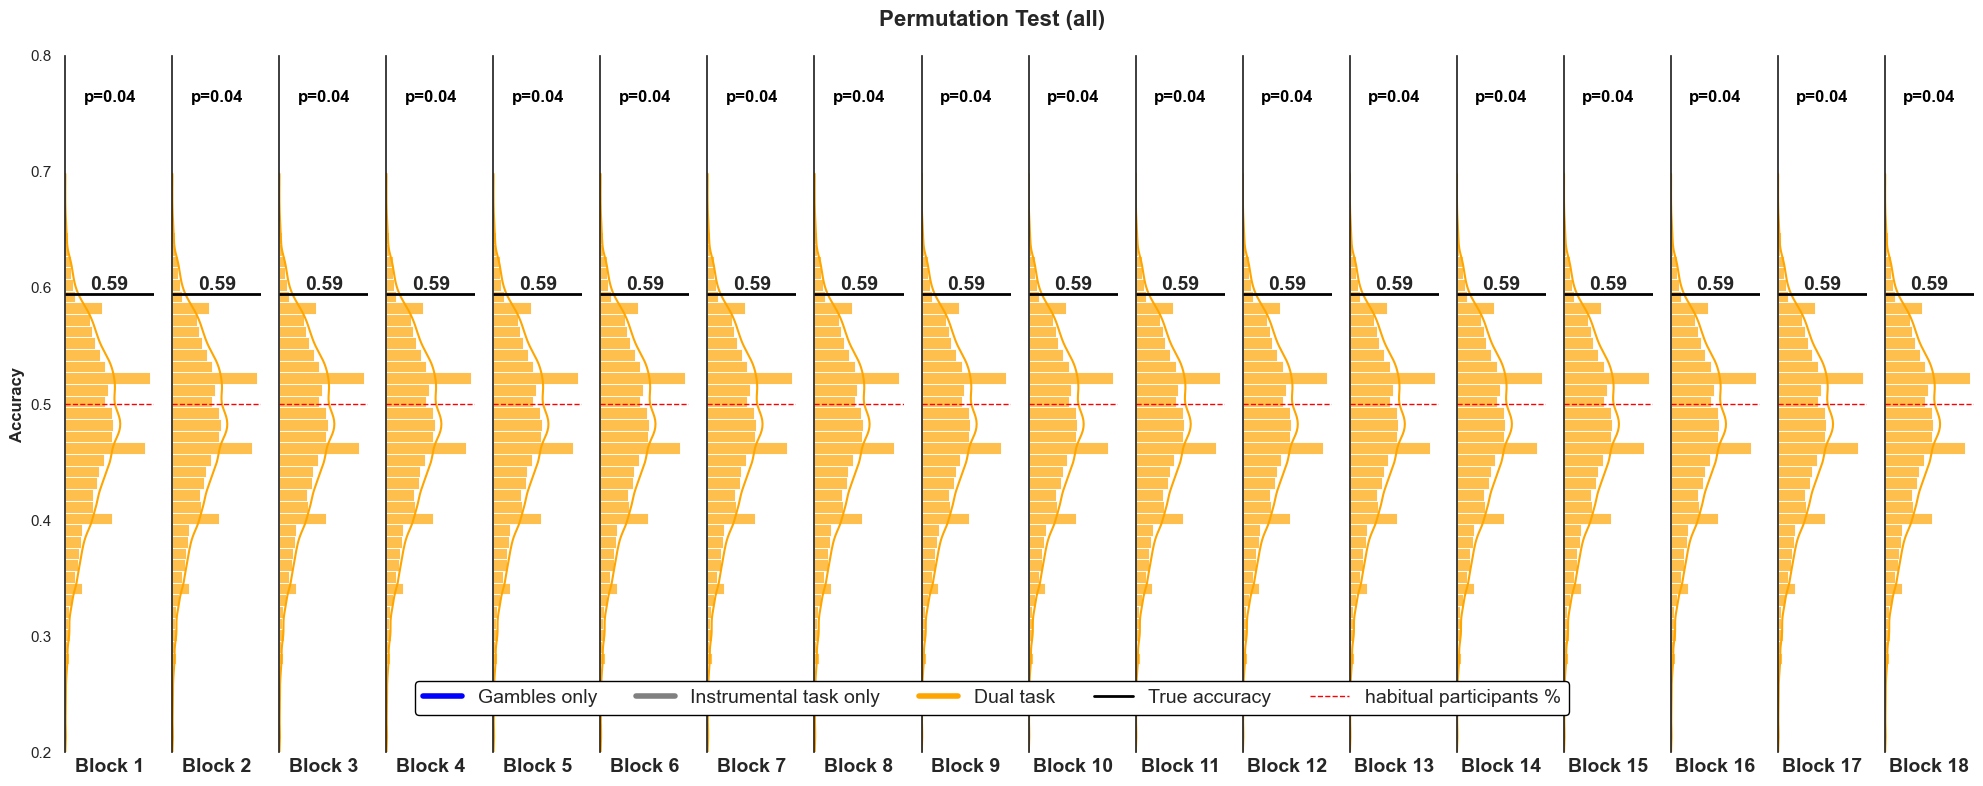

In [161]:
# for type_ in ['short', 'long', 'all']:    
for type_ in ['all']:    
    # Assuming LOOCV_SVC_results is defined
    loocv_results_long = LOOCV_SVC_results[type_]

    # Prepare the data
    blocks = list(loocv_results_long.keys())
    all_data = []

    for block in blocks:
        permuted_accuracies = loocv_results_long['permutations']['permuted_accuracies']
        block_data = pd.DataFrame({'Accuracy': permuted_accuracies, 'Block': f'Block {block}'})
        all_data.append(block_data)

    df = pd.concat(all_data)

    # Set up the plot
    fig, axes = plt.subplots(1, len(blocks), figsize=(20, 8), sharey=True)
    fig.subplots_adjust(wspace=0)

    pal = sns.color_palette("coolwarm", n_colors=len(blocks))

    # Create the ridge plot
    for i, (ax, block) in enumerate(zip(axes, blocks)):
        data = df['Accuracy']
        true_acc = loocv_results_long['accuracy']
        p_value = loocv_results_long['permutations']['p_value']
        
        if block in [1, 5]:
            hist_color = 'blue'
            label = 'gamble only'
        elif block in [2, 3]:
            hist_color = 'gray'
            label = 'instrumental only'
        else:
            hist_color = 'orange'
            label = 'dual'
        # # Plot the KDE
        # sns.kdeplot(y=data, fill=True, color=pal[i], alpha=0.7, 
        #             linewidth=0.5, ax=ax)
        # Plot the KDE
        sns.histplot(y=data, fill=True, alpha=0.7, 
                    ax=ax, kde=True, binwidth=0.01, color=hist_color, label=label)
        
        # Remove top, right, and bottom spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        # ax.spines['left'].set_visible(False)  # Add this line to remove the left spine

        # Remove x-axis ticks
        ax.set_xticks([])
        
        # Add the block label
        ax.set_xlabel(f'Block {i+1}', fontweight='bold', fontsize=14)
        
        # Add the true accuracy line
        ax.axhline(y=true_acc, color='black', linewidth=2)
        # Add majorit class line:
        ax.axhline(y=loocv_results_long['y_true'].mean(), color='red', linewidth=1, linestyle='--', label='habitual participants %')

        # print the true accuracy above the line:
        ax.text(0.5, true_acc, f'{true_acc:.2f}', ha='center', va='bottom', 
                transform=ax.get_yaxis_transform(), fontsize=14, fontweight='bold')
        
        # Add the p-value
        fontweight = 'bold' if p_value < 0.05 else 'normal'
        # make black if <0.05, dark grey if <0.1, light grey if >0.1
        fontcolor = 'black' if p_value < 0.05 else (51/255, 51/255, 51/255) if p_value < 0.1 else 'lightgrey'
        ax.text(0.5, 0.95, f'p={p_value:.3g}', ha='center', va='top', transform=ax.transAxes, fontweight=fontweight, color=fontcolor)

    # Set y-axis limits and label
    axes[0].set_ylim(0.2, 0.8)
    axes[0].set_ylabel('Accuracy', fontweight='bold')

    # add a custom legend with blue, grey and orange:
    legend_elements = [Line2D([0], [0], color='blue', lw=4, label='Gambles only'),
                    Line2D([0], [0], color='gray', lw=4, label='Instrumental task only'),
                    Line2D([0], [0], color='orange', lw=4, label='Dual task'),
                    Line2D([0], [0], color='black', lw=2, label='True accuracy', linestyle='-'),
                    Line2D([0], [0], color='red', lw=1, label='habitual participants %', linestyle='--')]
                    
    fig.legend(handles=legend_elements, fontsize=14, framealpha=1, edgecolor='black',facecolor='white', ncol=5, loc='center', bbox_transform=fig.transFigure, bbox_to_anchor=(0.5, 0.12))

    # Add title
    fig.suptitle(f'Permutation Test ({type_})', fontweight='bold', fontsize=16)

    plt.tight_layout()
    plt.show()

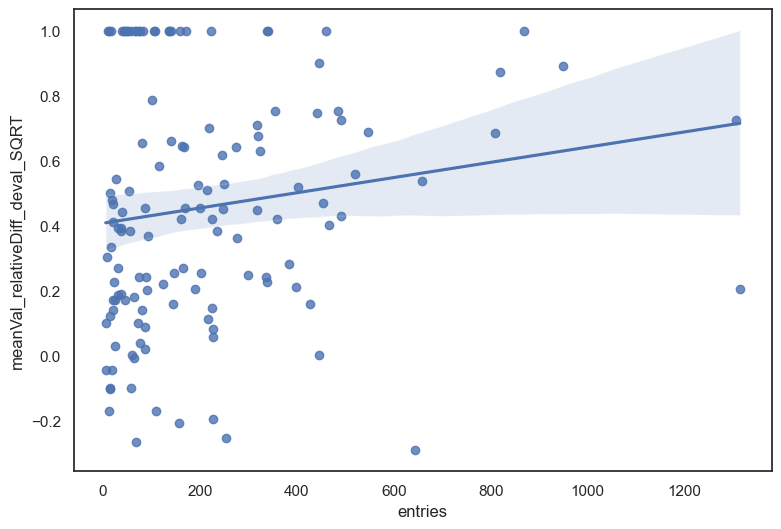

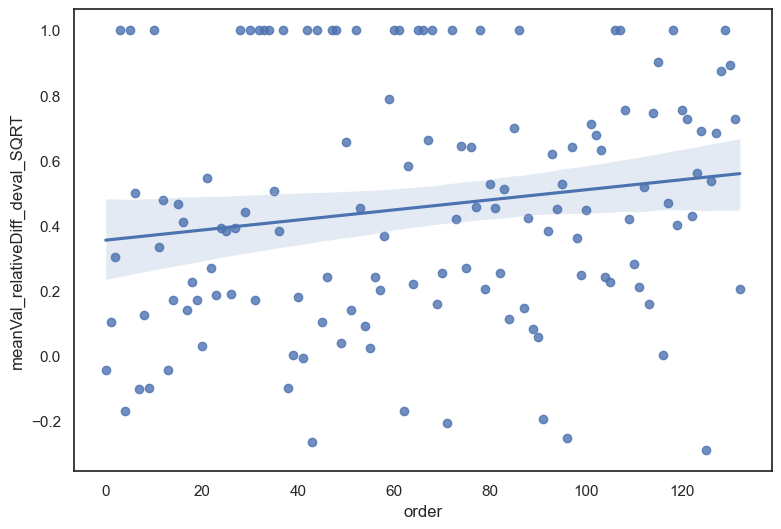

In [113]:
block_data.meanVal_relativeDiff_deval_SQRT.median()
# show a box plot for the two groups:
# plot 
combined = pd.merge(feature_data, Dependent_vars, on='subID')
combined.head()
# plot meanVal_relativeDiff_deval_SQRT as a funciton of entries (with a reg line)
sns.regplot(x='entries', y='meanVal_relativeDiff_deval_SQRT', data=combined)
plt.show()

# now do spearman (ie aranbge by order)
combined_copy = combined.copy()
combined_copy.sort_values(by='entries', inplace=True)
combined_copy.head()
# now create an order variable:
combined_copy['order'] = np.arange(len(combined_copy))
# now plot with the x as the order and y as the meanVal_relativeDiff_deval_SQRT
sns.regplot(x='order', y='meanVal_relativeDiff_deval_SQRT', data=combined_copy)
plt.show()



In [91]:
block_data.head()

,subID,devaluation,still_valued,still_valued_post_deval,still_valued_post_deval_week1,still_valued_replacing_devaluation,still_valued_week1,mean_still_valued,mean_still_valued_all,devaluation_SQRT,still_valued_SQRT,still_valued_post_deval_SQRT,mean_still_valued_SQRT,mean_still_valued_all_SQRT,postVal_minus_deval,stillVal_minus_deval,stillVal_minus_postVal,preVal_relativeDiff_deval,postVal_relativeDiff_deval,preVal_relativeDiff_deval_SQRT,postVal_relativeDiff_deval_SQRT,meanVal_minus_deval,meanAllVal_minus_deval,meanVal_minus_deval_SQRT,meanAllVal_minus_deval_SQRT,meanVal_relativeDiff_deval,meanAllVal_relativeDiff_deval,meanVal_relativeDiff_deval_SQRT,meanAllVal_relativeDiff_deval_SQRT,prcChange_preToDeval,group,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14
0,101,0.0,24.0,12.0,NaN,NaN,NaN,18.0,18.0,0.000000,4.898979,3.464102,4.242641,4.242641,12.0,24.0,12.0,1.000000,1.000000,1.000000,1.000000,18.0,18.0,4.242641,4.242641,1.000000,1.000000,1.000000,1.000000,-100.000000,-1.398412,-0.571311,0.000189,0.157886,-1.327307,0.103539,-1.192010,0.830822,0.276309,-0.343639,-0.199320,-0.422671,-0.456648,-0.079658,-0.226029
1,102,20.0,72.0,4.0,NaN,NaN,NaN,38.0,38.0,4.472136,8.485281,2.000000,6.164414,6.164414,-16.0,52.0,68.0,0.565217,-0.666667,0.309718,-0.381966,18.0,18.0,1.692278,1.692278,0.310345,0.310345,0.159100,0.159100,-72.222222,-1.398412,-1.342863,0.786014,-1.553127,0.430878,-0.238529,-0.982420,0.286782,0.251966,0.166054,-0.303840,-0.912238,-0.129995,-0.307649,-0.137827
2,103,14.0,45.0,4.0,NaN,NaN,NaN,24.5,24.5,3.741657,6.708204,2.000000,4.949747,4.949747,-10.0,31.0,41.0,0.525424,-0.555556,0.283884,-0.303337,10.5,10.5,1.208090,1.208090,0.272727,0.272727,0.138998,0.138998,-68.888889,-1.398412,0.191594,-0.349209,-0.180192,-1.176310,-0.647055,0.362709,1.642974,-0.026139,-0.782092,1.058032,0.077066,1.470503,0.359999,-0.160341
3,105,2.0,35.0,2.0,NaN,NaN,NaN,18.5,18.5,1.414214,5.916080,1.414214,4.301163,4.301163,0.0,33.0,33.0,0.891892,0.000000,0.614145,0.000000,16.5,16.5,2.886949,2.886949,0.804878,0.804878,0.505120,0.505120,-94.285714,-1.398412,-0.981600,-1.210065,0.980373,-1.507258,0.818756,1.458609,0.718661,0.372724,0.041318,0.842108,1.050357,0.725924,-0.798629,0.165654
4,106,2.0,67.0,51.0,NaN,NaN,NaN,59.0,59.0,1.414214,8.185353,7.141428,7.681146,7.681146,49.0,65.0,16.0,0.942029,0.924528,0.705359,0.669408,57.0,57.0,6.266932,6.266932,0.934426,0.934426,0.689025,0.689025,-97.014925,-1.398412,-1.248707,1.671197,-0.984699,-1.378630,0.750441,-0.095418,0.278339,0.074001,0.690320,-1.652119,-0.151807,0.031225,-0.115730,-0.174661


In [77]:
block_data[block_data.devaluation==0]

0.4285714285714286

# Get consmption test into account

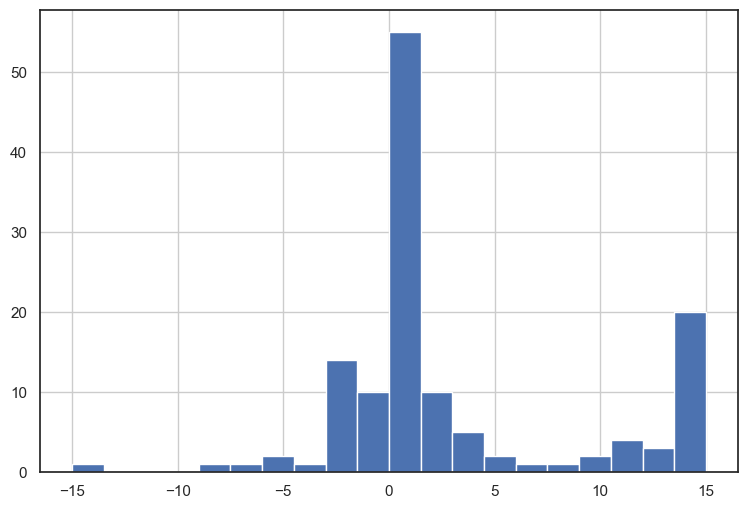

<Axes: >

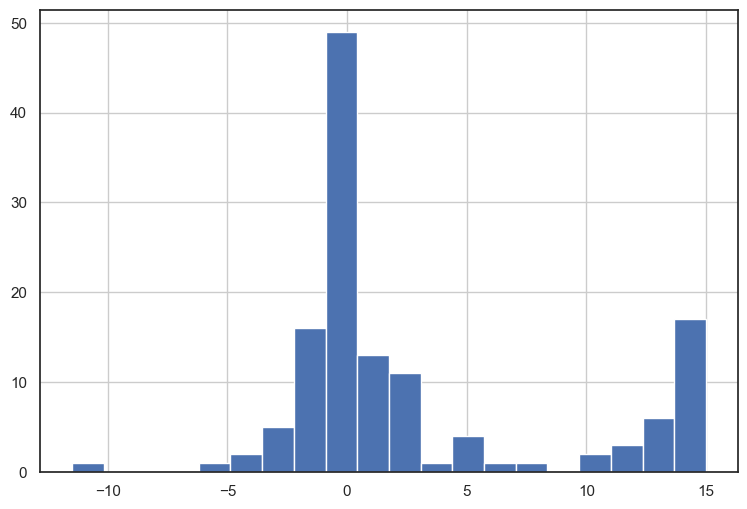

In [755]:
# Load the data
app_data = pd.read_csv('data/extracted_data/all_data_for_R.csv')
# Assign 'short' to 'training_length' where 'group' is 'short_training'
app_data.loc[app_data['group'] == 'short_training', 'training_length'] = 'short'

# Assign 'long' to 'training_length' where 'group' is not 'short_training'
app_data.loc[app_data['group'] != 'short_training', 'training_length'] = 'long'

# Select the relevant columns
consumption = app_data[['subID', 'cave_gold_still_valued', 'cave_gold_devaluation', 'cave_gold_still_valued_post_deval', 'devaluation', 'group', 'training_length']].copy()

# Rename the columns
consumption.rename(columns={
    'subID': 'sub',
    'cave_gold_still_valued': 'gold_pre_val',
    'cave_gold_devaluation': 'gold_deval',
    'cave_gold_still_valued_post_deval': 'gold_post_val'
}, inplace=True)

# Create a new column 'gold_mean_val' as the row-wise mean of 'gold_pre_val' and 'gold_post_val', ignoring NaNs
consumption['gold_mean_val'] = consumption[['gold_pre_val', 'gold_post_val']].mean(axis=1, skipna=True)

consumption['gold_pre_val_minus_deval'] = consumption['gold_pre_val'] - consumption['gold_deval']
consumption['gold_mean_val_minus_deval'] = consumption['gold_mean_val'] - consumption['gold_deval']
consumption.gold_pre_val_minus_deval.hist(bins=20)
plt.show()
consumption.gold_mean_val_minus_deval.hist(bins=20)

# PAST STUFF: Event plots

>>> Create a new data variable with times in common time (i.e., day one is set to same date etc.)
>>> Creating a dictionary with the relevant data.


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:207: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:217: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:227: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
/usr/local/lib/python3.7/dist-packages/IPython/core/pylabtools.py:128: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


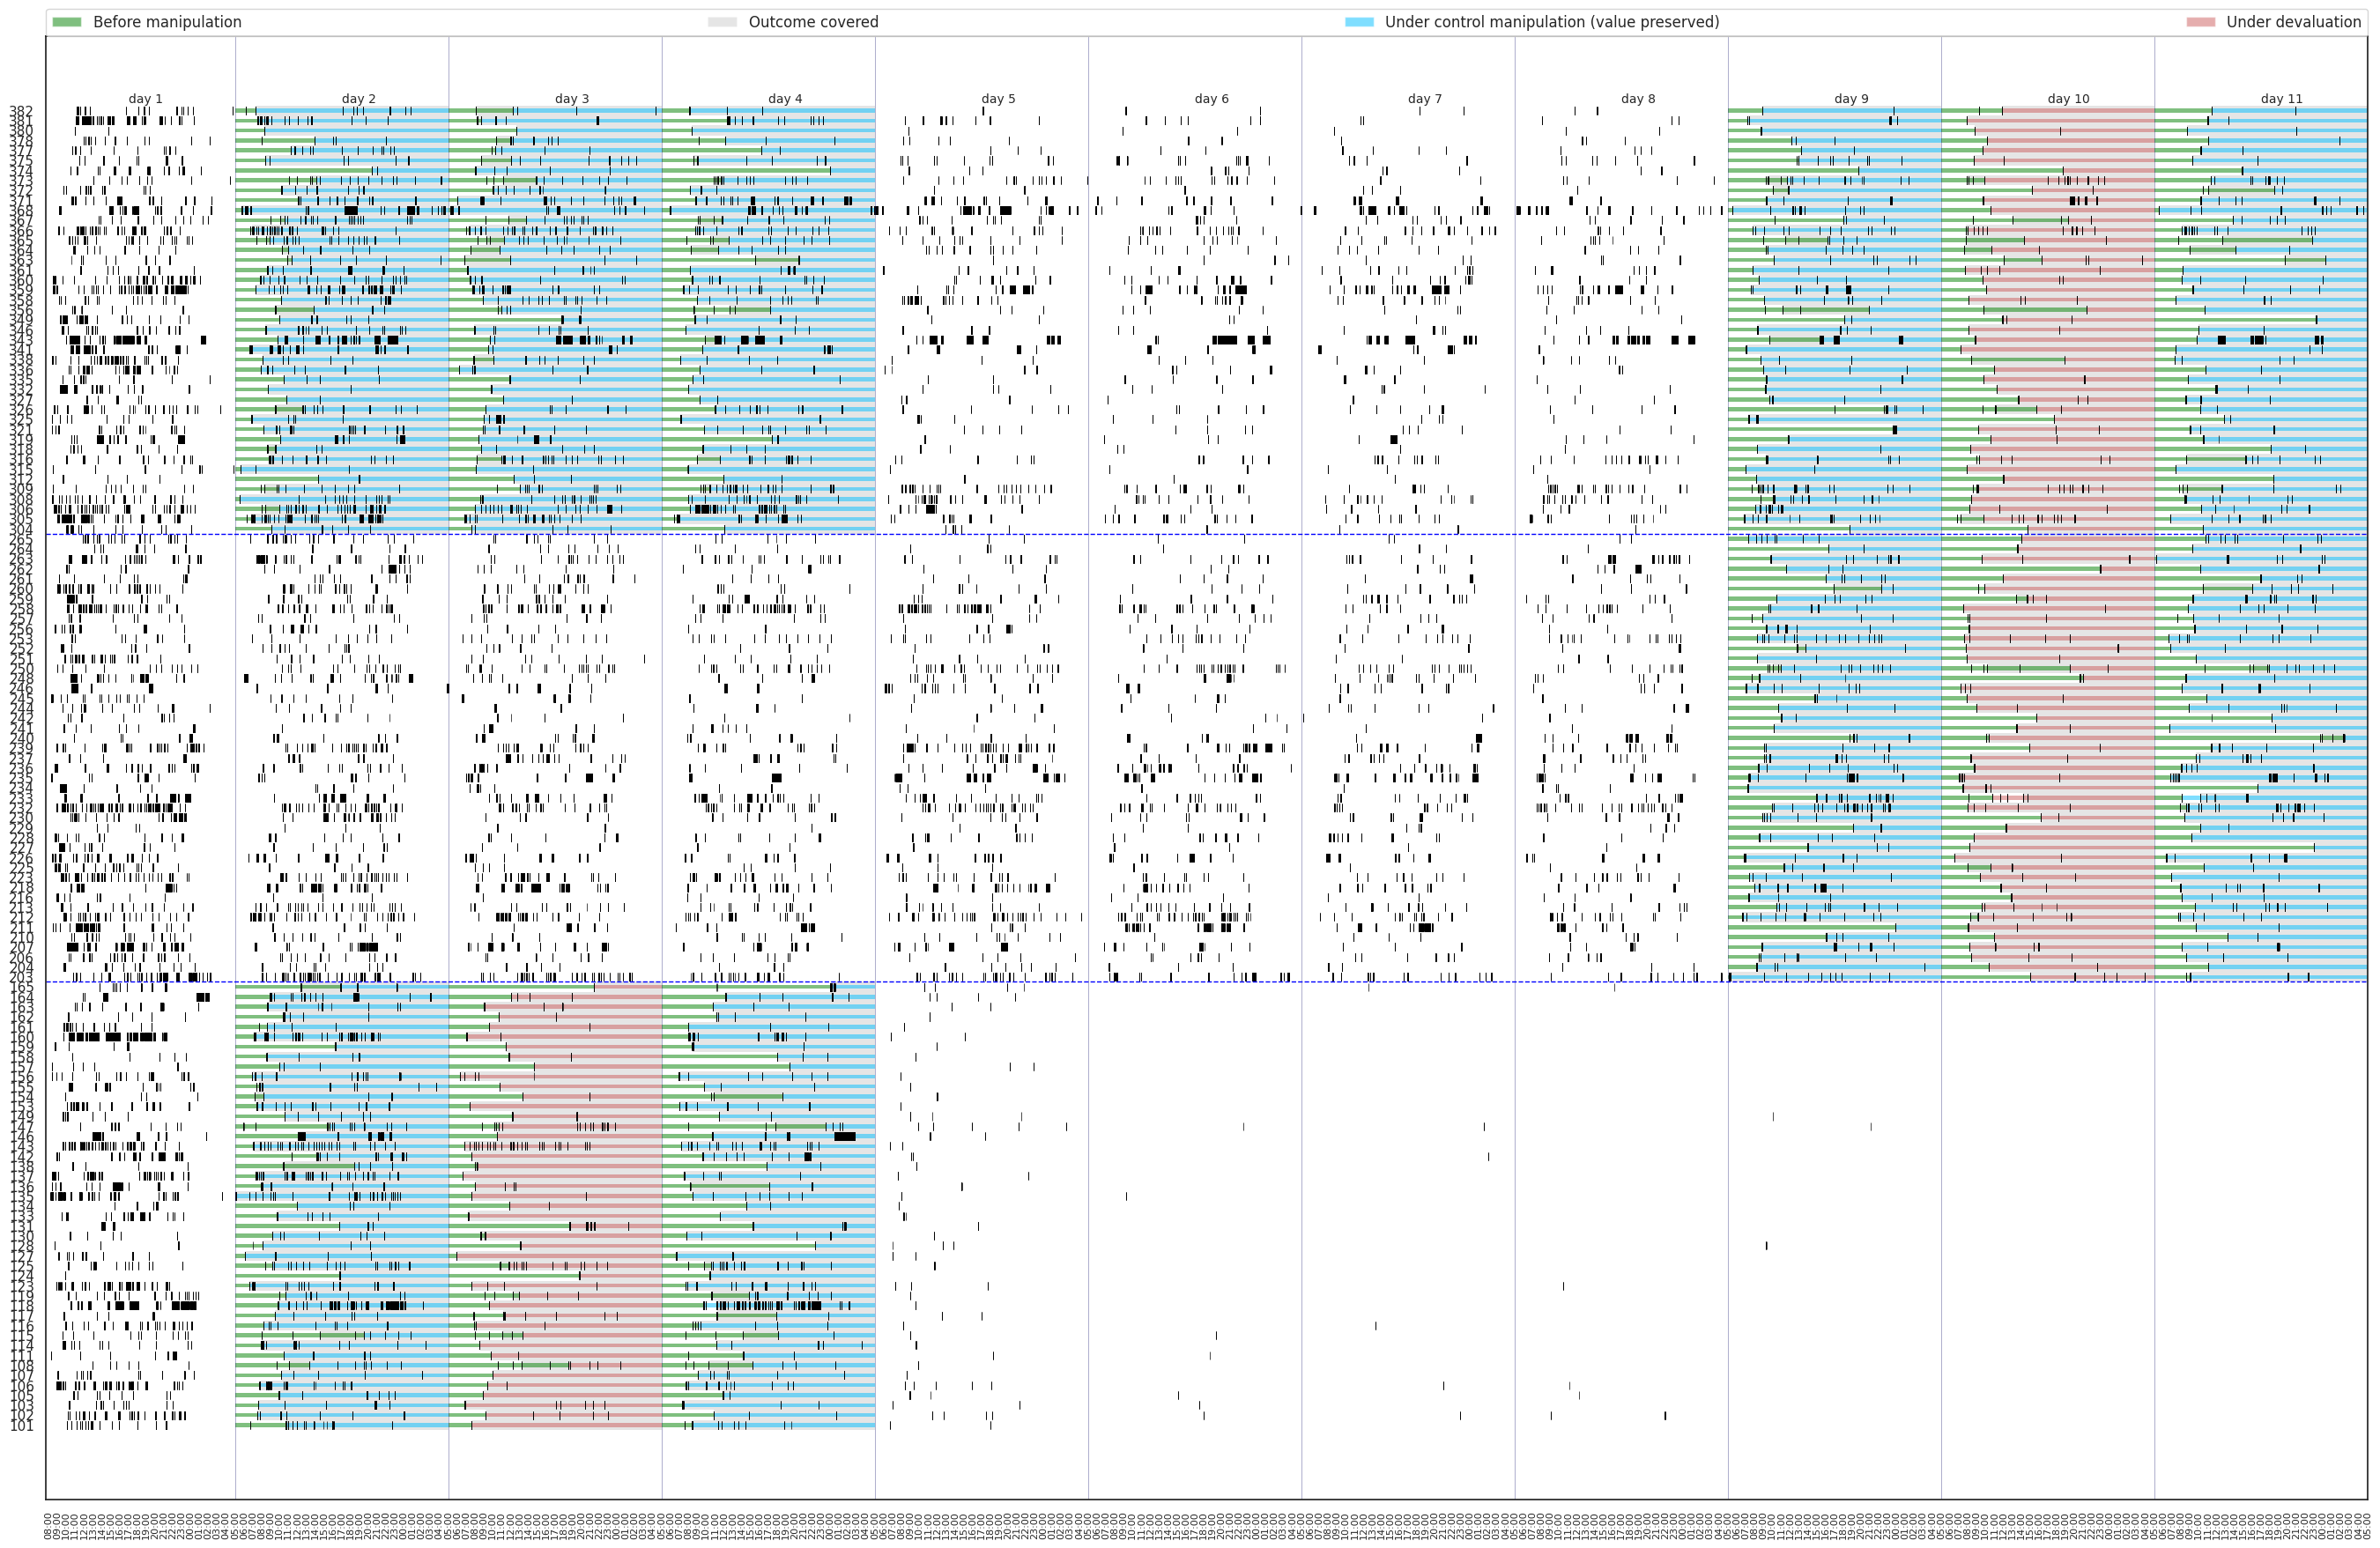

In [ ]:
#@title event plots across all days { form-width: "5%" }
sns.set_theme(style="white")

def plotEvents(differentiatePressesByColor = True, differentiatePressesByLineHeight = True, showOnlyAlignedManipulationDays = False, figSize = (12,5), daysRange = (1,12)):
  '''
  This fucntion plot the events during the app in a given range or alternatively only of the manipulation days (when showOnlyAlignedManipulationDays = True).
  The range of the days shown is indicated in daysRange(first day, last day) in case showOnlyAlignedManipulationDays=False.
  It can use different colors to indicate whether the event is includes only entering, press once or pressed twice (when differentiatePressesByColor = True and/or differentiatePressesByLineHeight = False).
  * showOnlyAlignedManipulationDays = True daysRange is redundant.

  *** IMPORTANT ***
  To edit if necessary:
  In some cases additional editing of the legend is required
  '''
  # Parameters:
  # ------------------------
  # labels:
  xlabelFontSize = 8
  line_colors = [[1,0.8,0],[1,0.4,0],[1,0,0]] if differentiatePressesByColor else ['black'] * 3
  # colors:
  outcome_covered_color = {'color': 'gray', 'alpha': 0.2}
  before_manipulation_activated_color = {'color': 'green', 'alpha': 0.5}
  under_still_devalued_control_color = {'color': 'deepskyblue', 'alpha': 0.5}
  under_devaluation_color = {'color': 'indianred', 'alpha': 0.5}
  # event lines:
  linelengths = [0.4, 0.6, 0.8] if differentiatePressesByLineHeight else [0.8] * 3
  linewidth = 0.5
  # days range to present (if showOnlyAlignedManipulationDays=False)
  daysRange = (1,3) if showOnlyAlignedManipulationDays else daysRange
  # number of potential subject IDs in each group (i.e., every 100 or every 1000)
  potentialSubIdsPerGroup = 100

  # HANDLE DATA:
  # ------------------------
  # create a common time for all participants (using a mode starting date)
  print('>>> Create a new data variable with times in common time (i.e., day one is set to same date etc.)')
  commonTimeDF = data.sub_df.copy()
  if showOnlyAlignedManipulationDays:
    commonTimeDF = commonTimeDF[(commonTimeDF['manipulationToday']=='still_valued') | (commonTimeDF['manipulationToday']=='devaluation') | (commonTimeDF['manipulationToday']=='still_valued_post_deval')]
    commonTimeDF.loc[commonTimeDF['manipulationToday']=='still_valued','day'] = 1
    commonTimeDF.loc[commonTimeDF['manipulationToday']=='devaluation','day'] = 2
    commonTimeDF.loc[commonTimeDF['manipulationToday']=='still_valued_post_deval','day'] = 3

  for timeVar in timeInStringColumns:
    for i,x in enumerate(commonTimeDF[timeVar]):
      if not pd.isnull(x):
        try:
          commonTimeDF.iloc[i, commonTimeDF.columns.get_loc(timeVar)] = (x - timedelta(hours=dailyOffsetHours)).replace(year=2000,month=1,day=int(commonTimeDF.day.iloc[i])) + timedelta(hours=dailyOffsetHours)
        except Exception as e:
          print('>>> A problem in converting element ' + str(i) + ' in ' + str(timeVar) + ' of the specified time ' + str(x) + '.')
          print('>>> Error type: ' + str(e))


  subjects = commonTimeDF.subId.unique()
  n_subjects = len(subjects)
  lineoffsets = np.linspace(start=1, stop=n_subjects, num=n_subjects)

  # Create time dict of all subjects. The times extracted are the startTime in all cases.
  print('>>> Creating a dictionary with the relevant data.')
  timeDict = {}
  for sub in subjects:
    timeDict[sub] = {
        'startTime': commonTimeDF[(commonTimeDF.subId==sub) & (commonTimeDF.day>=daysRange[0]) & (commonTimeDF.day<=daysRange[1]) & (~commonTimeDF.startTime.isna())].startTime, #get when there was startTime
        'startTimeFollowedBy1Press': commonTimeDF[(commonTimeDF.subId==sub) & (commonTimeDF.day>=daysRange[0]) & (commonTimeDF.day<=daysRange[1]) & (~commonTimeDF.press1Time.isna())].startTime, #get when there was press1Time
        'startTimeFollowedBy2Presses': commonTimeDF[(commonTimeDF.subId==sub) & (commonTimeDF.day>=daysRange[0]) & (commonTimeDF.day<=daysRange[1]) & (~commonTimeDF.press2Time.isna())].startTime, #get when there was press2Time
        'cloudsStartTimes': [],
        'still_valued_indicationTrialEndTime': {'day': [], 'time': []},
        'devaluation_indicationTrialEndTime': {'day': [], 'time': []},
        'valued_AGAIN_indicationTrialEndTime': {'day': [], 'time': []},
        'still_valued_week1_indicationTrialEndTime': {'day': [], 'time': []},
        'still_valued_replacing_devaluation_indicationTrialEndTime': {'day': [], 'time': []},
        'still_valued_post_deval_week1_indicationTrialEndTime': {'day': [], 'time': []},
    }
    for day in commonTimeDF.day.unique():
      if not commonTimeDF[(commonTimeDF.subId==sub) &(commonTimeDF.day==day) & (commonTimeDF.hideOutcome == True)].empty:
        timeDict[sub]['cloudsStartTimes'].append(commonTimeDF[(commonTimeDF.subId==sub) &(commonTimeDF.day==day) & (commonTimeDF.hideOutcome == True)].iloc[0].startTime)
    
    still_valued_indicationTrialEndTime_row = commonTimeDF[(commonTimeDF.subId==sub) & (commonTimeDF.activateManipulation==True) & (commonTimeDF.manipulationToday=='still_valued') & (~commonTimeDF.manipulationConfirmationTime.isnull())]
    timeDict[sub]['still_valued_indicationTrialEndTime']['time'] = still_valued_indicationTrialEndTime_row.manipulationConfirmationTime
    timeDict[sub]['still_valued_indicationTrialEndTime']['day'] = still_valued_indicationTrialEndTime_row.day

    devaluation_indicationTrialEndTime_row = commonTimeDF[(commonTimeDF.subId==sub) & (commonTimeDF.activateManipulation==True) & (commonTimeDF.manipulationToday=='devaluation') & (~commonTimeDF.manipulationConfirmationTime.isnull())]
    timeDict[sub]['devaluation_indicationTrialEndTime']['time'] = devaluation_indicationTrialEndTime_row.manipulationConfirmationTime
    timeDict[sub]['devaluation_indicationTrialEndTime']['day'] = devaluation_indicationTrialEndTime_row.day

    valued_AGAIN_indicationTrialEndTime_row = commonTimeDF[(commonTimeDF.subId==sub) & (commonTimeDF.activateManipulation==True) & (commonTimeDF.manipulationToday=='still_valued_post_deval') & (~commonTimeDF.manipulationConfirmationTime.isnull())]
    timeDict[sub]['valued_AGAIN_indicationTrialEndTime']['time'] = valued_AGAIN_indicationTrialEndTime_row.manipulationConfirmationTime
    timeDict[sub]['valued_AGAIN_indicationTrialEndTime']['day'] = valued_AGAIN_indicationTrialEndTime_row.day

    # The parallel manipulations:
    still_valued_week1_indicationTrialEndTime_row = commonTimeDF[(commonTimeDF.subId==sub) & (commonTimeDF.activateManipulation==True) & (commonTimeDF.manipulationToday=='still_valued_week1') & (~commonTimeDF.manipulationConfirmationTime.isnull())]
    timeDict[sub]['still_valued_week1_indicationTrialEndTime']['time'] = still_valued_week1_indicationTrialEndTime_row.manipulationConfirmationTime
    timeDict[sub]['still_valued_week1_indicationTrialEndTime']['day'] = still_valued_week1_indicationTrialEndTime_row.day

    still_valued_replacing_devaluation_indicationTrialEndTime_row = commonTimeDF[(commonTimeDF.subId==sub) & (commonTimeDF.activateManipulation==True) & (commonTimeDF.manipulationToday=='still_valued_replacing_devaluation') & (~commonTimeDF.manipulationConfirmationTime.isnull())]
    timeDict[sub]['still_valued_replacing_devaluation_indicationTrialEndTime']['time'] = still_valued_replacing_devaluation_indicationTrialEndTime_row.manipulationConfirmationTime
    timeDict[sub]['still_valued_replacing_devaluation_indicationTrialEndTime']['day'] = still_valued_replacing_devaluation_indicationTrialEndTime_row.day

    still_valued_post_deval_week1_indicationTrialEndTime_row = commonTimeDF[(commonTimeDF.subId==sub) & (commonTimeDF.activateManipulation==True) & (commonTimeDF.manipulationToday=='still_valued_post_deval_week1') & (~commonTimeDF.manipulationConfirmationTime.isnull())]
    timeDict[sub]['still_valued_post_deval_week1_indicationTrialEndTime']['time'] = still_valued_post_deval_week1_indicationTrialEndTime_row.manipulationConfirmationTime
    timeDict[sub]['still_valued_post_deval_week1_indicationTrialEndTime']['day'] = still_valued_post_deval_week1_indicationTrialEndTime_row.day

  # CREATE THE PLOT:
  # ------------------------
  fig, axs = plt.subplots()
  # create a raster plot of app entries (including the their number of presses)
  for idx, sub in enumerate(timeDict.keys()):
    axs.eventplot(timeDict[sub]['startTime'], colors=line_colors[0], lineoffsets=lineoffsets[idx] - (linelengths[2]-linelengths[0])/2,
                        linelengths=linelengths[0], linewidths=linewidth)
    axs.eventplot(timeDict[sub]['startTimeFollowedBy1Press'], colors=line_colors[1], lineoffsets=lineoffsets[idx] - (linelengths[2]-linelengths[1])/2,
                        linelengths=linelengths[1], linewidths=linewidth)
    axs.eventplot(timeDict[sub]['startTimeFollowedBy2Presses'], colors=line_colors[2], lineoffsets=lineoffsets[idx],
                        linelengths=linelengths[2], linewidths=linewidth)

  plt.yticks(np.arange(1, n_subjects+1, step=1))
  axs.set_yticklabels(subjects)

  axs.xaxis.set_major_locator(mdates.HourLocator(interval = 1))
  axs.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
  axs.set_xlim(left = min(commonTimeDF[commonTimeDF.day >= daysRange[0]].startTime) - timedelta(hours=0.5), right = max(commonTimeDF[commonTimeDF.day <= daysRange[1]].startTime) + timedelta(hours=0.5))
  plt.xticks(fontsize = xlabelFontSize)
  plt.setp(plt.gca().xaxis.get_majorticklabels(),
          'rotation', 90)

  # figure setup and drawing 
  fig.set_size_inches(figSize)
  fig.canvas.draw()
  xlim = axs.get_xlim()

  # indicate seperate days (with a seperating line) and get the relevant xticks values:
  endOfDayXTicks = []
  middleOfDayXTicks = []
  dayInd = daysRange[0]
  for xtick in axs.get_xticklabels():
    if xtick.get_text()=='05:00': # create seperating lines between days
      xtick_x_value = xtick.get_unitless_position()[0]
      axs.axvline(x=xtick_x_value, color = 'midnightblue', alpha=0.5, linewidth=0.5)
      endOfDayXTicks.append(xtick_x_value)
    elif xtick.get_text()=='17:00': # add days inside mini titles:
      if showOnlyAlignedManipulationDays:
        dayTitle = ['still-valued','devalued', 'valued again'][dayInd-1]
      else:
        dayTitle = 'day ' + str(dayInd)
      axs.text(xtick.get_unitless_position()[0], n_subjects+0.8,dayTitle,fontsize=10)
      dayInd+=1
      middleOfDayXTicks.append(xtick.get_unitless_position()[0])

  # draw a line seperating between the groups:
  y_labels=np.array([int(y_label.get_text()) for y_label in axs.get_yticklabels()])
  y_labels_Xpos = [y_label.get_unitless_position()[1] for y_label in axs.get_yticklabels()]
  # group_seperator_y = (y_labels_Xpos[np.where(y_labels==max(commonTimeDF[commonTimeDF.group=='short_training'].subId))[0][0]] +
  #                      y_labels_Xpos[np.where(y_labels==min(commonTimeDF[commonTimeDF.group=='long_training'].subId))[0][0]]) / 2
  ##import pdb
  ##pdb.set_trace()
  if len(data.sub_df.group.unique()) != 1: # if there is more than one group
    #group_seperator_y = (y_labels_Xpos[np.where(y_labels%(2*potentialSubIdsPerGroup) > potentialSubIdsPerGroup)[0][-1]] + y_labels_Xpos[np.where(y_labels%200 < 100)[0][0]])/2
    n_short = (commonTimeDF.subId.unique()<200).sum()
    n_long = ((commonTimeDF.subId.unique()>200) & (commonTimeDF.subId.unique()<300)).sum()
    axs.axhline(y=n_short + n_long + 0.5, color = 'blue', alpha=1, linewidth=1, linestyle='--')
    axs.axhline(y=n_short + 0.5, color = 'blue', alpha=1, linewidth=1, linestyle='--')

  # add rectangles that indicate outcome hiding (clouds) and manipulation (before/after):
  for i, sub in enumerate(subjects):
    # place cloud rectangles:
    for hidingStartTime in timeDict[sub]['cloudsStartTimes']:
      x_position_of_hidingStartTime = mdates.date2num(hidingStartTime)
      if xlim[0] < x_position_of_hidingStartTime < xlim[1]: # check if in range of the plot 
        # Create a Rectangle patch
        rectRightEndingPoint = [x for x in endOfDayXTicks if x >= x_position_of_hidingStartTime][0] if [x for x in endOfDayXTicks if x >= x_position_of_hidingStartTime] else axs.get_xlim()[1] # end of the day or end of the figure if it's the last day
        rectCloudy = patches.Rectangle((x_position_of_hidingStartTime, lineoffsets[i]-0.5), rectRightEndingPoint - x_position_of_hidingStartTime, 1,linewidth=1,edgecolor='none',facecolor=outcome_covered_color['color'], alpha=outcome_covered_color['alpha'])  #patches.Rectangle(xy, width, height, angle=0.0, **kwargs)
        # Add the patch to the Axes
        axs.add_patch(rectCloudy)    
    # place manipulations - still valued:
    x_position_of_still_valued =  mdates.date2num(timeDict[sub]['still_valued_indicationTrialEndTime']['time'])
    if (xlim[0] < x_position_of_still_valued < xlim[1]) & (x_position_of_still_valued.size > 0) : # check if in range of the plot & not empty
      rectRightEndingPoint = [x for x in endOfDayXTicks if x >= x_position_of_still_valued][0] if [x for x in endOfDayXTicks if x >= x_position_of_still_valued] else axs.get_xlim()[1] # end of the day or end of the figure if it's the last day
      rectStillValued = patches.Rectangle((x_position_of_still_valued, lineoffsets[i]-0.2), rectRightEndingPoint - x_position_of_still_valued, 0.4,linewidth=0,edgecolor='none',facecolor=under_still_devalued_control_color['color'], alpha=under_still_devalued_control_color['alpha'])  #patches.Rectangle(xy, width, height, angle=0.0, **kwargs)
      axs.add_patch(rectStillValued)
      # add the beginning of the day until the manipulation
      rectLeftStartingPoint = [x for x in endOfDayXTicks if x <= x_position_of_still_valued][-1] if [x for x in endOfDayXTicks if x <= x_position_of_still_valued] else axs.get_xlim()[0] # end of the day or end of the figure if it's the last day
      rectStillValuedBefore = patches.Rectangle((rectLeftStartingPoint, lineoffsets[i]-0.2), x_position_of_still_valued - rectLeftStartingPoint, 0.4,linewidth=0,edgecolor='none',facecolor=before_manipulation_activated_color['color'], alpha=before_manipulation_activated_color['alpha'])  #patches.Rectangle(xy, width, height, angle=0.0, **kwargs)
      axs.add_patch(rectStillValuedBefore)
    # place manipulations - devaluation:
    x_position_of_devaluation =  mdates.date2num(timeDict[sub]['devaluation_indicationTrialEndTime']['time'])
    if (xlim[0] < x_position_of_devaluation < xlim[1]) & (x_position_of_devaluation.size > 0) : # check if in range of the plot & not empty
      rectRightEndingPoint = [x for x in endOfDayXTicks if x >= x_position_of_devaluation][0] if [x for x in endOfDayXTicks if x >= x_position_of_devaluation] else axs.get_xlim()[1] # end of the day or end of the figure if it's the last day
      rectDevalued = patches.Rectangle((x_position_of_devaluation, lineoffsets[i]-0.2), rectRightEndingPoint - x_position_of_devaluation, 0.4,linewidth=0,edgecolor='none',facecolor=under_devaluation_color['color'], alpha=under_devaluation_color['alpha'])  #patches.Rectangle(xy, width, height, angle=0.0, **kwargs)
      axs.add_patch(rectDevalued)
      # add the beginning of the day until the manipulation
      rectLeftStartingPoint = [x for x in endOfDayXTicks if x <= x_position_of_devaluation][-1] if [x for x in endOfDayXTicks if x <= x_position_of_devaluation] else axs.get_xlim()[0] # end of the day or end of the figure if it's the last day
      rectDevaluedBefore = patches.Rectangle((rectLeftStartingPoint, lineoffsets[i]-0.2), x_position_of_devaluation - rectLeftStartingPoint, 0.4,linewidth=0,edgecolor='none',facecolor=before_manipulation_activated_color['color'], alpha=before_manipulation_activated_color['alpha'])  #patches.Rectangle(xy, width, height, angle=0.0, **kwargs)
      axs.add_patch(rectDevaluedBefore)
    # place manipulations - still valued AGAIN:
    x_position_of_still_valued_again =  mdates.date2num(timeDict[sub]['valued_AGAIN_indicationTrialEndTime']['time'])
    if (xlim[0] < x_position_of_still_valued_again < xlim[1]) & (x_position_of_still_valued_again.size > 0) : # check if in range of the plot & not empty
      rectRightEndingPoint = [x for x in endOfDayXTicks if x >= x_position_of_still_valued_again][0] if [x for x in endOfDayXTicks if x >= x_position_of_still_valued_again] else axs.get_xlim()[1] # end of the day or end of the figure if it's the last day
      rectStillValued = patches.Rectangle((x_position_of_still_valued_again, lineoffsets[i]-0.2), rectRightEndingPoint - x_position_of_still_valued_again, 0.4,linewidth=0,edgecolor='none',facecolor=under_still_devalued_control_color['color'], alpha=under_still_devalued_control_color['alpha'])  #patches.Rectangle(xy, width, height, angle=0.0, **kwargs)
      axs.add_patch(rectStillValued)
      # add the beginning of the day until the manipulation
      rectLeftStartingPoint = [x for x in endOfDayXTicks if x <= x_position_of_still_valued_again][-1] if [x for x in endOfDayXTicks if x <= x_position_of_still_valued_again] else axs.get_xlim()[0] # end of the day or end of the figure if it's the last day
      rectStillValuedBefore = patches.Rectangle((rectLeftStartingPoint, lineoffsets[i]-0.2), x_position_of_still_valued_again - rectLeftStartingPoint, 0.4,linewidth=0,edgecolor='none',facecolor=before_manipulation_activated_color['color'], alpha=before_manipulation_activated_color['alpha'])  #patches.Rectangle(xy, width, height, angle=0.0, **kwargs)
      axs.add_patch(rectStillValuedBefore)

    # Add parallel manipulations:
    # place manipulations - still valued week 1:
    x_position_of_still_valued =  mdates.date2num(timeDict[sub]['still_valued_week1_indicationTrialEndTime']['time'])
    if (xlim[0] < x_position_of_still_valued < xlim[1]) & (x_position_of_still_valued.size > 0) : # check if in range of the plot & not empty
      rectRightEndingPoint = [x for x in endOfDayXTicks if x >= x_position_of_still_valued][0] if [x for x in endOfDayXTicks if x >= x_position_of_still_valued] else axs.get_xlim()[1] # end of the day or end of the figure if it's the last day
      rectStillValued = patches.Rectangle((x_position_of_still_valued, lineoffsets[i]-0.2), rectRightEndingPoint - x_position_of_still_valued, 0.4,linewidth=0,edgecolor='none',facecolor=under_still_devalued_control_color['color'], alpha=under_still_devalued_control_color['alpha'])  #patches.Rectangle(xy, width, height, angle=0.0, **kwargs)
      axs.add_patch(rectStillValued)
      # add the beginning of the day until the manipulation
      rectLeftStartingPoint = [x for x in endOfDayXTicks if x <= x_position_of_still_valued][-1] if [x for x in endOfDayXTicks if x <= x_position_of_still_valued] else axs.get_xlim()[0] # end of the day or end of the figure if it's the last day
      rectStillValuedBefore = patches.Rectangle((rectLeftStartingPoint, lineoffsets[i]-0.2), x_position_of_still_valued - rectLeftStartingPoint, 0.4,linewidth=0,edgecolor='none',facecolor=before_manipulation_activated_color['color'], alpha=before_manipulation_activated_color['alpha'])  #patches.Rectangle(xy, width, height, angle=0.0, **kwargs)
      axs.add_patch(rectStillValuedBefore)
    # place manipulations - parallel to devaluation week 1:
    x_position_of_devaluation =  mdates.date2num(timeDict[sub]['still_valued_replacing_devaluation_indicationTrialEndTime']['time'])
    if (xlim[0] < x_position_of_devaluation < xlim[1]) & (x_position_of_devaluation.size > 0) : # check if in range of the plot & not empty
      rectRightEndingPoint = [x for x in endOfDayXTicks if x >= x_position_of_devaluation][0] if [x for x in endOfDayXTicks if x >= x_position_of_devaluation] else axs.get_xlim()[1] # end of the day or end of the figure if it's the last day
      rectDevalued = patches.Rectangle((x_position_of_devaluation, lineoffsets[i]-0.2), rectRightEndingPoint - x_position_of_devaluation, 0.4,linewidth=0,edgecolor='none',facecolor=under_still_devalued_control_color['color'], alpha=under_still_devalued_control_color['alpha'])  #patches.Rectangle(xy, width, height, angle=0.0, **kwargs)
      axs.add_patch(rectDevalued)
      # add the beginning of the day until the manipulation
      rectLeftStartingPoint = [x for x in endOfDayXTicks if x <= x_position_of_devaluation][-1] if [x for x in endOfDayXTicks if x <= x_position_of_devaluation] else axs.get_xlim()[0] # end of the day or end of the figure if it's the last day
      rectDevaluedBefore = patches.Rectangle((rectLeftStartingPoint, lineoffsets[i]-0.2), x_position_of_devaluation - rectLeftStartingPoint, 0.4,linewidth=0,edgecolor='none',facecolor=before_manipulation_activated_color['color'], alpha=before_manipulation_activated_color['alpha'])  #patches.Rectangle(xy, width, height, angle=0.0, **kwargs)
      axs.add_patch(rectDevaluedBefore)
    # place manipulations - still valued AGAIN week 1:
    x_position_of_still_valued_again =  mdates.date2num(timeDict[sub]['still_valued_post_deval_week1_indicationTrialEndTime']['time'])
    if (xlim[0] < x_position_of_still_valued_again < xlim[1]) & (x_position_of_still_valued_again.size > 0) : # check if in range of the plot & not empty
      rectRightEndingPoint = [x for x in endOfDayXTicks if x >= x_position_of_still_valued_again][0] if [x for x in endOfDayXTicks if x >= x_position_of_still_valued_again] else axs.get_xlim()[1] # end of the day or end of the figure if it's the last day
      rectStillValued = patches.Rectangle((x_position_of_still_valued_again, lineoffsets[i]-0.2), rectRightEndingPoint - x_position_of_still_valued_again, 0.4,linewidth=0,edgecolor='none',facecolor=under_still_devalued_control_color['color'], alpha=under_still_devalued_control_color['alpha'])  #patches.Rectangle(xy, width, height, angle=0.0, **kwargs)
      axs.add_patch(rectStillValued)
      # add the beginning of the day until the manipulation
      rectLeftStartingPoint = [x for x in endOfDayXTicks if x <= x_position_of_still_valued_again][-1] if [x for x in endOfDayXTicks if x <= x_position_of_still_valued_again] else axs.get_xlim()[0] # end of the day or end of the figure if it's the last day
      rectStillValuedBefore = patches.Rectangle((rectLeftStartingPoint, lineoffsets[i]-0.2), x_position_of_still_valued_again - rectLeftStartingPoint, 0.4,linewidth=0,edgecolor='none',facecolor=before_manipulation_activated_color['color'], alpha=before_manipulation_activated_color['alpha'])  #patches.Rectangle(xy, width, height, angle=0.0, **kwargs)
      axs.add_patch(rectStillValuedBefore)

  # handle legends:
  legend_elements = [Patch(facecolor=before_manipulation_activated_color['color'], alpha=before_manipulation_activated_color['alpha'], label='Before manipulation'),
                    Patch(facecolor=outcome_covered_color['color'], alpha=outcome_covered_color['alpha'], label='Outcome covered'),
                    Patch(facecolor=under_still_devalued_control_color['color'], alpha=under_still_devalued_control_color['alpha'], label='Under control manipulation (value preserved)'),
                    Patch(facecolor=under_devaluation_color['color'], alpha=under_devaluation_color['alpha'], label='Under devaluation')]
  axs.legend(handles=legend_elements, bbox_to_anchor=(0, 1.0, 1., 0.01), ncol=4, mode="expand", borderaxespad=0., fontsize=12)

  plt.show()
  return timeDict

timeDict=plotEvents(differentiatePressesByColor = False, differentiatePressesByLineHeight = False, showOnlyAlignedManipulationDays = False, figSize = (34,22), daysRange = (1,n_experimental_days['long_training']))


# Event + Density plot

In [ ]:
#@title assemble the relevant data { form-width: "5%" }

differentiatePressesByColor = True
differentiatePressesByLineHeight = False
showOnlyAlignedManipulationDays = True
figSize = (30,12)
daysRange = (1,12)

# PREPARE THE DATA:
# ------------------------
# create a common time for all participants (using a mode starting date)
print('>>> Create a new data variable with times in common time (i.e., day one is set to same date etc.)')
commonTimeDF = data.sub_df.copy()
if showOnlyAlignedManipulationDays:
  commonTimeDF = commonTimeDF[(commonTimeDF['manipulationToday']=='still_valued') | (commonTimeDF['manipulationToday']=='devaluation') | (commonTimeDF['manipulationToday']=='still_valued_post_deval')]
  commonTimeDF.loc[commonTimeDF['manipulationToday']=='still_valued','day'] = 1
  commonTimeDF.loc[commonTimeDF['manipulationToday']=='devaluation','day'] = 2
  commonTimeDF.loc[commonTimeDF['manipulationToday']=='still_valued_post_deval','day'] = 3

for timeVar in timeInStringColumns:
  for i,x in enumerate(commonTimeDF[timeVar]):
    if not pd.isnull(x):
      try:
        commonTimeDF.iloc[i, commonTimeDF.columns.get_loc(timeVar)] = (x - timedelta(hours=dailyOffsetHours)).replace(year=2000,month=1,day=int(commonTimeDF.day.iloc[i])) + timedelta(hours=dailyOffsetHours)
      except Exception as e:
        print('>>> A problem in converting element ' + str(i) + ' in ' + str(timeVar) + ' of the specified time ' + str(x) + '.')
        print('>>> Error type: ' + str(e))


subjects = commonTimeDF.subId.unique()
n_subjects = len(subjects)

# Create time dict of all subjects. The times extracted are the startTime in all cases.
print('>>> Creating a dictionary with the relevant data.')
timeDict = {}
for sub in subjects:
  timeDict[sub] = {
      'startTime': commonTimeDF[(commonTimeDF.subId==sub) & (commonTimeDF.day>=daysRange[0]) & (commonTimeDF.day<=daysRange[1]) & (~commonTimeDF.startTime.isna())].startTime, #get when there was startTime
      'startTimeFollowedBy1Press': commonTimeDF[(commonTimeDF.subId==sub) & (commonTimeDF.day>=daysRange[0]) & (commonTimeDF.day<=daysRange[1]) & (~commonTimeDF.press1Time.isna())].startTime, #get when there was press1Time
      'startTimeFollowedBy2Presses': commonTimeDF[(commonTimeDF.subId==sub) & (commonTimeDF.day>=daysRange[0]) & (commonTimeDF.day<=daysRange[1]) & (~commonTimeDF.press2Time.isna())].startTime, #get when there was press2Time
      'cloudsStartTimes': [],
      'still_valued_indicationTrialEndTime': {'day': [], 'time': []},
      'devaluation_indicationTrialEndTime': {'day': [], 'time': []},
      'valued_AGAIN_indicationTrialEndTime': {'day': [], 'time': []},
  }
  for day in commonTimeDF.day.unique():
    if not commonTimeDF[(commonTimeDF.subId==sub) &(commonTimeDF.day==day) & (commonTimeDF.hideOutcome == True)].empty:
      timeDict[sub]['cloudsStartTimes'].append(commonTimeDF[(commonTimeDF.subId==sub) &(commonTimeDF.day==day) & (commonTimeDF.hideOutcome == True)].iloc[0].startTime)
  
  still_valued_indicationTrialEndTime_row = commonTimeDF[(commonTimeDF.subId==sub) & (commonTimeDF.activateManipulation==True) & (commonTimeDF.manipulationToday=='still_valued') & (~commonTimeDF.manipulationConfirmationTime.isnull())]
  timeDict[sub]['still_valued_indicationTrialEndTime']['time'] = still_valued_indicationTrialEndTime_row.manipulationConfirmationTime
  timeDict[sub]['still_valued_indicationTrialEndTime']['day'] = still_valued_indicationTrialEndTime_row.day

  devaluation_indicationTrialEndTime_row = commonTimeDF[(commonTimeDF.subId==sub) & (commonTimeDF.activateManipulation==True) & (commonTimeDF.manipulationToday=='devaluation') & (~commonTimeDF.manipulationConfirmationTime.isnull())]
  timeDict[sub]['devaluation_indicationTrialEndTime']['time'] = devaluation_indicationTrialEndTime_row.manipulationConfirmationTime
  timeDict[sub]['devaluation_indicationTrialEndTime']['day'] = devaluation_indicationTrialEndTime_row.day

  valued_AGAIN_indicationTrialEndTime_row = commonTimeDF[(commonTimeDF.subId==sub) & (commonTimeDF.activateManipulation==True) & (commonTimeDF.manipulationToday=='still_valued_post_deval') & (~commonTimeDF.manipulationConfirmationTime.isnull())]
  timeDict[sub]['valued_AGAIN_indicationTrialEndTime']['time'] = valued_AGAIN_indicationTrialEndTime_row.manipulationConfirmationTime
  timeDict[sub]['valued_AGAIN_indicationTrialEndTime']['day'] = valued_AGAIN_indicationTrialEndTime_row.day

timeSeries = {'short': [], 'long': [], 'long_parallel': []}
for key in timeDict.keys():
  if key < 200:
    timeSeries['short'] += list(timeDict[key]['startTime'])
  elif key > 300:
    timeSeries['long_parallel'] += list(timeDict[key]['startTime'])
  else:
    timeSeries['long'] += list(timeDict[key]['startTime'])

timeSeriesDF=pd.melt(pd.DataFrame.from_dict(timeSeries,orient='index').transpose(), value_vars=['short', 'long', 'long_parallel'], var_name='group',value_name='entry_time')
timeSeriesDF=timeSeriesDF[timeSeriesDF.entry_time.notna()]



>>> Create a new data variable with times in common time (i.e., day one is set to same date etc.)
>>> Creating a dictionary with the relevant data.


/usr/local/lib/python3.7/dist-packages/IPython/core/pylabtools.py:128: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


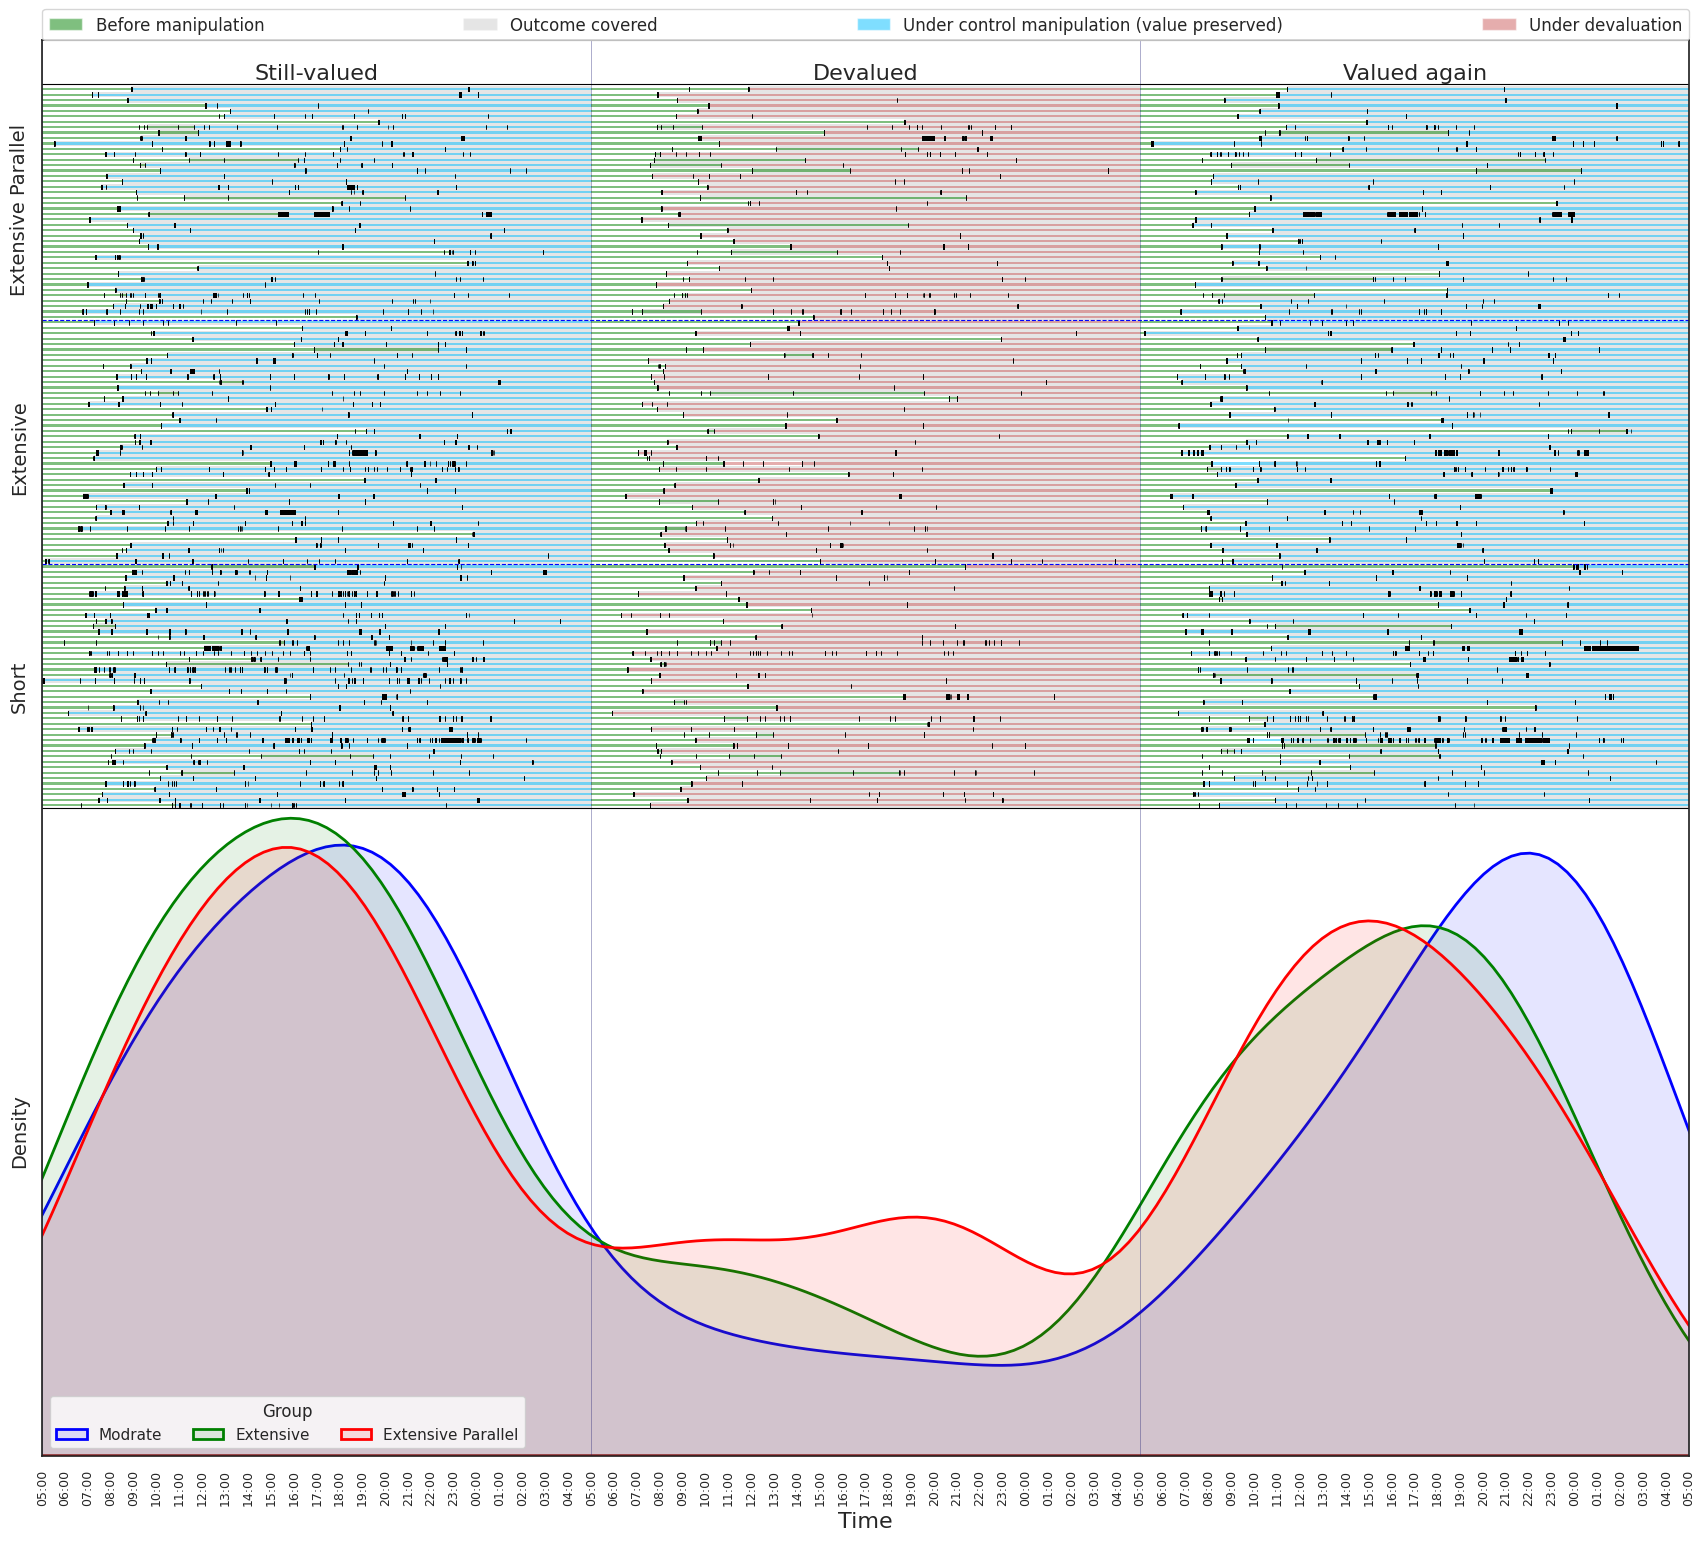

In [ ]:
#@title create the plot [large size] { form-width: "5%" }
sns.set_theme(style="white")

# Parameters:
# ------------------------
# general:
differentiatePressesByColor = False
differentiatePressesByLineHeight = False
showOnlyAlignedManipulationDays = True
figSize = (21.25,18.75)
n_groups = 3
# labels:
xlabelFontSize = 9
# scaling factors
yAxLinesScalingFactor = 0.005
yAxeStartingPointOfEvents = 0.6
line_colors = [[1,0.8,0],[1,0.4,0],[1,0,0]] if differentiatePressesByColor else ['black'] * 3
# colors:
outcome_covered_color = {'color': 'gray', 'alpha': 0.2}
before_manipulation_activated_color = {'color': 'green', 'alpha': 0.5}
under_still_devalued_control_color = {'color': 'deepskyblue', 'alpha': 0.5}
under_devaluation_color = {'color': 'indianred', 'alpha': 0.5}
# event lines:
linelengths = [0.4*yAxLinesScalingFactor, 0.6*yAxLinesScalingFactor, 0.8*yAxLinesScalingFactor] if differentiatePressesByLineHeight else [0.8*yAxLinesScalingFactor] * 3
linewidth = 0.5
# days range to present (if showOnlyAlignedManipulationDays=False)
daysRange = (1,3) if showOnlyAlignedManipulationDays else daysRange
# event lines:
lineoffsets = np.arange(start=yAxeStartingPointOfEvents, stop=np.round(n_subjects*yAxLinesScalingFactor+yAxeStartingPointOfEvents,5), step=yAxLinesScalingFactor)

# PLOT
# --------------------------
fig, axs = plt.subplots()

# Create the density plot:
kdeP = sns.kdeplot(data=timeSeriesDF, x="entry_time", hue='group', hue_order=['long_parallel','long','short'], common_norm=False, bw_method=0.2, palette=['red','green','blue'],alpha=.1, cut=True, fill=True, linewidth=2, ax=axs)
legend1 = plt.legend(loc='lower left', ncol=3, labels=['Modrate','Extensive','Extensive Parallel'], title='Group')

# create a Raster plot of app entries (including the their number of presses)
for idx, sub in enumerate(timeDict.keys()):
  axs.eventplot(timeDict[sub]['startTime'], colors=line_colors[0], lineoffsets=lineoffsets[idx] - (linelengths[2]-linelengths[0])/2,
                      linelengths=linelengths[0], linewidths=linewidth)
  axs.eventplot(timeDict[sub]['startTimeFollowedBy1Press'], colors=line_colors[1], lineoffsets=lineoffsets[idx] - (linelengths[2]-linelengths[1])/2,
                      linelengths=linelengths[1], linewidths=linewidth)
  axs.eventplot(timeDict[sub]['startTimeFollowedBy2Presses'], colors=line_colors[2], lineoffsets=lineoffsets[idx],
                      linelengths=linelengths[2], linewidths=linewidth)

# Set X axis ticks with the adequate time:
axs.xaxis.set_major_locator(mdates.HourLocator(interval = 1))
axs.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# figure setup and drawing 
# -----------------------------
fig.set_size_inches(figSize)
fig.canvas.draw()
xlim = axs.get_xlim()

# indicate seperate days (with a seperating line) and get the relevant xticks values:
endOfDayXTicks = []
middleOfDayXTicks = []
dayInd = daysRange[0]
for xtick in axs.get_xticklabels():
  if xtick.get_text()=='05:00': # create seperating lines between days
    xtick_x_value = xtick.get_unitless_position()[0]
    axs.axvline(x=xtick_x_value, color = 'midnightblue', alpha=0.5, linewidth=0.5)
    endOfDayXTicks.append(xtick_x_value)
  elif xtick.get_text()=='17:00': # add days inside mini titles:
    if showOnlyAlignedManipulationDays:
      dayTitle = ['Still-valued','Devalued', 'Valued again'][dayInd-1]
    else:
      dayTitle = 'day ' + str(dayInd)
    axs.text(xtick.get_unitless_position()[0], yAxeStartingPointOfEvents+ n_subjects*yAxLinesScalingFactor+0.1*yAxLinesScalingFactor,dayTitle,fontsize=16, va='bottom', ha='center')#, bbox=dict(facecolor='red', alpha=0.5))
    dayInd+=1
    middleOfDayXTicks.append(xtick.get_unitless_position()[0])

# draw a line seperating between the groups:
if len(data.sub_df.group.unique()) != 1: # if there is more than one group
  n_short = (commonTimeDF.subId.unique()<200).sum() * yAxLinesScalingFactor + yAxeStartingPointOfEvents
  n_long = ((commonTimeDF.subId.unique()>200) & (commonTimeDF.subId.unique()<300)).sum() * yAxLinesScalingFactor
  axs.axhline(y=n_short + n_long - yAxLinesScalingFactor/2, color = 'blue', alpha=1, linewidth=0.8, linestyle='--')
  axs.axhline(y=n_short - yAxLinesScalingFactor/2, color = 'blue', alpha=1, linewidth=0.8, linestyle='--')

# draw a line that to seperate the distributions and between the manipulatino titles:
axs.axhline(y=yAxeStartingPointOfEvents - yAxLinesScalingFactor/2, color = 'black', alpha=1, linewidth=0.8)
axs.axhline(y=lineoffsets[-1]+yAxLinesScalingFactor, color = 'black', alpha=1, linewidth=0.8)

# add rectangles that indicate outcome hiding (clouds) and manipulation (before/after):
for i, sub in enumerate(subjects):
  # place cloud rectangles:
  for hidingStartTime in timeDict[sub]['cloudsStartTimes']:
    x_position_of_hidingStartTime = mdates.date2num(hidingStartTime)
    if xlim[0] < x_position_of_hidingStartTime < xlim[1]: # check if in range of the plot 
      # Create a Rectangle patch
      rectRightEndingPoint = [x for x in endOfDayXTicks if x >= x_position_of_hidingStartTime][0] if [x for x in endOfDayXTicks if x >= x_position_of_hidingStartTime] else axs.get_xlim()[1] # end of the day or end of the figure if it's the last day
      rectCloudy = patches.Rectangle((x_position_of_hidingStartTime, lineoffsets[i] - yAxLinesScalingFactor/2), rectRightEndingPoint - x_position_of_hidingStartTime, yAxLinesScalingFactor,linewidth=0,edgecolor='none',facecolor=outcome_covered_color['color'], alpha=outcome_covered_color['alpha'])  #patches.Rectangle(xy, width, height, angle=0.0, **kwargs)
      # Add the patch to the Axes
      axs.add_patch(rectCloudy)    
  # place manipulations - still valued:
  x_position_of_still_valued =  mdates.date2num(timeDict[sub]['still_valued_indicationTrialEndTime']['time'])
  if (xlim[0] < x_position_of_still_valued < xlim[1]) & (x_position_of_still_valued.size > 0) : # check if in range of the plot & not empty
    rectRightEndingPoint = [x for x in endOfDayXTicks if x >= x_position_of_still_valued][0] if [x for x in endOfDayXTicks if x >= x_position_of_still_valued] else axs.get_xlim()[1] # end of the day or end of the figure if it's the last day
    rectStillValued = patches.Rectangle((x_position_of_still_valued, lineoffsets[i] - yAxLinesScalingFactor/5), rectRightEndingPoint - x_position_of_still_valued, yAxLinesScalingFactor/2.5,linewidth=0,edgecolor='none',facecolor=under_still_devalued_control_color['color'], alpha=under_still_devalued_control_color['alpha'])  #patches.Rectangle(xy, width, height, angle=0.0, **kwargs)
    axs.add_patch(rectStillValued)
    # add the beginning of the day until the manipulation
    rectLeftStartingPoint = [x for x in endOfDayXTicks if x <= x_position_of_still_valued][-1] if [x for x in endOfDayXTicks if x <= x_position_of_still_valued] else axs.get_xlim()[0] # end of the day or end of the figure if it's the last day
    rectStillValuedBefore = patches.Rectangle((rectLeftStartingPoint, lineoffsets[i]- yAxLinesScalingFactor/5), x_position_of_still_valued - rectLeftStartingPoint, yAxLinesScalingFactor/2.5,linewidth=0,edgecolor='none',facecolor=before_manipulation_activated_color['color'], alpha=before_manipulation_activated_color['alpha'])  #patches.Rectangle(xy, width, height, angle=0.0, **kwargs)
    axs.add_patch(rectStillValuedBefore)
  # place manipulations - devaluation:
  x_position_of_devaluation =  mdates.date2num(timeDict[sub]['devaluation_indicationTrialEndTime']['time'])
  if (xlim[0] < x_position_of_devaluation < xlim[1]) & (x_position_of_devaluation.size > 0) : # check if in range of the plot & not empty
    rectRightEndingPoint = [x for x in endOfDayXTicks if x >= x_position_of_devaluation][0] if [x for x in endOfDayXTicks if x >= x_position_of_devaluation] else axs.get_xlim()[1] # end of the day or end of the figure if it's the last day
    rectDevalued = patches.Rectangle((x_position_of_devaluation, lineoffsets[i]- yAxLinesScalingFactor/5), rectRightEndingPoint - x_position_of_devaluation, yAxLinesScalingFactor/2.5,linewidth=0,edgecolor='none',facecolor=under_devaluation_color['color'], alpha=under_devaluation_color['alpha'])  #patches.Rectangle(xy, width, height, angle=0.0, **kwargs)
    axs.add_patch(rectDevalued)
    # add the beginning of the day until the manipulation
    rectLeftStartingPoint = [x for x in endOfDayXTicks if x <= x_position_of_devaluation][-1] if [x for x in endOfDayXTicks if x <= x_position_of_devaluation] else axs.get_xlim()[0] # end of the day or end of the figure if it's the last day
    rectDevaluedBefore = patches.Rectangle((rectLeftStartingPoint, lineoffsets[i]- yAxLinesScalingFactor/5), x_position_of_devaluation - rectLeftStartingPoint, yAxLinesScalingFactor/2.5,linewidth=0,edgecolor='none',facecolor=before_manipulation_activated_color['color'], alpha=before_manipulation_activated_color['alpha'])  #patches.Rectangle(xy, width, height, angle=0.0, **kwargs)
    axs.add_patch(rectDevaluedBefore)
  # place manipulations - still valued AGAIN:
  x_position_of_still_valued_again =  mdates.date2num(timeDict[sub]['valued_AGAIN_indicationTrialEndTime']['time'])
  if (xlim[0] < x_position_of_still_valued_again < xlim[1]) & (x_position_of_still_valued_again.size > 0) : # check if in range of the plot & not empty
    rectRightEndingPoint = [x for x in endOfDayXTicks if x >= x_position_of_still_valued_again][0] if [x for x in endOfDayXTicks if x >= x_position_of_still_valued_again] else axs.get_xlim()[1] # end of the day or end of the figure if it's the last day
    rectStillValued = patches.Rectangle((x_position_of_still_valued_again, lineoffsets[i]- yAxLinesScalingFactor/5), rectRightEndingPoint - x_position_of_still_valued_again, yAxLinesScalingFactor/2.5,linewidth=0,edgecolor='none',facecolor=under_still_devalued_control_color['color'], alpha=under_still_devalued_control_color['alpha'])  #patches.Rectangle(xy, width, height, angle=0.0, **kwargs)
    axs.add_patch(rectStillValued)
    # add the beginning of the day until the manipulation
    rectLeftStartingPoint = [x for x in endOfDayXTicks if x <= x_position_of_still_valued_again][-1] if [x for x in endOfDayXTicks if x <= x_position_of_still_valued_again] else axs.get_xlim()[0] # end of the day or end of the figure if it's the last day
    rectStillValuedBefore = patches.Rectangle((rectLeftStartingPoint, lineoffsets[i]- yAxLinesScalingFactor/5), x_position_of_still_valued_again - rectLeftStartingPoint, yAxLinesScalingFactor/2.5,linewidth=0,edgecolor='none',facecolor=before_manipulation_activated_color['color'], alpha=before_manipulation_activated_color['alpha'])  #patches.Rectangle(xy, width, height, angle=0.0, **kwargs)
    axs.add_patch(rectStillValuedBefore)


# handle legends:
legend_elements = [Patch(facecolor=before_manipulation_activated_color['color'], alpha=before_manipulation_activated_color['alpha'], label='Before manipulation'),
                  Patch(facecolor=outcome_covered_color['color'], alpha=outcome_covered_color['alpha'], label='Outcome covered'),
                  Patch(facecolor=under_still_devalued_control_color['color'], alpha=under_still_devalued_control_color['alpha'], label='Under control manipulation (value preserved)'),
                  Patch(facecolor=under_devaluation_color['color'], alpha=under_devaluation_color['alpha'], label='Under devaluation')]
axs.legend(handles=legend_elements, bbox_to_anchor=(0, 1.0, 1., 0.01), ncol=4, mode="expand", borderaxespad=0., fontsize=12)
plt.gca().add_artist(legend1) # add the density plot legend

# handle x axis:
axs.set_xlim(left = endOfDayXTicks[0], right = endOfDayXTicks[-1])
plt.xticks(fontsize = xlabelFontSize)
plt.setp(plt.gca().xaxis.get_majorticklabels(),'rotation', 90)

axs.get_xaxis().set_label_text('Time', fontsize=16)

# handle y axis:
plt.ylim((0,lineoffsets[-1]+yAxLinesScalingFactor+8*yAxLinesScalingFactor))
yTicksForGroupNames = np.linspace(yAxeStartingPointOfEvents, axs.get_ylim()[1] - (yAxLinesScalingFactor+8*yAxLinesScalingFactor) ,2*n_groups+1)[np.arange(1,2*n_groups+1,2)]
plt.yticks(np.append(0.3, yTicksForGroupNames),rotation=90,ha='right', va="center")
axs.set_yticklabels(['Density', 'Short','Extensive','Extensive Parallel'], fontsize=14)
axs.get_yaxis().get_label().set_visible(False)


plt.show()


# ------------------------------ * -------------------------------


# ARCHIVE

In [ ]:
# ---------------------------------------------
# NOTE NOTE NOTE: Features to add/consider
# ---------------------------------------------

sub_df_extended.head()
# change settings to show all columns when printing:
pd.set_option('display.max_columns', None)

# now show data with all columns but touchData:
sub_df_extended.drop(columns=['touchData']).head()
# Features of interest:
# DONE:
# startTimes, intervals (within/between), day timings, n entries, session data, ratio 1st/2nd, ,,, 
# 
# ADD NOW:
# automaticity measures,  etc. maybe full, non-full entries...
# reward? cost? time of reading messages? screenOrientationData	? userExitOrUnloadTime from endTime (probabely after excluding more then 10 s and then calculate average etc..)? realGameBeginsAlertTime minus realGameBeginsConfirmationTime? Maybe model burstiness?
# Add medians where is relevant; Can take correlaiton (e.g. between 1st and 2nd press as a measure(...)

# maybe coin task hits/misses (and other data) during demo...
# and all instructions data...

# MAYBE LATER:
# ---------------------------------------------
# model bursting ?
# including other ratios?
# maybe also change in ratio


# Maybe ADD NEXT:
# add touch data (e.g. angle between presses, distance maybe?, etc., maybe change in angle)
sub_df_extended.touchData[0]
touchData_dict = ast.literal_eval(sub_df_extended.touchData[0])
touchData_dict['pressEvents']

MORE FEATURE OPTION:

In [ ]:
sub_df_extended_copy = sub_df_extended.copy()
entries_per_session_data = sub_df_extended.groupby(['subId', 'day']).apply(lambda x: x.groupby(x['sessionsBeginning'].cumsum()).size().mean()).reset_index(name='AVG_entries_per_session')
entries_per_session_data.rename(columns={'subId': 'subID'}, inplace=True)

# keep only day 1:
sub_df_extended_copy = sub_df_extended_copy[sub_df_extended_copy.day == 1]
entries_per_session_data = entries_per_session_data[entries_per_session_data.day == 1]

# Convert startTime to seconds since 12 AM
sub_df_extended_copy['startTime'] = pd.to_datetime(sub_df_extended_copy['startTime'], errors='coerce')
sub_df_extended_copy['startTime_seconds'] = (
    sub_df_extended_copy['startTime'].dt.hour * 3600 +
    sub_df_extended_copy['startTime'].dt.minute * 60 +
    sub_df_extended_copy['startTime'].dt.second
)


# create a new df with one subjects per row for summary features:
feature_data = pd.DataFrame()
feature_data['subID'] = np.sort(sub_df_extended_copy['subId'].unique())
feature_data = feature_data.merge(data_for_R[['subID', 'group']], on='subID', how='left')

# count the number of rows for each subID:
feature_data['entries'] = feature_data['subID'].map(sub_df_extended_copy.groupby('subId').size())
# now I want the average startTime in day time:
feature_data['avg_startTime'] = feature_data['subID'].map(sub_df_extended_copy.groupby('subId')['startTime'].mean())
feature_data['avg_startTime'] = (feature_data['avg_startTime'].dt.hour * 3600 +feature_data['avg_startTime'].dt.minute * 60 +feature_data['avg_startTime'].dt.second) # Convert startTime to seconds since 12 AM
feature_data['median_startTime'] = feature_data['subID'].map(sub_df_extended_copy.groupby('subId')['startTime'].median())
feature_data['median_startTime'] = (feature_data['median_startTime'].dt.hour * 3600 +feature_data['median_startTime'].dt.minute * 60 +feature_data['median_startTime'].dt.second) # Convert startTime to seconds since 12 AM
feature_data['startTime_std_seconds'] = feature_data['subID'].map(sub_df_extended_copy.groupby('subId')['startTime_seconds'].std())

feature_data['pressed_all_seq'] = feature_data['subID'].map(sub_df_extended_copy.groupby('subId')['pressed_all_seq'].mean())
feature_data['pressed_only_1st_seq'] = feature_data['subID'].map(sub_df_extended_copy.groupby('subId')['pressed_only_1st_seq'].mean())
feature_data['pressed_only_entry'] = feature_data['subID'].map(sub_df_extended_copy.groupby('subId')['pressed_only_entry'].mean())

feature_data['secsToPress1_mean'] = feature_data['subID'].map(sub_df_extended_copy.groupby('subId')['secsToPress1'].mean())
feature_data['secsToPress1_std'] = feature_data['subID'].map(sub_df_extended_copy.groupby('subId')['secsToPress1'].std())   
feature_data['secsToPress2_mean'] = feature_data['subID'].map(sub_df_extended_copy.groupby('subId')['secsToPress2'].mean())
feature_data['secsToPress2_std'] = feature_data['subID'].map(sub_df_extended_copy.groupby('subId')['secsToPress2'].std())
feature_data['secsToExitAfterOutcomeTime_mean'] = feature_data['subID'].map(sub_df_extended_copy[sub_df_extended_copy.secsToExitAfterOutcomeTime<10].groupby('subId')['secsToExitAfterOutcomeTime'].mean())
feature_data['secsToExitAfterOutcomeTime_std'] = feature_data['subID'].map(sub_df_extended_copy[sub_df_extended_copy.secsToExitAfterOutcomeTime<10].groupby('subId')['secsToExitAfterOutcomeTime'].std())
# relationship between presses:
feature_data['secsToPress1_secsToPress2_ratio'] = feature_data['secsToPress1_mean'] / feature_data['secsToPress2_mean']

# sequenceCompletionTime:
feature_data['sequenceCompletionTime_mean'] = feature_data['subID'].map(sub_df_extended_copy.groupby('subId')['sequenceCompletionTime'].mean())
feature_data['sequenceCompletionTime_std'] = feature_data['subID'].map(sub_df_extended_copy.groupby('subId')['sequenceCompletionTime'].std())

# deltaSecStartTime:
feature_data['deltaSecStartTime_mean'] = feature_data['subID'].map(sub_df_extended_copy.groupby('subId')['deltaSecStartTime'].mean())
feature_data['deltaSecStartTime_std'] = feature_data['subID'].map(sub_df_extended_copy.groupby('subId')['deltaSecStartTime'].std())

# # how many sessions:
feature_data['sessions_mean'] = feature_data['subID'].map(sub_df_extended_copy.groupby('subId')['sessionsBeginning'].mean())
feature_data['sessions_std'] = feature_data['subID'].map(sub_df_extended_copy.groupby('subId')['sessionsBeginning'].std())

feature_data['sessions_count'] = feature_data['subID'].map(sub_df_extended_copy.groupby('subId')['sessionsBeginning'].apply(lambda x: x[x==True].count()))
feature_data = feature_data.merge(entries_per_session_data, on='subID', how='left')

# NOTE: I Took the one below off for now because one subject has gets a NAN values!
# feature_data['gameBeginsConfirmationRT'] = feature_data['subID'].map(sub_df_extended[sub_df_extended['gameBeginsConfirmationRT'].notna()].groupby('subId')['gameBeginsConfirmationRT'].mean())

feature_data['IPI_abs_diff_sum'] = feature_data['subID'].map(app_IPI_consistency_data.groupby('subId')['IPI_abs_diff_sum'].mean())
feature_data['IPI_abs_diff_sum_std'] = feature_data['subID'].map(app_IPI_consistency_data.groupby('subId')['IPI_abs_diff_sum'].std())
feature_data['only2nd_IPI_abs_diff_sum'] = feature_data['subID'].map(app_IPI_consistency_data.groupby('subId')['only2nd_IPI_abs_diff_sum'].mean())
feature_data['only2nd_IPI_abs_diff_sum_std'] = feature_data['subID'].map(app_IPI_consistency_data.groupby('subId')['only2nd_IPI_abs_diff_sum'].std())
# feature_data['IPI_abs_diff_sum_session_seperated'] = feature_data['subID'].map(app_IPI_consistency_data.groupby('subId')['IPI_abs_diff_sum_session_seperated'].mean()) # Has NAs
# feature_data['IPI_abs_diff_sum_session_seperated_std'] = feature_data['subID'].map(app_IPI_consistency_data.groupby('subId')['IPI_abs_diff_sum_session_seperated'].std()) # Has NAs
# feature_data['only2nd_IPI_abs_diff_sum_session_seperated'] = feature_data['subID'].map(app_IPI_consistency_data.groupby('subId')['only2nd_IPI_abs_diff_sum_session_seperated'].mean()) # Has NAs
# feature_data['only2nd_IPI_abs_diff_sum_session_seperated_std'] = feature_data['subID'].map(app_IPI_consistency_data.groupby('subId')['only2nd_IPI_abs_diff_sum_session_seperated'].std()) # Has NAs

# change group to be -1 if group is 'short_training' and 1 if group is 'long_training':
feature_data['group'] = feature_data['group'].apply(lambda x: -1 if x == 'short_training' else 1)


feature_data.head(20)


